# Imports and File Path Setup

In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da
from scipy.stats import linregress
import math
from tqdm.notebook import tqdm
import dask.array as da 
from tifffile import imwrite


In [2]:
# Change this variable to where your python packages are. Don't remove the r
package_dir = r'C:\Users\Kenny\LLSM-CME-ANALYSIS\Final\src'

# Change this variable to the directory where all your data is. Don't remove the r
base_dir = r'\\10.158.28.194\ActiveNAS\Kenny'
#base_dir = r'C:\Users\Kenny\akamatsu'
# Change this variable to the current data you are analyzing in your base_dir.
input_file_directory = 'lumenoid_2_analysis/'

In [3]:
pythonPackagePath = os.path.abspath(package_dir)
sys.path.append(pythonPackagePath)
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort, intensity_time_plot_onetrack
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax

# from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians
filtered_tracks_treatment = pd.read_pickle(os.path.join(base_dir, input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))

## AP2 Histogram Lifetimes

In [4]:
###### Set the following variables #######


# Background intensity for each channel

# background_channel_1 = 240
# background_channel_2 = 150
# background_channel_3 = 170

# # framerate (in milliseconds)

# framerate_msec = 2200

# protein names (optional)

channel1_name = 'Arp2/3-Halo'
channel2_name = 'Dynamin2-tagGFP2'
channel3_name = 'AP2-tagRFPt'

In [5]:
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0

# use this list to see all possible values to plot
# track_df.columns

In [6]:
# filtered_tracks_control
# label1 = 'Control'
# label2 = 'Tracks Filtered'

label1 = 'Apical'
label2 = 'Lateral'
label3 = 'Basal'

In [7]:
# range of track lengths to plot in each cohort, in frames
custom_length_ranges = [[5, 10], [11,15], [16, 20], [21, 25], [26, 30], [31, 40], [41,90]]

In [8]:
def trackFilter(region_to_plot: str, plot_all_channels: bool, tracks: pd.DataFrame, channels_to_plot: list = [True, True]):
    """
    Filter out tracks based on the specifcations of the

    Parameters:
    1. region_to_plot (str): Region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    2. plot_all_channels (bool): If True, all channels are considered. If False, only postive tracks are considered.
    3. tracks (pd.Dataframe): DataFrame containing track information, including 'membrane_region', 'channel1_positive', and 'channel2_positive'.
    4. channels_to_plot (list): List of booleans indicating which channels to plot. Default is [True, True] for both channels.

    Outputs:
    1. pd.DataFrame: Filtered DataFrame containing tracks with the specified region and channel conditions.
    """
        

    if region_to_plot == 'All':
        #filtered_tracks_all_control = filtered_tracks_control.copy()
        filtered_tracks_all_treatment = tracks.copy()

    else:
        # filtered_tracks_all_control = filtered_tracks_control.copy()
        filtered_tracks_all_treatment = tracks.copy()
        # filtered_tracks_all_control = filtered_tracks_all_control[filtered_tracks_all_control['membrane_region'] == region_to_plot]
        filtered_tracks_all_treatment = filtered_tracks_all_treatment[filtered_tracks_all_treatment['membrane_region'] == region_to_plot]

    #channels_to_plot = [True, True]
    if plot_all_channels:
    # tracks_channel_subset_control = filtered_tracks_all_control.copy()
        tracks_channel_subset_treatment = filtered_tracks_all_treatment.copy()
        return tracks_channel_subset_treatment
    else:
        tracks_channel_subset_treatment = filtered_tracks_all_treatment[(filtered_tracks_all_treatment['channel1_positive'] == channels_to_plot[0]) & (filtered_tracks_all_treatment['channel2_positive'] == channels_to_plot[1])]
        return tracks_channel_subset_treatment

In [9]:
# Plot histogram of all track lengths (lifetimes)
def createHistogramAP2Lifetimes(tracks: pd.DataFrame,framerate_msec: int, no_seperation: bool, bins = np.linspace(0, 300, 51)):
    # Create a histogram of AP2 lifetimes based on the provided tracks DataFrame.
    """
    Parameters:
    1. tracks (pd.DataFrame): DataFrame containing track information, including 'membrane_region', 'channel1_positive', and 'channel2_positive'.
    2. framerate_msec (int): Framerate in milliseconds to convert track lengths to seconds.
    3. plot_all_channels (bool): If True, all channels are considered. If False, tracks with all positive channels are considered.
    4. bins (np.ndarray): Array of bin edges for the histogram. Default is np.linspace(0, 300, 51).

    Outputs:
    1. A histogram plot showing the distribution of AP2 lifetimes in seconds.

    """
    if no_seperation:
        # For using the tracks_channel_subset 
        #n, bins, patches = plt.hist(all_lifetimes, bins=50, facecolor='#2ab0ff', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)

        # For using the raw membrane region filtered tracks
        n, bins, patches = plt.hist(tracks['track_length']*framerate_msec/1000, bins=bins, facecolor='#2ab0ff', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)

        n = n.astype('int')

        # Good old loop. Choose colormap of your taste
        for i in range(len(patches)):
            patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))

        #plt.hist(all_lifetimes, bins=50, edgecolor=black)
        plt.xlabel('Time (s)')  # X-axis label
        plt.ylabel('Frequency')  # Y-axis label
        plt.title('Track lengths (lifetimes)')  # Title of the histogram
        plt.show()
    else:
        tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
        tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
        tracks_basal = tracks[tracks['membrane_region'] == 'Basal']
        # 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
        #all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
        #all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
        all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
        all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
        all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000
        plt.hist(all_lifetimes_apical, bins=bins, color = 'red', edgecolor='black', alpha=0.35, density=True, label=label1)
        plt.hist(all_lifetimes_lateral, bins=bins, color = 'blue', edgecolor='black', alpha=0.35, density=True, label=label2)
        plt.hist(all_lifetimes_basal, bins=bins, color = 'green', edgecolor='black', alpha=0.35, density=True, label=label3)
        plt.xlabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
        plt.ylabel('Density', fontsize = 12, weight = 'bold')  # Y-axis label
        plt.title(f'AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram
        plt.legend(prop = {'weight':'bold'})
        plt.show()

## Box and Whisker plots of AP2 lifetimes in Membrane Regions

In [10]:
def createBoxWhiskerPlot(tracks: pd.DataFrame, seperate_regions: bool, framerate_msec: int):
    """
    Create a box-and-whisker plot(s) of AP2 lifetimes based on the provided tracks DataFrame.

    Parameters:
    1. tracks (pd.DataFrame): DataFrame containing track information, including 'membrane_region' and 'track_length'.
    2. seperate_regions (bool): If True, plots lifetimes for each membrane region separately. If False, pools all data into one boxplot.
    3. framerate_msec (int): Framerate in milliseconds to convert track lengths to seconds.
    
    Outputs:
    1. A box-and-whisker plot of AP2 lifetimes, either for each membrane region separately or pooled together.
    
    
    """
    if seperate_regions:
        all_lifetimes = tracks['track_length']*framerate_msec/1000
        plt.boxplot(all_lifetimes, labels=['Lumenoid 2'])
        plt.ylabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
        plt.title('Boxplot of AP2 lifetimes in Lumenoid', fontsize = 14, weight = 'bold')
        plt.show()
    else:
        tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
        tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
        tracks_basal = tracks[tracks['membrane_region'] == 'Basal']

        # 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
        #all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
        #all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
        all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
        all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
        all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000
        data = [all_lifetimes_apical, all_lifetimes_lateral, all_lifetimes_basal]
        fig, ax = plt.subplots()
        box = ax.boxplot(data, labels=[label1, label2, label3])
        title = 'AP2 lifetimes in Membrane Regions'
        ax.set_ylabel('AP2 lifetime (s)', fontsize=12, weight='bold')
        ax.set_title(title, fontsize=14, weight='bold')
        for i, line in enumerate(box['medians']):
            x, y = line.get_xdata()[1], line.get_ydata()[0]
            print("x:", line.get_xdata())
            print("y:",line.get_ydata())
            ax.text(x + 0.05, y, f'{y:.2f}s', va='center', ha='left', fontsize=10, color='black')
            plt.title(f'AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')
        plt.show()

In [11]:
def compareLumenoidsBoxPlot(lumenoid1, lumenoid2, region_to_plot, lumenoid1_name, lumenoid2_name, lumenoid1_frame_ms, lumenoid2_frame_ms):
    """
    Used to compare the lifetimes of two lumenoids in a box-and-whisker plot

    Parameters:
    1. lumenoid1 (pd.Dataframe): Name of the first lumenoid to filter tracks.
    2. lumenoid2 (pd.Dataframe): Name of the second lumenoid to filter tracks.
    3. region_to_plot (str): The region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    4. lumenoid1_name (str): Name of the first lumenoid for labeling.
    5. lumenoid2_name (str): Name of the second lumenoid for labeling.
    6. lumenoid1_frame_ms (int): Frame rate in milliseconds for the first lumenoid.
    7. lumenoid2_frame_ms (int): Frame rate in milliseconds for the second lumenoid.

    Outputs:
    1. A box-and-whisker plot comparing the lifetimes of the two lumenoids in the specified region.

    """

    if region_to_plot == 'All':
        lumenoid1_lifetimes = lumenoid1['track_length']*lumenoid1_frame_ms/1000
        lumenoid2_lifetimes = lumenoid2['track_length']*lumenoid2_frame_ms/1000
        
        # lumenoid1_all_lifetimes = lumenoid1_all_lifetimes[lumenoid1_all_lifetimes <= 300]
        # lumenoid2_all_lifetimes = lumenoid2_all_lifetimes[lumenoid2_all_lifetimes <= 300]
        title = 'AP2 lifetimes in All Regions'
    else:
        lumenoid1_region_tracks = lumenoid1[lumenoid1['membrane_region'] == region_to_plot]
        lumenoid2_region_tracks = lumenoid2[lumenoid2['membrane_region'] == region_to_plot]

        lumenoid1_lifetimes = lumenoid1_region_tracks['track_length']*lumenoid1_frame_ms/1000
        lumenoid2_lifetimes = lumenoid2_region_tracks['track_length']*lumenoid2_frame_ms/1000

        # lumenoid1_region_lifetimes = lumenoid1_region_lifetimes[lumenoid1_region_lifetimes <= 300]
        # lumenoid2_region_lifetimes = lumenoid2_region_lifetimes[lumenoid2_region_lifetimes <= 300]
        title = f'AP2 lifetimes in {region_to_plot}'
    data = [lumenoid1_lifetimes, lumenoid2_lifetimes]
    fig, ax = plt.subplots()
    box = ax.boxplot(data, labels=[lumenoid1_name, lumenoid2_name])

    ax.set_ylabel('AP2 lifetime (s)', fontsize=12, weight='bold')
    ax.set_title(title, fontsize=14, weight='bold')
    for i, line in enumerate(box['medians']):
        x, y = line.get_xdata()[1], line.get_ydata()[0]
        print("x:", line.get_xdata())
        print("y:",line.get_ydata())
        ax.text(x + 0.05, y, f'{y:.2f}s', va='center', ha='left', fontsize=10, color='black')

    name1 = f"{lumenoid1_name} (n={len(lumenoid1_region_tracks) if region_to_plot != 'All' else len(lumenoid1)})"
    name2 = f"{lumenoid2_name} (n={len(lumenoid2_region_tracks) if region_to_plot != 'All' else len(lumenoid2)})"
    plt.legend([name1, name2])
    plt.show()

## CDF Plot

In [12]:
# Cumulative plot of track lifetimes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_cumulative_lifetime(tracks, framerate, label_list, title = None):
    """
    Plots a cumulative frequency plot of AP2 lifetimes in different membrane regions.
    Parameters:
    1. tracks (pd.DataFrame): DataFrame containing track information, must have 'membrane_region' and 'track_length' columns.
    2. framerate (int): Framerate in milliseconds to convert track lengths to seconds.
    3. label_list (list): List of labels for the different membrane regions to be plotted.
    4. title (str): Title of the plot.
    
    Outputs:
    1. A plot showing the cumulative frequency of AP2 lifetimes in different membrane regions.
    """
    plt.figure(figsize=(8, 7))
    alpha_values = {'orange': 0.5, 'blue': 0.35}
    tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
    tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
    tracks_basal = tracks[tracks['membrane_region'] == 'Basal']
    all_lifetimes_apical = tracks_apical['track_length']*framerate/1000
    all_lifetimes_lateral = tracks_lateral['track_length']*framerate/1000
    all_lifetimes_basal = tracks_basal['track_length']*framerate/1000

    all_lifetimes_apical_df = pd.DataFrame(all_lifetimes_apical)
    all_lifetimes_lateral_df = pd.DataFrame(all_lifetimes_lateral)
    all_lifetimes_basal_df = pd.DataFrame(all_lifetimes_basal)
    # Define colors for conditions
    conditions = {label_list[0]: (all_lifetimes_apical_df, 'orange'), label_list[1]: (all_lifetimes_lateral_df, 'blue'), label_list[2]: (all_lifetimes_basal_df,'green')}
    
    for label, (df, color) in conditions.items():
        subset = np.sort(df['track_length'])
        cum_freq = np.arange(1, len(subset) + 1) / len(subset)
        alpha = alpha_values.get(color, 1.0)
        plt.plot(subset, cum_freq, label=label, color=color, linewidth=2)

    # Formatting
    plt.xlabel('AP2 lifetime (s)', fontsize=12, weight='bold')
    plt.ylabel('Cumulative frequency', fontsize=12, weight='bold')
    plt.xlim(0, 305)
    plt.ylim(0, 1.05)

    # Add horizontal dashed reference line at 0.5
    plt.axhline(0.5, linestyle="--", color="black")
    
    # Add shaded region (0-50s)
    # plt.axvspan(0, 50, color='brown', alpha=0.2)

    # Title and legend
    plt.title(title, fontsize=14, weight='bold')

    legend_handles = []
    for label, (df, color) in conditions.items():
        alpha = alpha_values.get(color, 1.0)
        patch = mpatches.Patch(color=color,alpha = alpha, label=label)
        legend_handles.append(patch)
    plt.legend(handles = legend_handles, fontsize=12, loc='upper left', bbox_to_anchor=(0.025, 1), prop = {'weight':'bold'})
    plt.title('Cumulative AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram
    # Show plot
    # plt.show()
    return plt

## Statistics Functions

In [13]:

def calculate_region_stats(track_data, frame_ms, channels_to_compare="channel1", region ='All'):
    """

    Parameters:
    1. track_data (pd.DataFrame): DataFrame containing track information, including 'membrane_region', 'channel1_positive', and 'channel2_positive'
    2. frame_ms (int): Framerate in miliseconds
    3. channels_to_compare (str): String indicating which channels to compare. Default is "channel1" and other options are "channel2" or "both".
    4. region (str): Region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    """
    channels_to_plot = [True,True]
    positive_text = "Arp2/3+ Dynamin+"
    if region != "All":
         subset = track_data[track_data['membrane_region'] == region].copy()
    else:
        subset = track_data.copy()


    if channels_to_compare == "channel1":
        negative_text = "Arp2/3- Dynamin+"
        total_opposite_tracks = subset[(subset['channel1_positive'] != channels_to_plot[0]) & (subset['channel2_positive'] == channels_to_plot[1])]
    elif channels_to_compare == "channel2":
        negative_text = "Arp2/3+ Dynamin-" 
        total_opposite_tracks = subset[(subset['channel1_positive'] == channels_to_plot[0]) & (subset['channel2_positive'] != channels_to_plot[1])]
    elif channels_to_compare == "both":
        negative_text = "Arp2/3- Dynamin-"
        total_opposite_tracks = subset[(subset['channel1_positive'] != channels_to_plot[0]) & (subset['channel2_positive'] != channels_to_plot[1])]
    else:
        raise ValueError("Invalid channels_to_compare value. Use 'channel1', 'channel2', or 'both'")
    

    

    total_tracks = len(subset)
    total_positive_tracks = subset[(subset['channel1_positive'] == channels_to_plot[0]) & (subset['channel2_positive'] == channels_to_plot[1])]
    positive_lifetimes = total_positive_tracks['track_length']*(frame_ms/1000)
    negative_lifetimes = total_opposite_tracks['track_length']*(frame_ms/1000)
    total_positive_tracks = len(total_positive_tracks)
    total_negative_tracks = len(total_opposite_tracks)
    print(f"Total tracks in {region}: {total_tracks}")
    print(f"Total {positive_text} in {region}: {total_positive_tracks}")
    print(f"Total {negative_text} in {region}: {total_negative_tracks}")
    print(f"Percentage of {positive_text} tracks in {region}: {total_positive_tracks / total_tracks * 100:.2f}%")
    print(f"Percentage of {negative_text} in {region}: {total_negative_tracks / total_tracks * 100:.2f}%")
    #print(f'Median lifetime of {positive_text} in {region}: {np.median(positive_lifetimes):.2f} s')
    #print(f'Median lifetime of {negative_text} in {region}: {np.median(negative_lifetimes):.2f} s')
    print(f'Mean lifetime of {positive_text} in {region}: {np.mean(positive_lifetimes):.2f} s')
    print(f'Mean lifetime of {negative_text} in {region}: {np.mean(negative_lifetimes):.2f} s')
##calculate_region_stats(filtered_tracks_treatment, lumenoid2_frame_ms, 'channel1', 'Basal')

## Intensity Graphs

In [14]:
def intensity_region_plot(track,toNormalize = True,toFrequencyDensity = True,channel_to_plot = "channel1"):
    """
    """
    if channel_to_plot == "channel1":
        columns = ['C1_adjusted_voxel_sum']
        title_channel = 'Arp2/3'
    elif channel_to_plot == "channel2":
        columns = ['C2_adjusted_voxel_sum']
        title_channel = 'Dynamin2'
    #marker = ['ArpC3']
    tracks_apical = track[track['membrane_region'] == 'Apical']
    tracks_lateral = track[track['membrane_region'] == 'Lateral']
    tracks_basal = track[track['membrane_region'] == 'Basal']

    apical_AP2 = tracks_apical['C3_adjusted_voxel_sum'].reset_index(drop=True)
    lateral_AP2 = tracks_lateral['C3_adjusted_voxel_sum'].reset_index(drop=True)
    basal_AP2 = tracks_basal['C3_adjusted_voxel_sum'].reset_index(drop=True)

    max_apical_AP2 = []
    for j in range(len(apical_AP2)):
        max_apical_AP2.append(max(apical_AP2[j]))  
    max_lateral_AP2 = []
    for j in range(len(lateral_AP2)):
        max_lateral_AP2.append(max(lateral_AP2[j])) 
    max_basal_AP2 = []
    for j in range(len(basal_AP2)):
        max_basal_AP2.append(max(basal_AP2[j])) 

    for i in range(len(columns)):
        # Create a figure with 2 subplots side by side
        # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig1, ax1 = plt.subplots(figsize=(6, 5.25))
        fig2, ax2 = plt.subplots(figsize=(6, 5.25))

        apical =  tracks_apical[columns[i]].reset_index(drop=True)
        lateral =  tracks_lateral[columns[i]].reset_index(drop=True)
        basal =  tracks_basal[columns[i]].reset_index(drop=True)
        max_apical = []
        for j in range(len(apical)):
            max_apical.append(max(apical[j]))  
        max_lateral = []
        for j in range(len(lateral)):
            max_lateral.append(max(lateral[j])) 
        max_basal = []
        for j in range(len(basal)):
            max_basal.append(max(basal[j]))  

        # Normalize to max AP2 intensity, optional
        if toNormalize:
            max_apical = (np.array(max_apical) / np.array(max_apical_AP2)).tolist()
            max_lateral = (np.array(max_lateral) / np.array(max_lateral_AP2)).tolist()
            max_basal = (np.array(max_basal) / np.array(max_basal_AP2)).tolist()

        bins = np.linspace(min(min(max_apical), min(max_lateral),min(max_basal)), max(max(max_apical), max(max_lateral),max(max_basal)), 50)
        # Plot histogram on the first subplot
        if toFrequencyDensity:
            ax1.hist(max_apical, bins=bins, color='orange', edgecolor='black', alpha=0.7,density=True, label=label1)
            ax1.hist(max_lateral, bins=bins, color='blue', edgecolor='black', alpha=0.5,density=True, label=label2)
            ax1.hist(max_basal, bins=bins, color='green', edgecolor='black', alpha=0.35,density=True, label=label3)
            ax1.set_ylabel('Frequency Density', fontsize=12, weight='bold')
        else:
            ax1.hist(max_apical, bins=bins, color='orange', edgecolor='black', alpha=0.7, label=label1)
            ax1.hist(max_lateral, bins=bins, color='blue', edgecolor='black', alpha=0.5, label=label2)
            ax1.hist(max_basal, bins=bins, color='green', edgecolor='black', alpha=0.35, label=label3)
            ax1.set_ylabel('Frequency', fontsize=12, weight='bold')
        ax1.set_xlabel('Normalized Intensity (A.U.)', fontsize=12, weight='bold')
        ax1.legend(prop={'weight': 'bold'}, loc ='upper right')
        boxplot_data = [max_apical, max_lateral, max_basal]
        bp = ax2.boxplot(boxplot_data, patch_artist=True)
        median_line = bp['medians'][0]
        median_y = median_line.get_ydata()[0]  # Y-value of the median
        ax2.hlines(y=median_y, xmin=1, xmax=2, color='grey', linewidth=0.5, linestyle='--')

        # Loop through each median line and place value beside it
        for j, median in enumerate(bp['medians']):
            xdata = median.get_xdata()
            ydata = median.get_ydata()
            x = xdata.mean()   # horizontal center of median line
            y = ydata[0]       # vertical location of median

            if j == 0:
                # Left box: place text to the left
                ax2.text(x - 0.25, y, f'{y:.2f}', ha='right', va='center', fontsize=10, weight='bold', color='black')
            elif j == 1:
                # middle box: place text to the right
                ax2.text(x + 0.25, y, f'{y:.2f}', ha='left', va='center', fontsize=10, weight='bold', color='black')
            else:
                # Right box: place text to the right
                ax2.text(x + 0.25, y, f'{y:.2f}', ha='left', va='center', fontsize=10, weight='bold', color='black')

        bp['boxes'][0].set(facecolor='orange', alpha=0.7)
        bp['boxes'][1].set(facecolor='blue', alpha=0.5)
        bp['boxes'][2].set(facecolor='green', alpha=0.35)
        for k in range(3):
            bp['medians'][k].set(color='black', linewidth=1.5)
        ax2.set_xticklabels([label1, label2, label3], fontsize=12, weight='bold')
        ax2.set_ylabel(f'Normalized maximum {title_channel} intensity (A.U.)', fontsize=12, weight='bold')
        # Adjust layout
        plt.tight_layout()
        plt.show()

In [15]:
def cohort_intensity(track, track_id_arrays, framerate_msec, backgroundIntensity,value_to_plot):
    for n, cohort in enumerate(custom_length_ranges):
        primary_buffer, secondary_buffer, tertiary_buffer = createBufferForLifetimeCohort(dataframe = track,
        listOfTrackIdsAssignedToCohort = track_id_arrays[n], backgroundIntensity = backgroundIntensity,
        intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id')

        cumulative_plots(buffers = [primary_buffer, secondary_buffer, tertiary_buffer],
        background_intensity= [background_channel_3, background_channel_2, background_channel_1], time_shift = 50+cohort[1], framerate_msec = framerate_msec, colors = ['magenta', 'lime', 'blue'], 
                    legend_vals = [channel3_name, channel2_name, channel1_name])
        plt.xlim(0, 75+cohort[1]*framerate_msec/1000)
        # plt.xlim(35, 85)

        plt.title(f'Amplitude over time in cohort {custom_length_ranges[n]}', fontsize=16)
        plt.xlabel('Time (s)', fontsize=14)
        plt.ylabel('Amplitude', fontsize=14)
        # increase tick sizes
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.show()

## CCS Growth Distribution

In [16]:
def create_growth_dist_histogram(slopes, title: str = 'Growth Distribution', bins = np.linspace(-0.09, 0.09, 6)):
    """
    Creates a histogram for the growth distribution like the Ferguson paper

    slopes(list): A list containing the slopes that you extracted from growth_distribution or extract_slope
    title(str): String to name your title. Default is Growth Distribution
    bins: The bins on the histogram. Default is np.linspace(-0.09, 0.09, 6)

    """
    weights = np.ones_like(slopes) / len(slopes) * 100

    # Plot percent frequency histogram
    plt.hist(slopes, bins=bins, weights=weights, color='red', edgecolor='black', alpha=0.35, label='slope')
    plt.xlabel('Slope', fontsize=12, weight='bold')
    plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
    plt.title(f'{title}', fontsize=14, weight='bold')
    plt.legend(prop={'weight': 'bold'})
    plt.show()

In [17]:
def extract_trackid_data(track, track_id):
    """
    Extracts a specific trackid data
    
    track(pd.Dataframe): The dataframe you are extracting data from
    track_id(int): The track_id to extract
    """
    track_data = track[track['track_id'] == track_id].copy(deep = True)
    return track_data

In [18]:

def group_intensities_trackid(track,track_id):
    """
    Extracts the AP2 intensitied on a specific track

    track(pd.Dataframe): The dataframe you are extracting data from
    track_id(int): The track_id to extract
    """
    track_data = extract_trackid_data(track,track_id)
    
    return track_data['c3_voxel_sum_adjusted'].tolist()


In [19]:
def extract_slope(intensities, framerate_msec: int, time_interval: int = 12, forwardp: float = 0.25, background_channel_3: int = 170):
    """
    Extracts slopes from AP2 intensities

    1. intensities(list): A list that contains np.arrays of intensities
    2. framerate_msec(int): The framerate in milliseconds
    3. time_interval(int): Time interval to extract the slopes. Default is 12 seconds
    4. fowardp(float): look foward in time? unsure more details below
    5. background_channel_3(int): The background intensity for AP2. I put the default as 170 as that is what I found in other notebooks
    """
    # Defining frame range of 12 seconds to fit the line
    # time interval in seconds

    prange = time_interval/(framerate_msec/1000)  # Convert time interval to seconds
    if prange < 3:
        prange = 3
    # From Ferguson et al. (2016), originally designed to analyze data using no future knowledge, you can
    # adjust the percent of the frame range that looks forward in time.
    # adjusting this should change the shape of histograms, so maintain
    # consistency while comparing analyses.
    #forwardp = 0.25
    front = math.ceil(forwardp * (prange-1))
    rear = math.floor((1-forwardp) * (prange-1))

    slopes = []
    for i, intensity in enumerate(intensities):
        lint = len(intensity)
        # intdiff = np.zeros(lint) # this will introduce additional zeros to the distrbution, which we don't want
        intdiff = []
        if lint <= prange:
            # Skip to next track if not enough data points
            continue
            # slopes.append(intdiff) # Don't think we should return empty slopes, since slope of 0 means stalled endocytosis
        # performing least squares fitting
        # curmax = np.max(intensity) - background_channel_3 # we are already using adjusted intensities, so no need to subtract background here
        curmax = np.max(intensity)  # Use the maximum intensity directly
        for j in range(rear, lint - front):
            sub_start = max(0, j - rear)
            sub_end = min(lint, j + front + 1)
            sub_indices = np.arange(sub_start, sub_end)

            # temp = (intensity[sub_indices] - background_channel_3) / curmax # we are already using adjusted intensities, so no need to subtract background here
            temp = intensity[sub_indices] / curmax  # Use the maximum intensity directly
            tempx = sub_indices * (framerate_msec/1000)
            tempy = temp

            n = len(tempx)
            numer = n * np.sum(tempx * tempy) - np.sum(tempx) * np.sum(tempy)
            denom = n * np.sum(tempx ** 2) - (np.sum(tempx)) ** 2
            if denom != 0:
                intdiff.append(numer / denom)
            else:
                # intdiff[j] = 0 # this will introduce additional zeros to the distrbution, which we don't want
                # skip this point if denominator is zero
                continue
        slopes.append(np.array(intdiff))
    return slopes

In [167]:
def auto_extract_slope(intensities, framerate_msec: int, time_interval: int = 12, forwardp: float = 0.25, background_channel_3: int = 170):
    """
    Extracts slopes from AP2 intensities

    1. intensities(list): A list that contains np.arrays of intensities
    2. framerate_msec(int): The framerate in milliseconds
    3. time_interval(int): Time interval to extract the slopes. Default is 12 seconds
    4. fowardp(float): look foward in time? unsure more details below
    5. background_channel_3(int): The background intensity for AP2. I put the default as 170 as that is what I found in other notebooks
    """
    # Defining frame range of 12 seconds to fit the line
    # time interval in seconds
    import math

    prange = time_interval/(framerate_msec/1000)  # Convert time interval to seconds
    if prange < 3:
        prange = 3
    # From Ferguson et al. (2016), originally designed to analyze data using no future knowledge, you can
    # adjust the percent of the frame range that looks forward in time.
    # adjusting this should change the shape of histograms, so maintain
    # consistency while comparing analyses.
    #forwardp = 0.25
    front = math.ceil(forwardp * (prange-1))
    rear = math.floor((1-forwardp) * (prange-1))
    frame_of_slope = []
    slopes = []
    for i, intensity in enumerate(intensities):
        lint = len(intensity)
        # intdiff = np.zeros(lint) # this will introduce additional zeros to the distrbution, which we don't want
        intdiff = []
        if lint <= prange:
            # Skip to next track if not enough data points
            continue
            # slopes.append(intdiff) # Don't think we should return empty slopes, since slope of 0 means stalled endocytosis
        # performing least squares fitting
        # curmax = np.max(intensity) - background_channel_3 # we are already using adjusted intensities, so no need to subtract background here
        curmax = np.max(intensity)  # Use the maximum intensity directly
        for j in range(rear, lint - front):
            sub_start = max(0, j - rear)
            sub_end = min(lint, j + front + 1)
            sub_indices = np.arange(sub_start, sub_end)

            # temp = (intensity[sub_indices] - background_channel_3) / curmax # we are already using adjusted intensities, so no need to subtract background here
            tempy = intensity[sub_indices] / curmax  # Use the maximum intensity directly
            tempx = sub_indices * (framerate_msec/1000)
            #tempy = temp
            if len(tempx) >= 2:  # linregress needs at least 2 points
                slope, intercept, r_value, p_value, std_err = linregress(tempx, tempy)
                intdiff.append(slope)
                frame_of_slope.append(j)
        slopes.append(np.array(intdiff))
    return slopes, frame_of_slope

In [ ]:
def growth_distribution(track, framerate_msec, time_interval, forwardp=0.25):
    """
    Computes the CCS growth distribution of the WHOLE dataframe

    track(pd.Dataframe): The dataframe to perform growth_distribution
    framerate_msec(int): The framerate in milliseconds
    time_interval(int): The time interval to extract slopes
    fowardp(float): Refer to slope_extract
    """
    all_slopes = []
    for trackid in tqdm(track['track_id'].unique(), desc="Processing tracks"):
        #if trackid not in trackid_done:
        #print(f'{trackid} running')
        testing = [np.array(group_intensities_trackid(track, trackid))]
        gathered_slopes = extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp)
        if len(gathered_slopes) > 0:
            all_slopes = all_slopes + gathered_slopes[0].tolist()
        #print(len(all_slopes))
        #trackid_done.add(trackid)
        #print(f'{trackid} done')
    return all_slopes

In [66]:
def auto_growth_distribution(track, framerate_msec, time_interval, forwardp=0.25):
    """
    Computes the CCS growth distribution of the WHOLE dataframe

    track(pd.Dataframe): The dataframe to perform growth_distribution
    framerate_msec(int): The framerate in milliseconds
    time_interval(int): The time interval to extract slopes
    fowardp(float): Refer to slope_extract
    """
    all_slopes = []
    for trackid in tqdm(track['track_id'].unique(), desc="Processing tracks"):
        #if trackid not in trackid_done:
        #print(f'{trackid} running')
        testing = [np.array(group_intensities_trackid(track, trackid))]
        gathered_slopes = auto_extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp)
        if len(gathered_slopes) > 0:
            print(f"slopes len: {len(gathered_slopes)}")
            all_slopes = all_slopes + gathered_slopes[0].tolist()
        #print(len(all_slopes))
        #trackid_done.add(trackid)
        #print(f'{trackid} done')
    return all_slopes

In [24]:
def slope_dateframe(track, framerate_msec,time_interval,forwardp=0):
    df_slopes = pd.DataFrame(columns=['track_id', 'slopes'])
    i=0
    for trackid in tqdm(track['track_id'].unique(), desc="Processing tracks"):
        #if trackid not in trackid_done:
        #print(f'{trackid} running')
        testing = [np.array(group_intensities_trackid(track, trackid))]
        gathered_slopes = auto_extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp)
        if len(gathered_slopes) > 0:
            df_slopes.loc[len(df_slopes)] = {'track_id': trackid,'slopes': gathered_slopes[0]}
        #print(len(all_slopes))
        #trackid_done.add(trackid)
        #print(f'{trackid} done')
    return df_slopes

In [183]:
def slope_plot(track, track_id, framerate_msec, time_interval, fowardp=0, y_padding = 0.02):
    testing = [np.array(group_intensities_trackid(track, track_id))]
    slopes_testing, frame_slope_testing = auto_extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=0)
    print(frame_slope_testing)
    test_id = extract_trackid_data(track,track_id)
    num_rows = 1
    num_cols = 1
    y_min = min(slopes_testing[0]) - y_padding
    y_max = max(slopes_testing[0]) + y_padding
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 8.75))
    gradient = np.linspace(1, 0, 500).reshape(-1, 1)  # vertical gradient
    axes.imshow(gradient, extent=[min(frame_slope_testing), max(frame_slope_testing), y_min, y_max], aspect='auto',
          cmap='rainbow', alpha=0.3, zorder=0)

    axes.scatter(frame_slope_testing, slopes_testing[0],facecolors='none',edgecolors='black')
    axes.yaxis.grid(True)
    axes.xaxis.grid(True)
    axes.set_ylim(y_min, y_max)
    axes.set_xlabel('Frame', fontweight = 'bold', labelpad = 10, fontsize = 14)
    axes.set_ylabel('Slope', fontweight = 'bold', labelpad = 10, fontsize = 14)
    return slopes_testing, frame_slope_testing

## Lumenoid 2 Plots

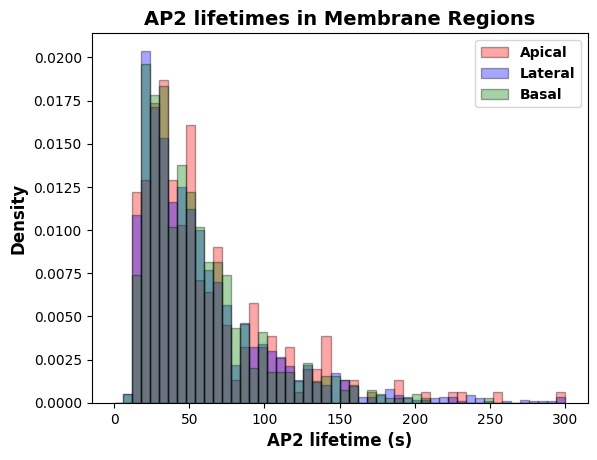

In [26]:
tracks_channel_subset_treatment = trackFilter('All', False, filtered_tracks_treatment)
lumenoid2_frame_ms = 2100
createHistogramAP2Lifetimes(tracks_channel_subset_treatment,lumenoid2_frame_ms,False)

<module 'matplotlib.pyplot' from 'c:\\Users\\Kenny\\anaconda3\\envs\\cme_pipeline\\lib\\site-packages\\matplotlib\\pyplot.py'>

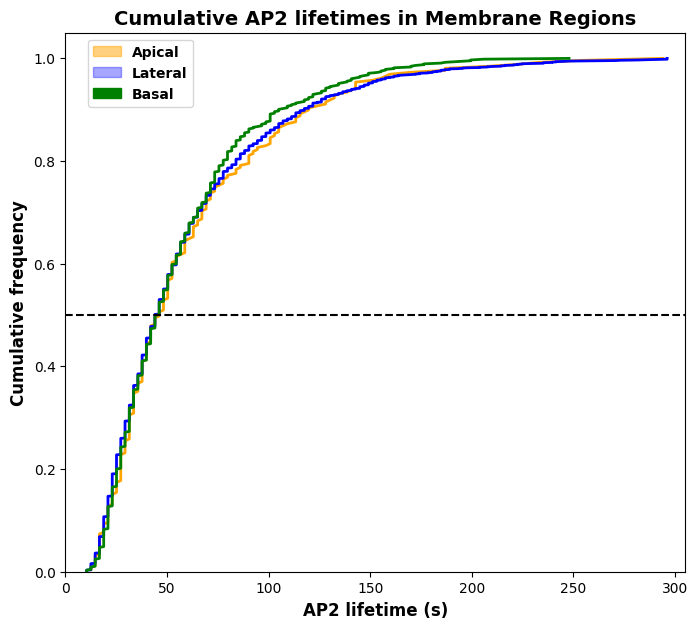

In [27]:
# Cumulative plot of track lifetimes
plot_cumulative_lifetime(tracks_channel_subset_treatment, lumenoid2_frame_ms, [label1, label2, label3])


x: [0.85 1.15]
y: [46.2 46.2]
x: [1.85 2.15]
y: [44.1 44.1]
x: [2.85 3.15]
y: [46.2 46.2]


C:\Users\Kenny\AppData\Local\Temp\ipykernel_11060\1416389447.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[label1, label2, label3])


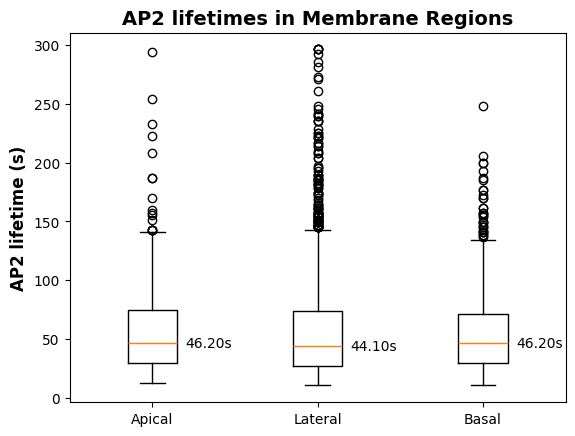

In [28]:
createBoxWhiskerPlot(tracks_channel_subset_treatment,False,lumenoid2_frame_ms)

In [29]:
apical_tracks = trackFilter('Apical', False, filtered_tracks_treatment)
filtered_tracks_treatment.columns

Index(['mu_x', 'mu_y', 'mu_z', 'track_id', 'track_length', 'track_start',
       'track_end', 'c3_peak', 'c2_peak', 'c1_peak', 'c3_peak_frame',
       'c2_peak_frame', 'c1_peak_frame', 'mean_displacement', 'mean_z',
       'mean_z_displacement', 'max_radius_from_origin',
       'max_distance_between_two_points', 'C3_adjusted_voxel_sum',
       'C2_adjusted_voxel_sum', 'C1_adjusted_voxel_sum',
       'C3_adjusted_voxel_sum_peak', 'C2_adjusted_voxel_sum_peak',
       'C1_adjusted_voxel_sum_peak', 'C3_adjusted_voxel_sum_peak_frame',
       'C2_adjusted_voxel_sum_peak_frame', 'C1_adjusted_voxel_sum_peak_frame',
       'max_z_movement', 'max_y_movement', 'max_x_movement',
       'channel2_positive', 'channel1_positive', 'membrane_region',
       'track_radius'],
      dtype='object')

## Lumenoid 1 Plots

In [30]:
compare_lumenoid_input_file_directory = 'lumenoid_1cropped_analysis/'
compare_lumenoid_df = pd.read_pickle(os.path.join(base_dir, compare_lumenoid_input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))
lumenoid1_frame_ms = 2200


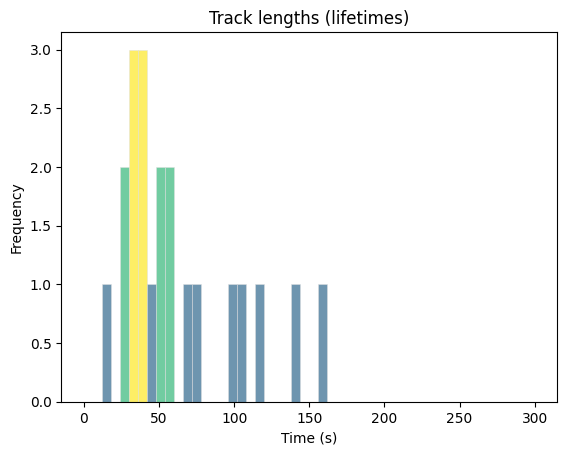

In [31]:
tracks_channel_subset_compare = trackFilter('All', False, compare_lumenoid_df)
createHistogramAP2Lifetimes(tracks_channel_subset_compare,lumenoid1_frame_ms,True)

x: [0.85 1.15]
y: [44. 44.]
x: [1.85 2.15]
y: [24.2 24.2]
x: [2.85 3.15]
y: [24.2 24.2]


C:\Users\Kenny\AppData\Local\Temp\ipykernel_11060\1416389447.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[label1, label2, label3])


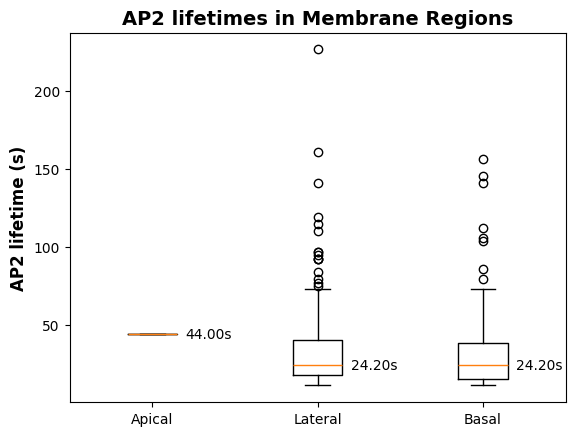

In [32]:
createBoxWhiskerPlot(compare_lumenoid_df,False,lumenoid1_frame_ms)

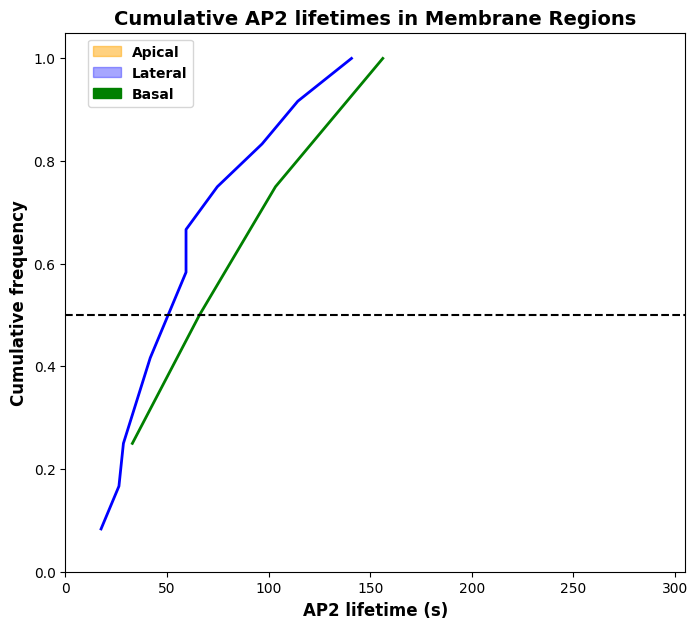

In [33]:

# plt = plot_cumulative_lifetime(all_lifetimes_control_df, all_lifetimes_treatment_df, [label1, label2], title)
plt = plot_cumulative_lifetime(tracks_channel_subset_compare, lumenoid1_frame_ms, [label1, label2, label3])
# if plot_all_channels == True:
#     plt.text(0.5, 0.8, f'Plotting all channels: {plot_all_channels}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# if plot_all_channels == False:
#     plt.text(0.5, 0.8, f'Plotting channels: {channels_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# plt.text(0.5, 0.75, f'Plotting region: {region_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')

plt.show()

## Lumenoid 1 and Lumenoid 2 Comparasion Plots

x: [0.925 1.075]
y: [44.1 44.1]
x: [1.925 2.075]
y: [29.4 29.4]


C:\Users\Kenny\AppData\Local\Temp\ipykernel_1368\696557318.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[lumenoid1_name, lumenoid2_name])


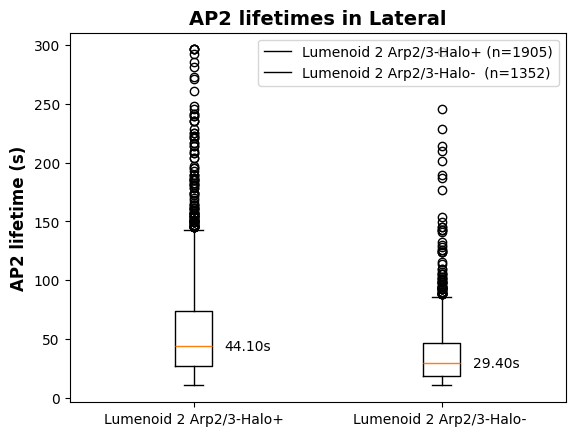

In [39]:
channels_to_plot = [True,True]
arp_negative = [False, True]
first_lumenoid = trackFilter('All', False, filtered_tracks_treatment, channels_to_plot)
second_lumenoid = trackFilter('All', False, filtered_tracks_treatment,arp_negative)
compareLumenoidsBoxPlot(first_lumenoid, second_lumenoid, 'Lateral', 'Lumenoid 2 Arp2/3-Halo+', 'Lumenoid 2 Arp2/3-Halo- ', lumenoid2_frame_ms, lumenoid2_frame_ms)


C:\Users\Kenny\AppData\Local\Temp\ipykernel_1368\696557318.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[lumenoid1_name, lumenoid2_name])


x: [0.925 1.075]
y: [44.1 44.1]
x: [1.925 2.075]
y: [25.2 25.2]


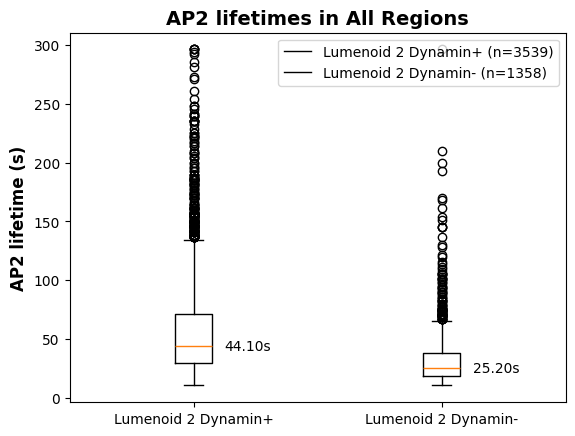

In [40]:
channels_to_plot = [True,True]
arp_negative = [False, True]
dynamin_negative = [True, False]
first_lumenoid = trackFilter('All', False, filtered_tracks_treatment,channels_to_plot)
second_lumenoid = trackFilter('All', False, filtered_tracks_treatment,dynamin_negative)
compareLumenoidsBoxPlot(first_lumenoid, second_lumenoid, 'All', 'Lumenoid 2 Dynamin+', 'Lumenoid 2 Dynamin-', lumenoid2_frame_ms, lumenoid2_frame_ms)


In [41]:
calculate_region_stats(filtered_tracks_treatment, lumenoid2_frame_ms, 'channel1', 'Apical')

Total tracks in Apical: 880
Total Arp2/3+ Dynamin+ in Apical: 259
Total Arp2/3- Dynamin+ in Apical: 230
Percentage of Arp2/3+ Dynamin+ tracks in Apical: 29.43%
Percentage of Arp2/3- Dynamin+ in Apical: 26.14%
Mean lifetime of Arp2/3+ Dynamin+ in Apical: 60.35 s
Mean lifetime of Arp2/3- Dynamin+ in Apical: 36.43 s


## Intensity Plots

In [66]:
lumenoid_intensity = trackFilter('All', False, filtered_tracks_treatment,channels_to_plot)
intensity_region_plot(lumenoid_intensity,True,True,'channel1')

NameError: name 'channels_to_plot' is not defined

In [ ]:
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
intensity_track = pd.read_pickle(input_directory_all_tracks_full)

#### Apical Intensity

number of tracks between [5,10] frames long are 33
number of tracks between [11,15] frames long are 46
number of tracks between [16,20] frames long are 45
number of tracks between [21,25] frames long are 32
number of tracks between [26,30] frames long are 18
number of tracks between [31,40] frames long are 29
number of tracks between [41,90] frames long are 51


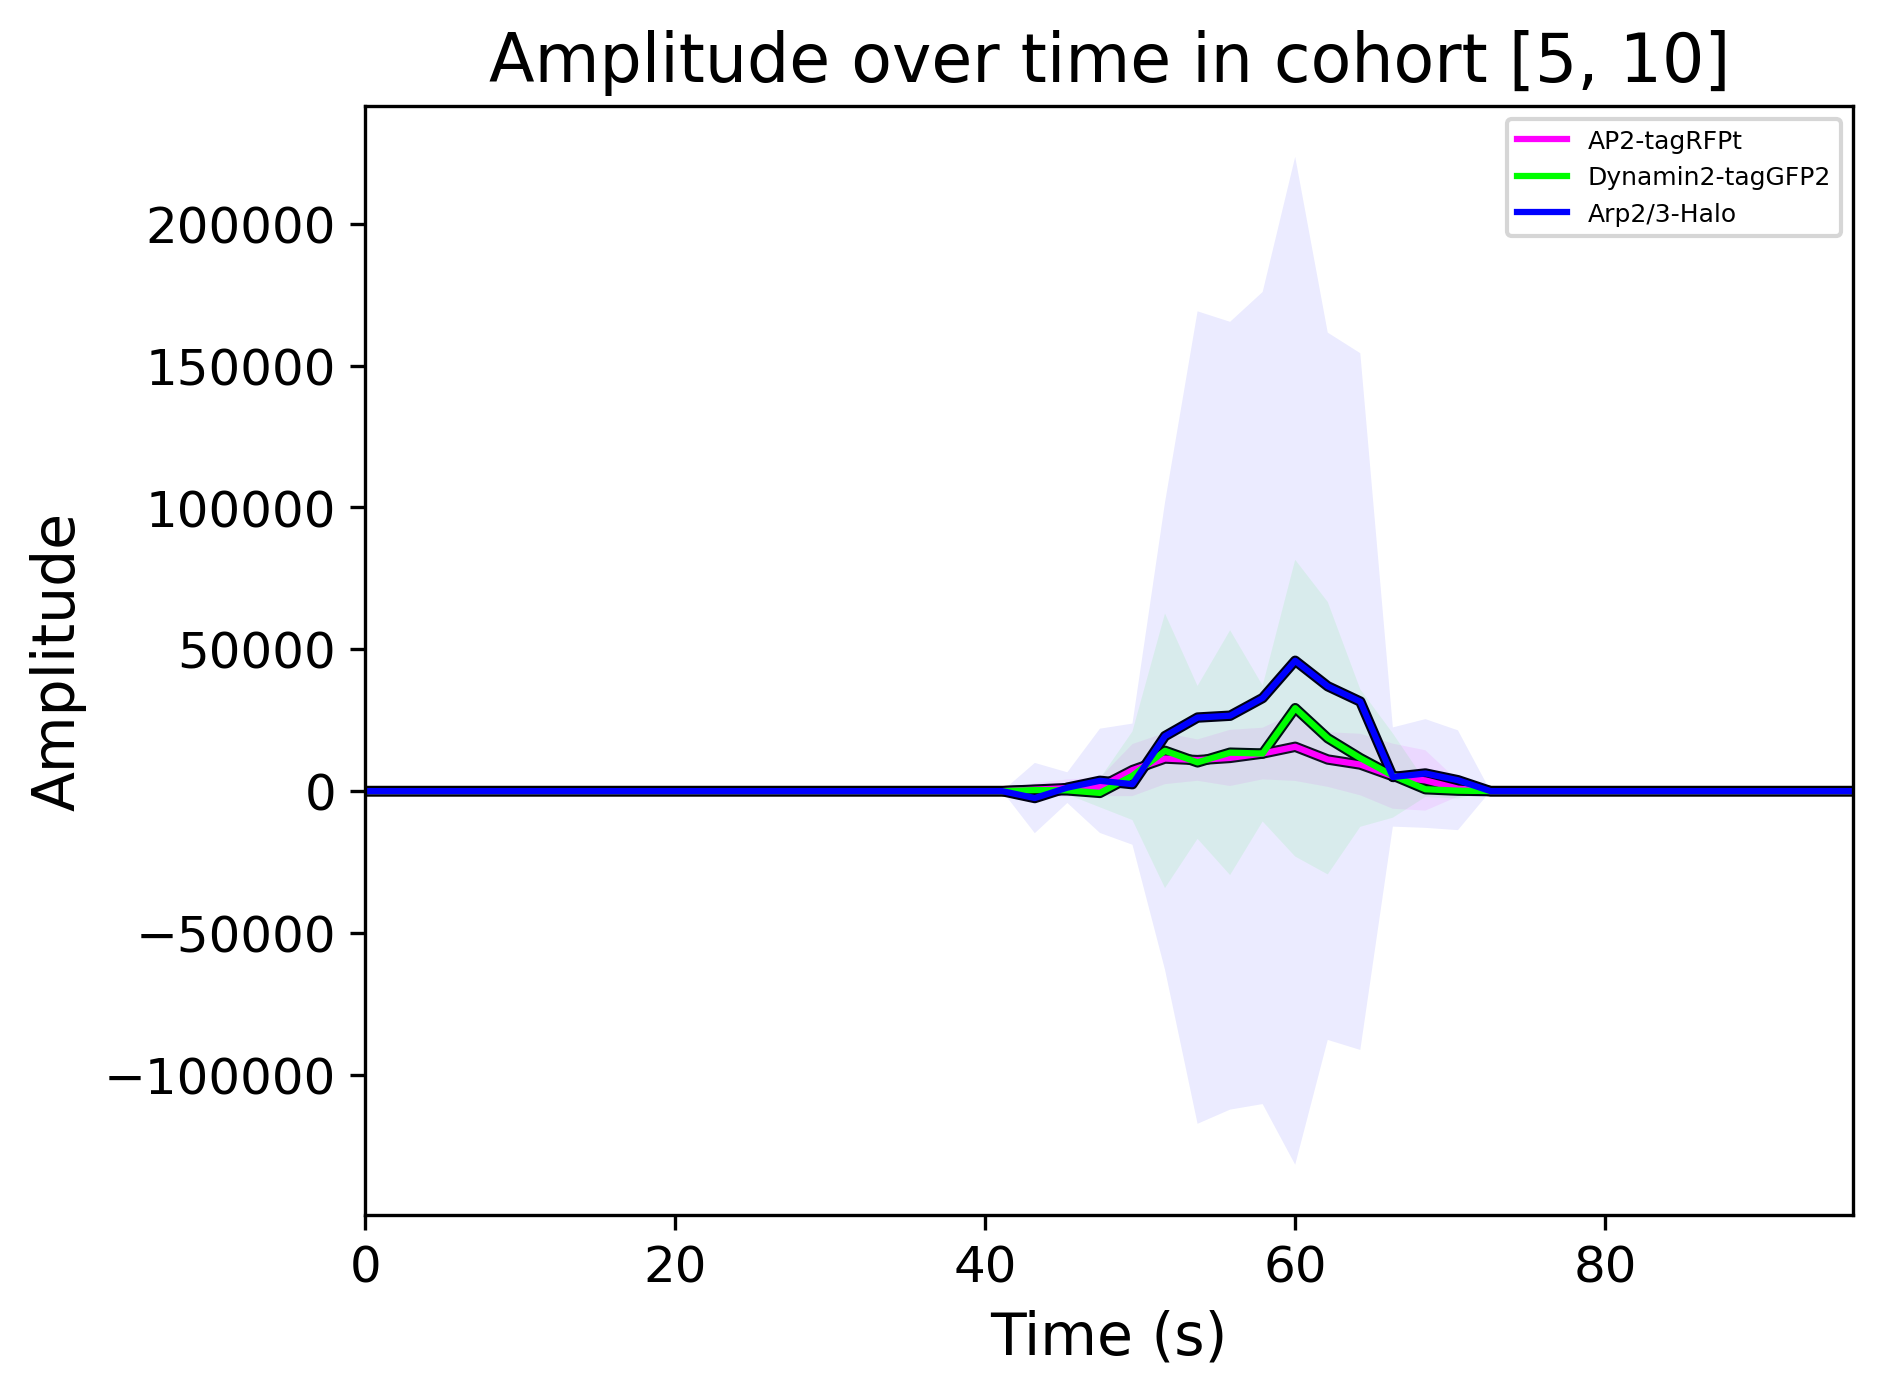

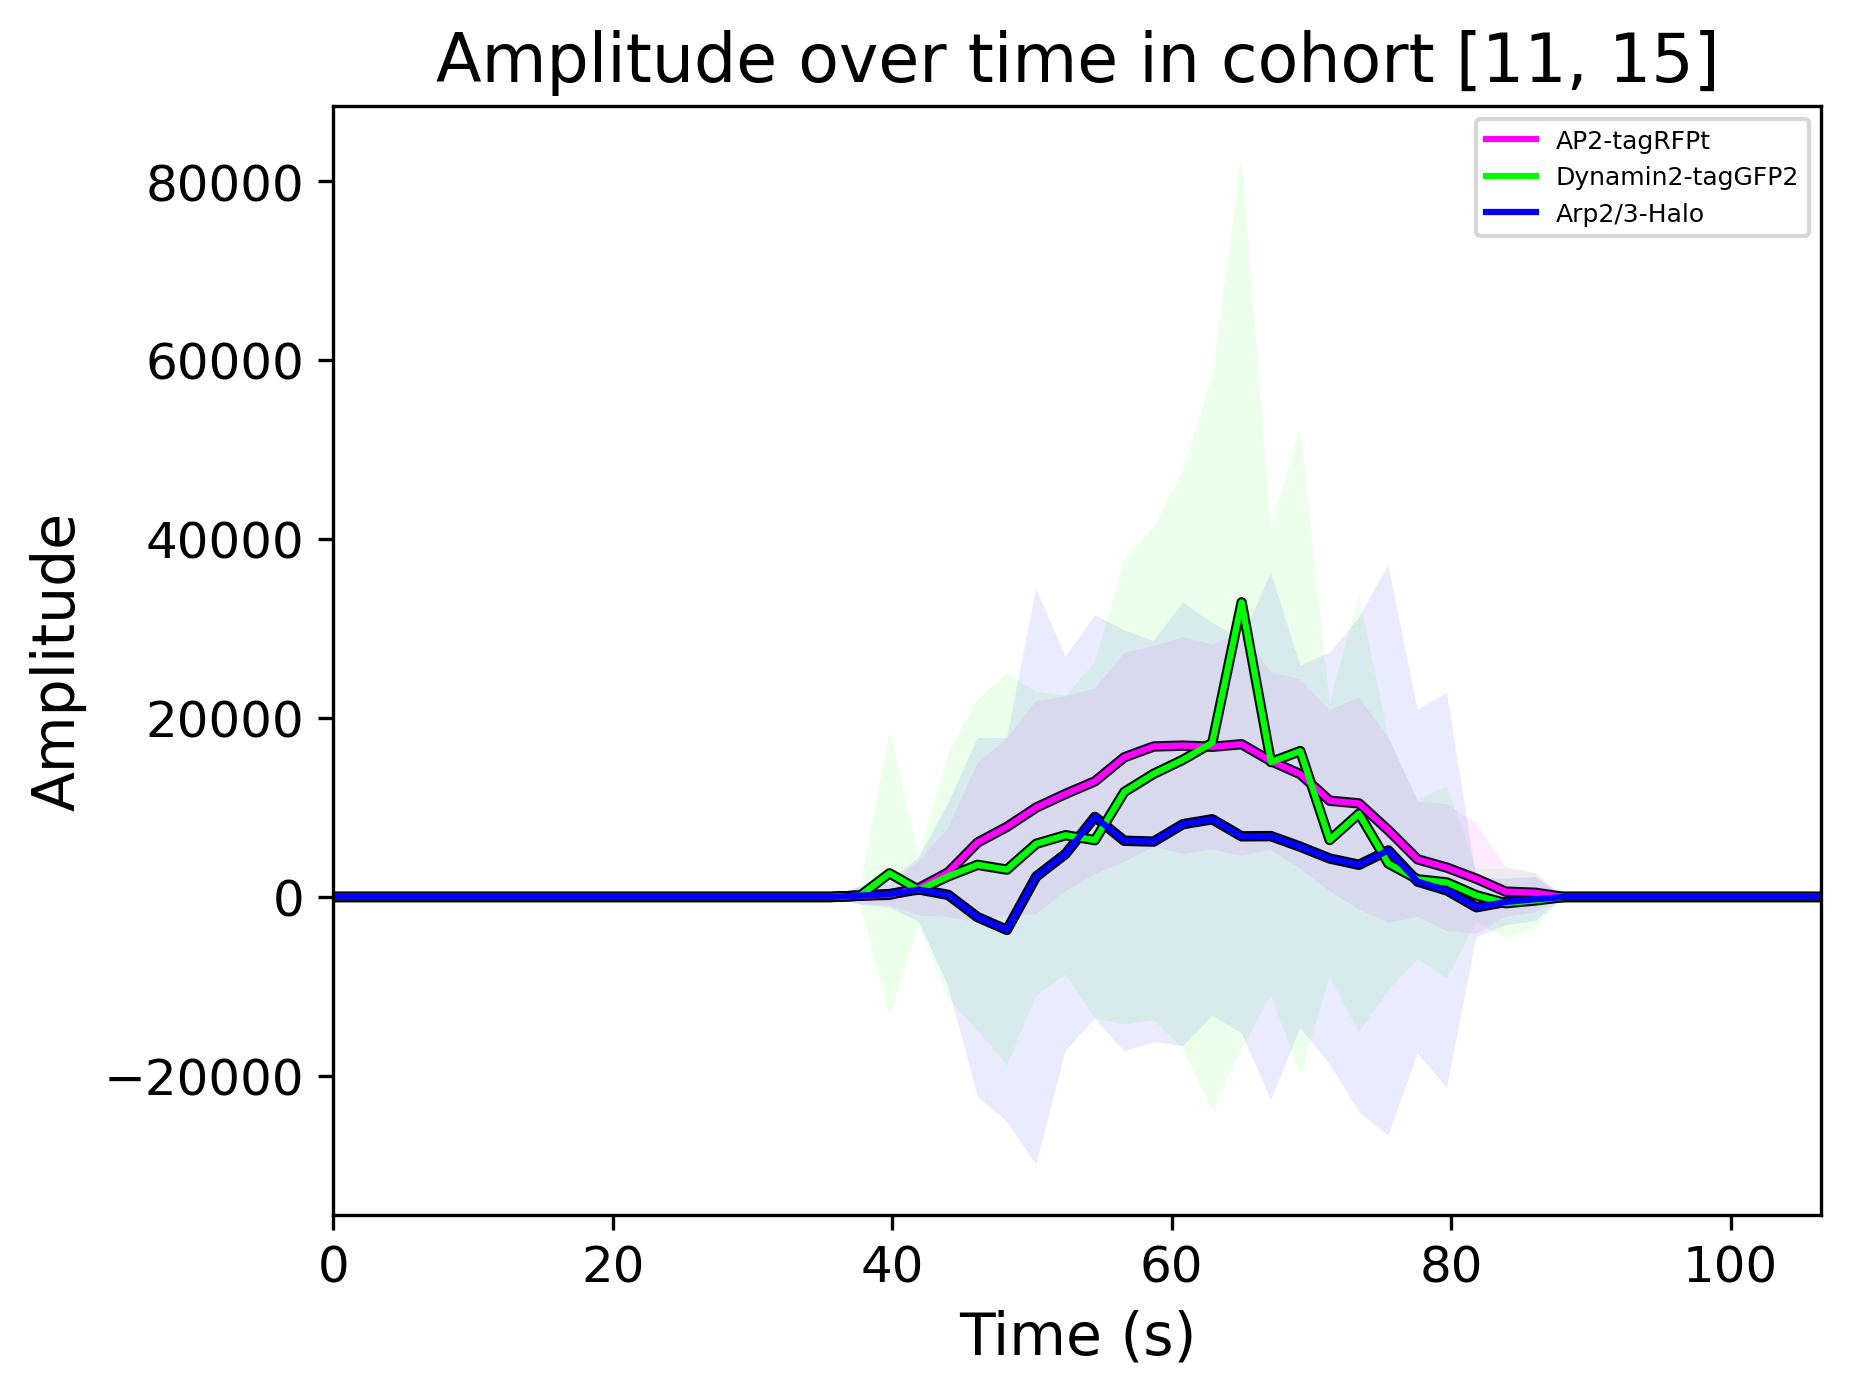

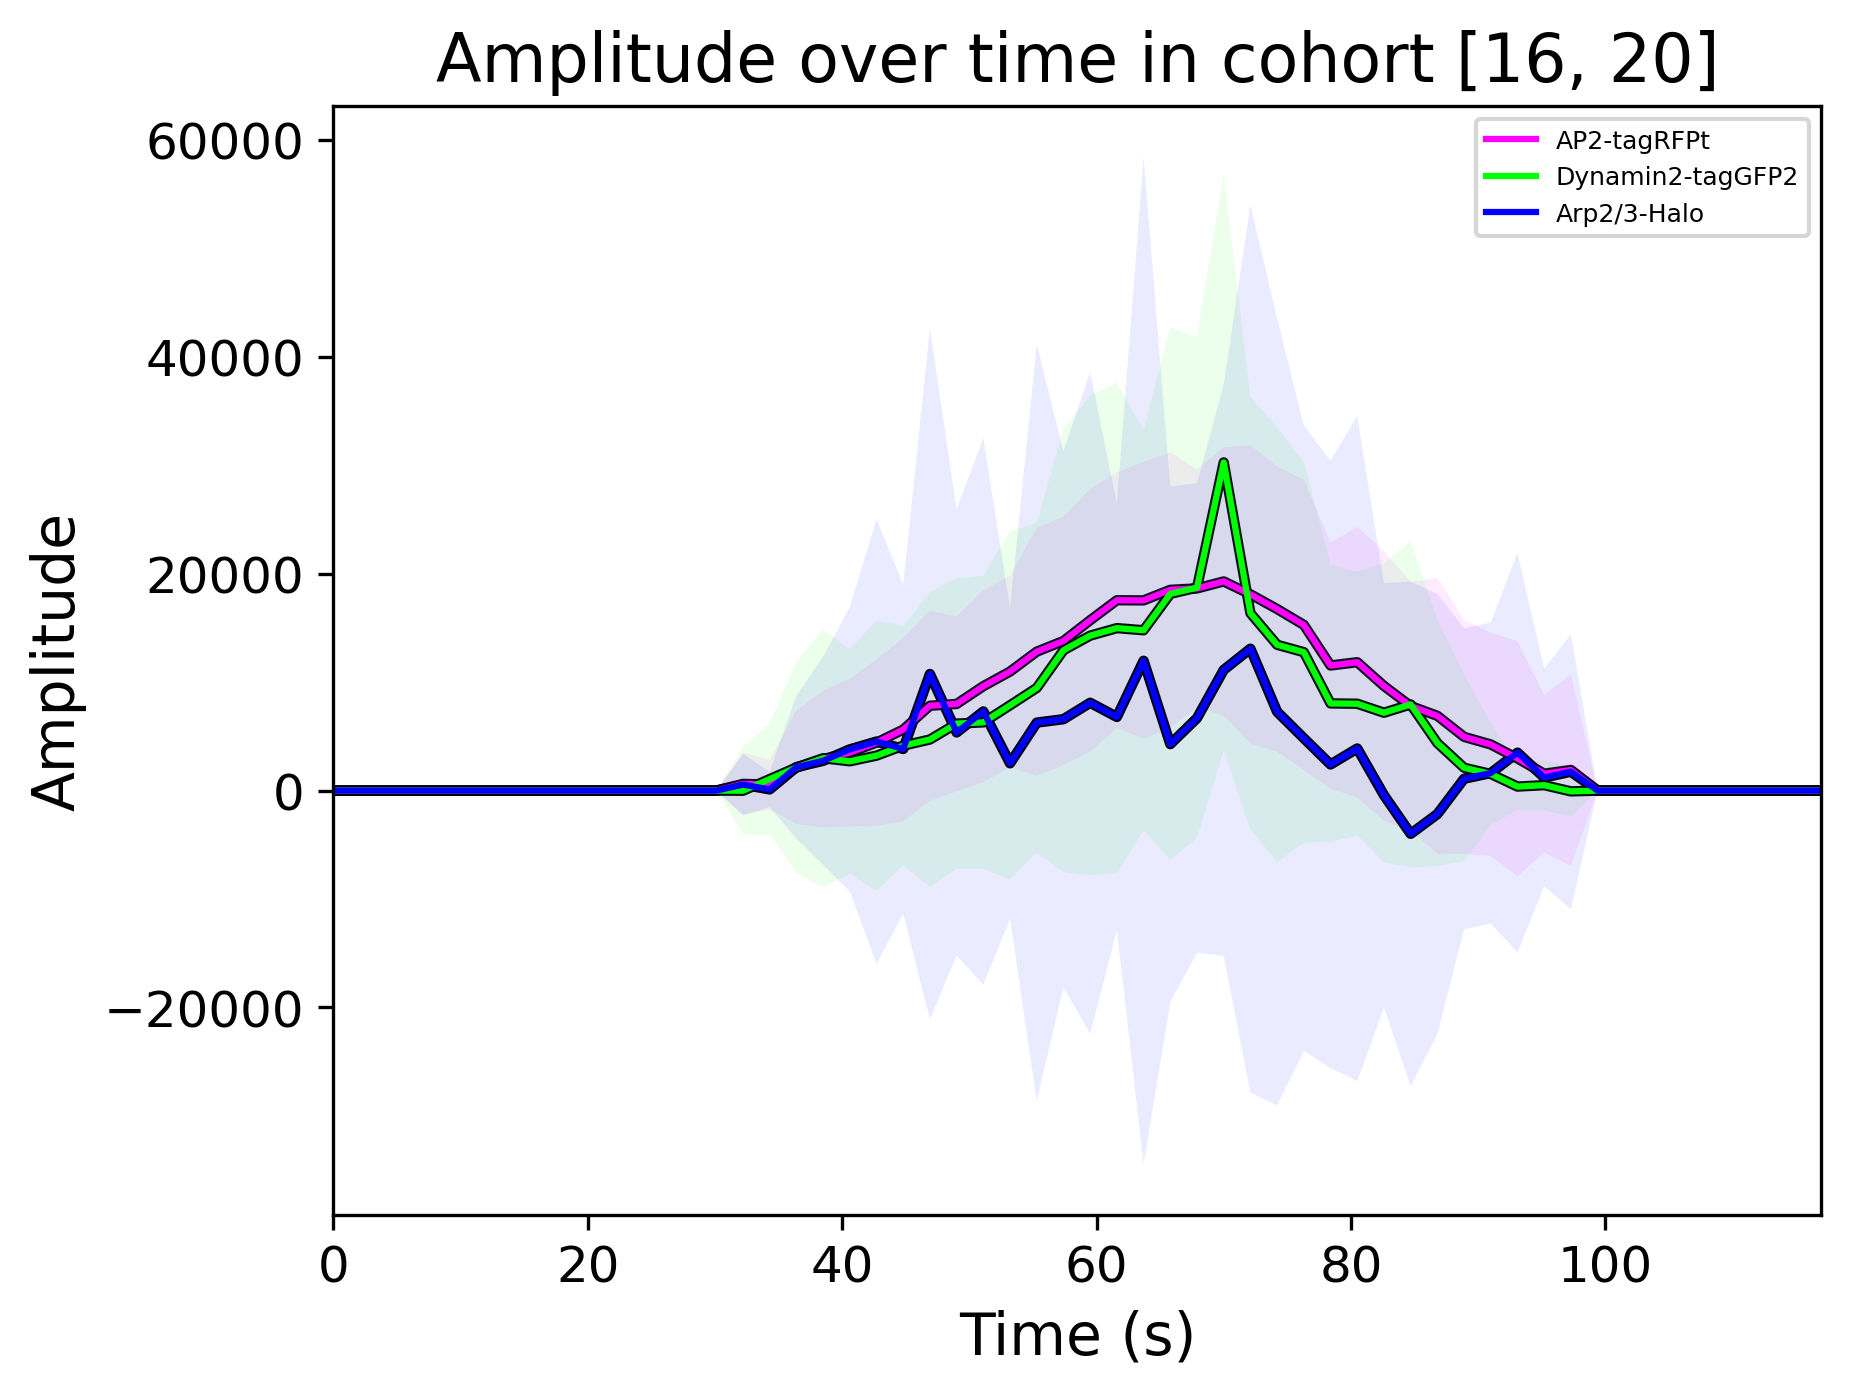

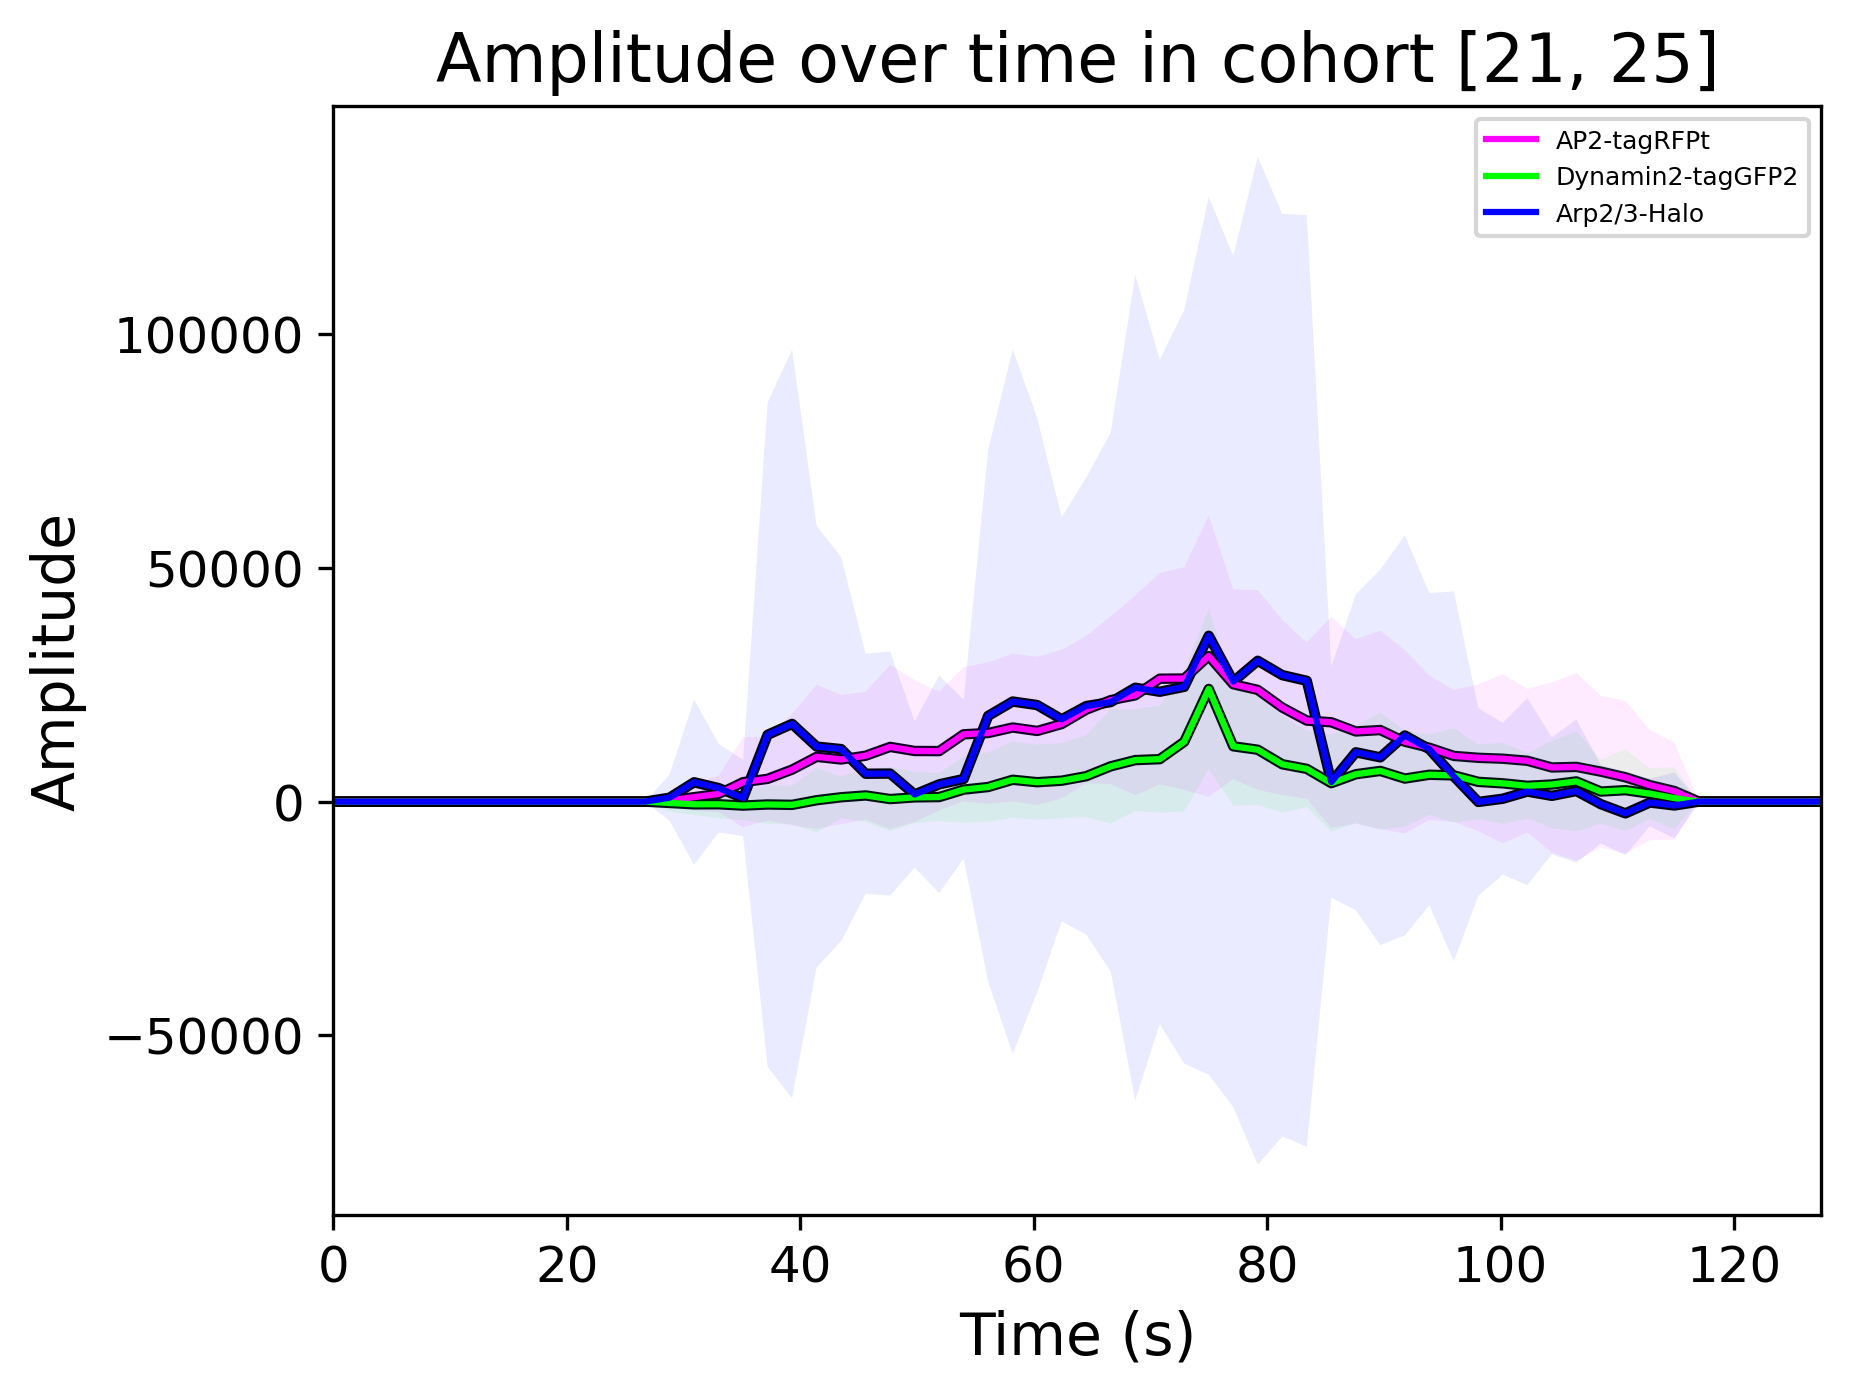

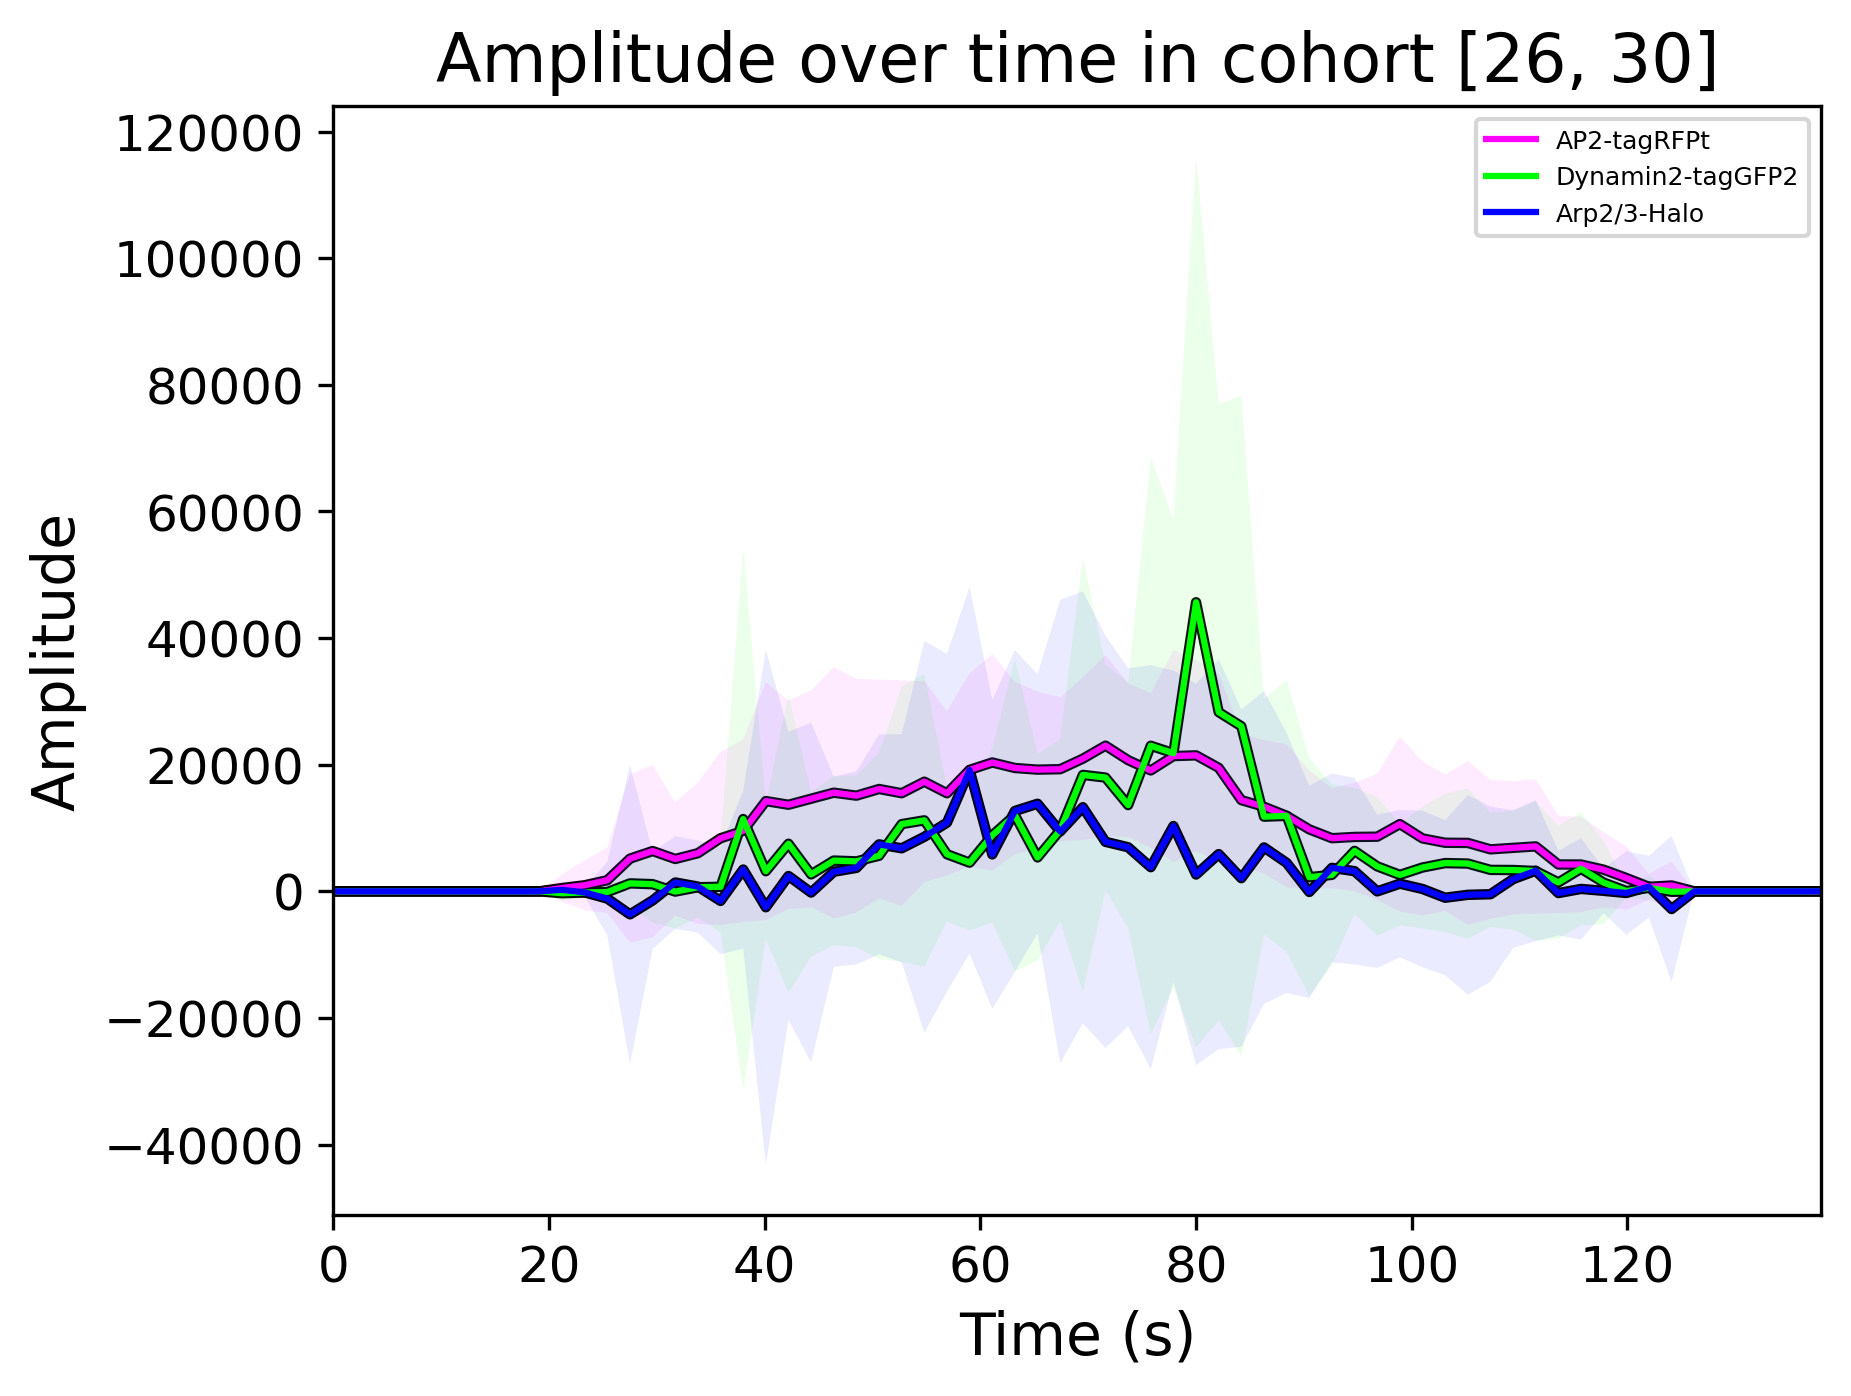

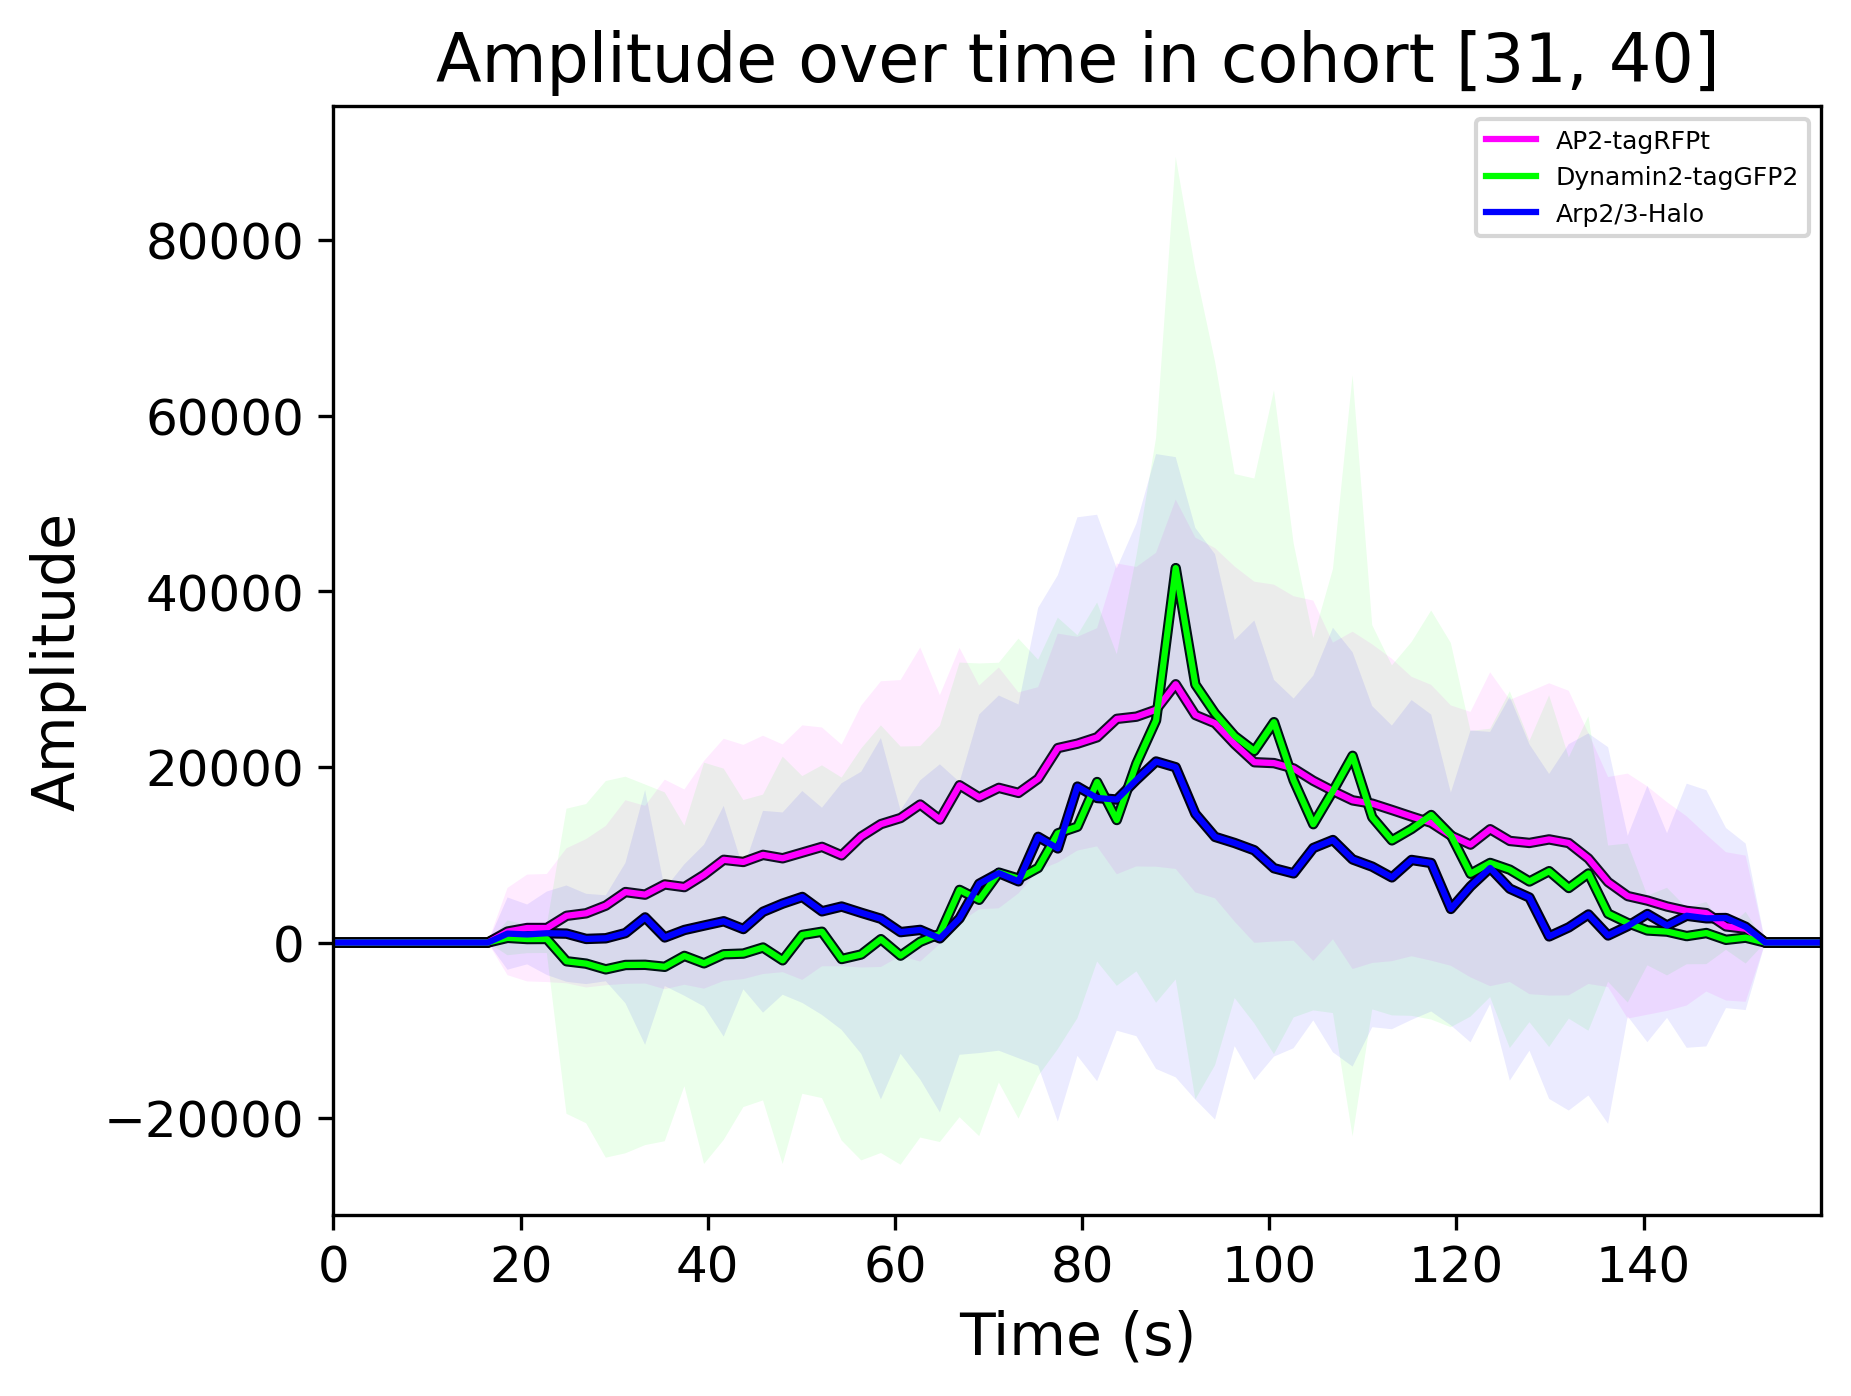

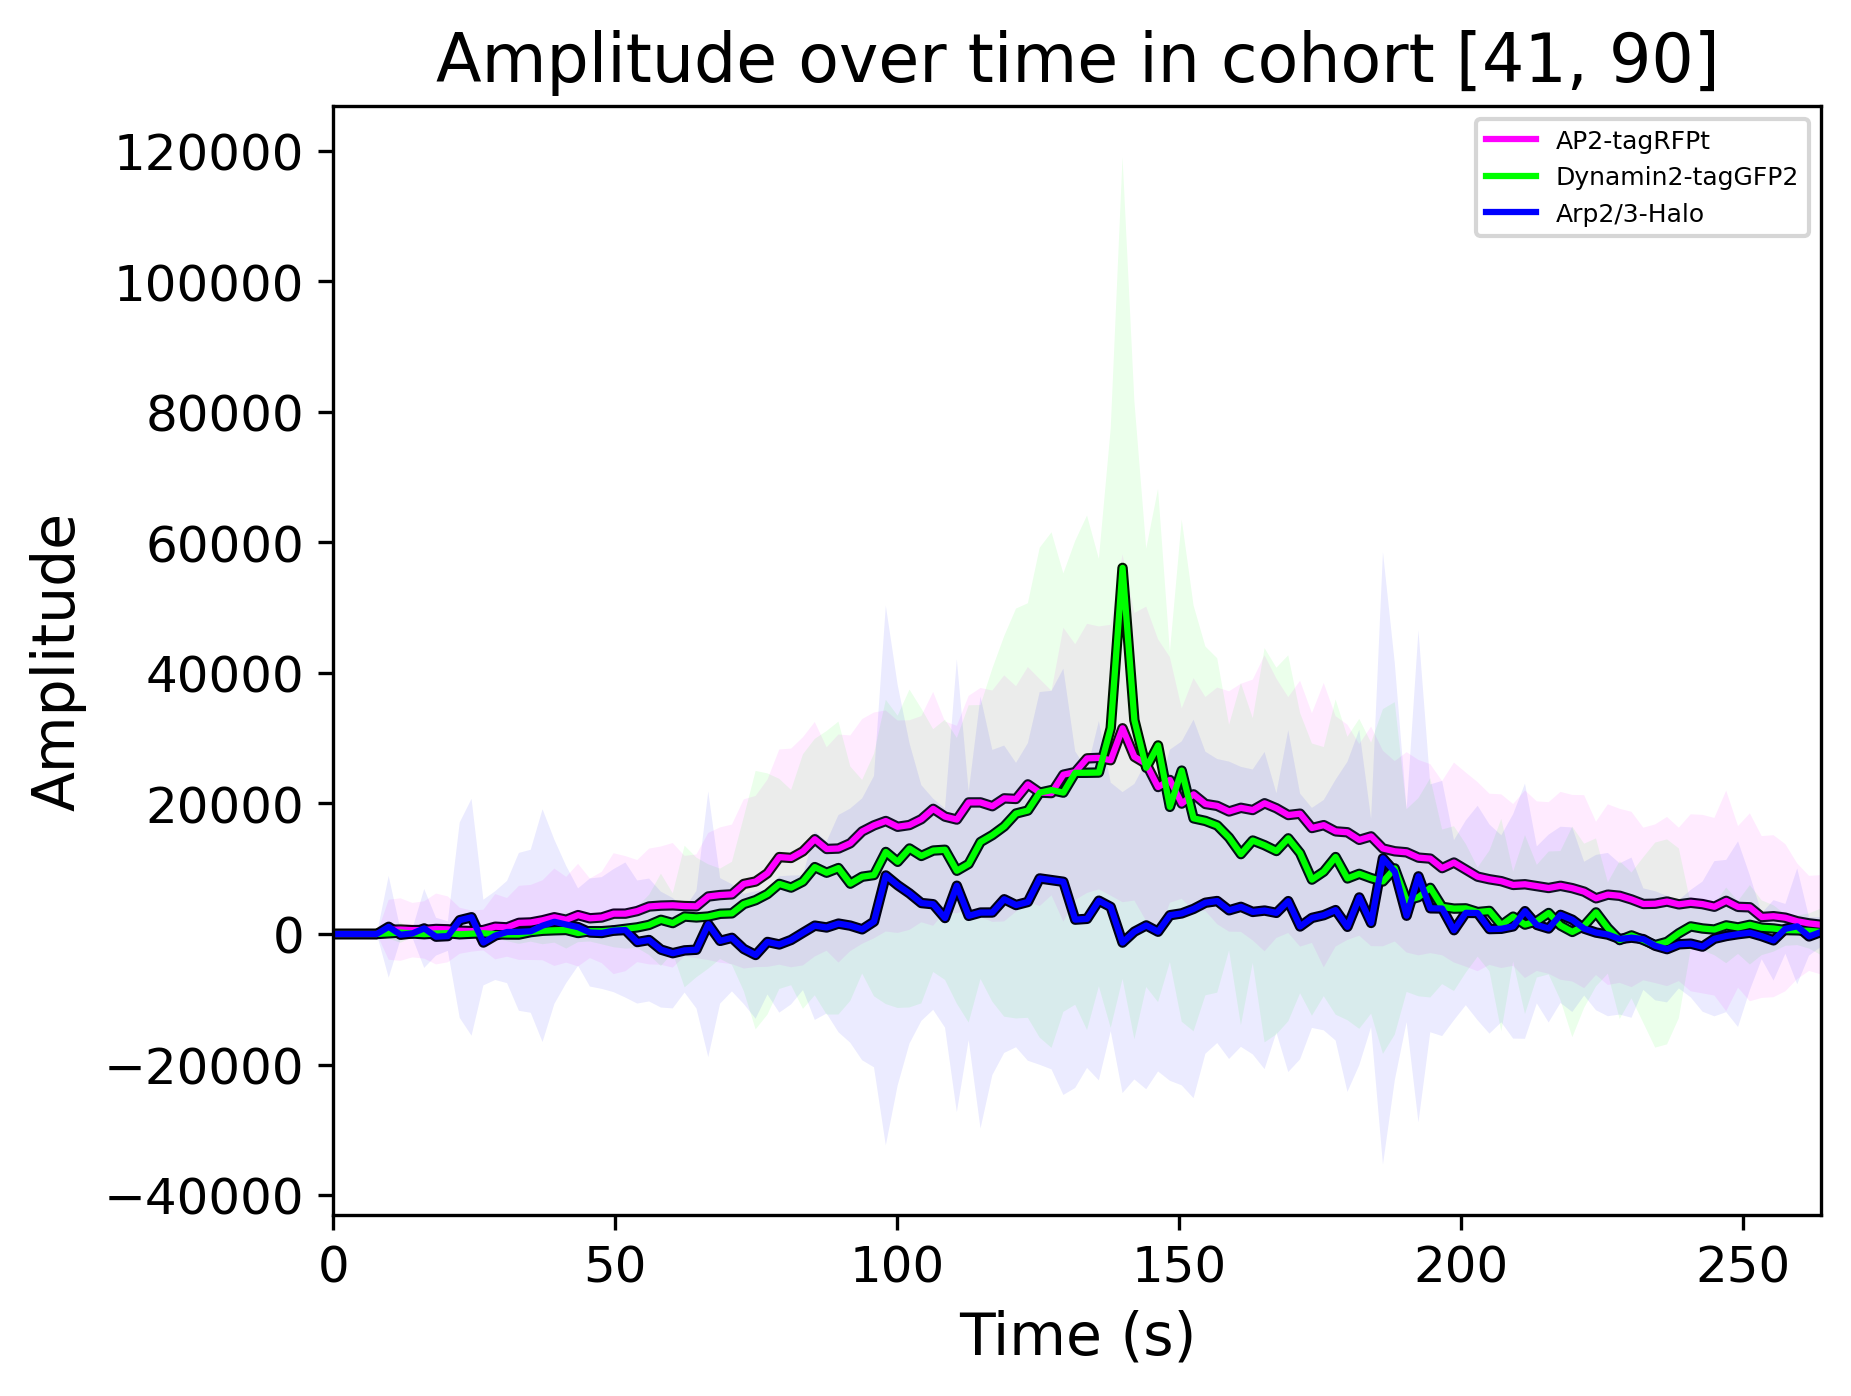

In [ ]:
apical_tracks = trackFilter('Apical', False, filtered_tracks_treatment)
track_id_arrays = filter_track_ids_by_length_ranges(dataframe = apical_tracks, track_length_buckets = custom_length_ranges, 
                                 track_id_col_name = 'track_id', track_length_col_name = 'track_length')

print(f'number of tracks between [5,10] frames long are {len(track_id_arrays[0])}')
print(f'number of tracks between [11,15] frames long are {len(track_id_arrays[1])}')
print(f'number of tracks between [16,20] frames long are {len(track_id_arrays[2])}')
print(f'number of tracks between [21,25] frames long are {len(track_id_arrays[3])}')
print(f'number of tracks between [26,30] frames long are {len(track_id_arrays[4])}')
print(f'number of tracks between [31,40] frames long are {len(track_id_arrays[5])}')
print(f'number of tracks between [41,90] frames long are {len(track_id_arrays[6])}')
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0
cohort_intensity(intensity_track,track_id_arrays, lumenoid2_frame_ms, [background_channel_3, background_channel_2, background_channel_1], value_to_plot=value_to_plot)



#### Lateral Intensity

number of tracks between [5,10] frames long are 280
number of tracks between [11,15] frames long are 338
number of tracks between [16,20] frames long are 292
number of tracks between [21,25] frames long are 228
number of tracks between [26,30] frames long are 177
number of tracks between [31,40] frames long are 216
number of tracks between [41,90] frames long are 335


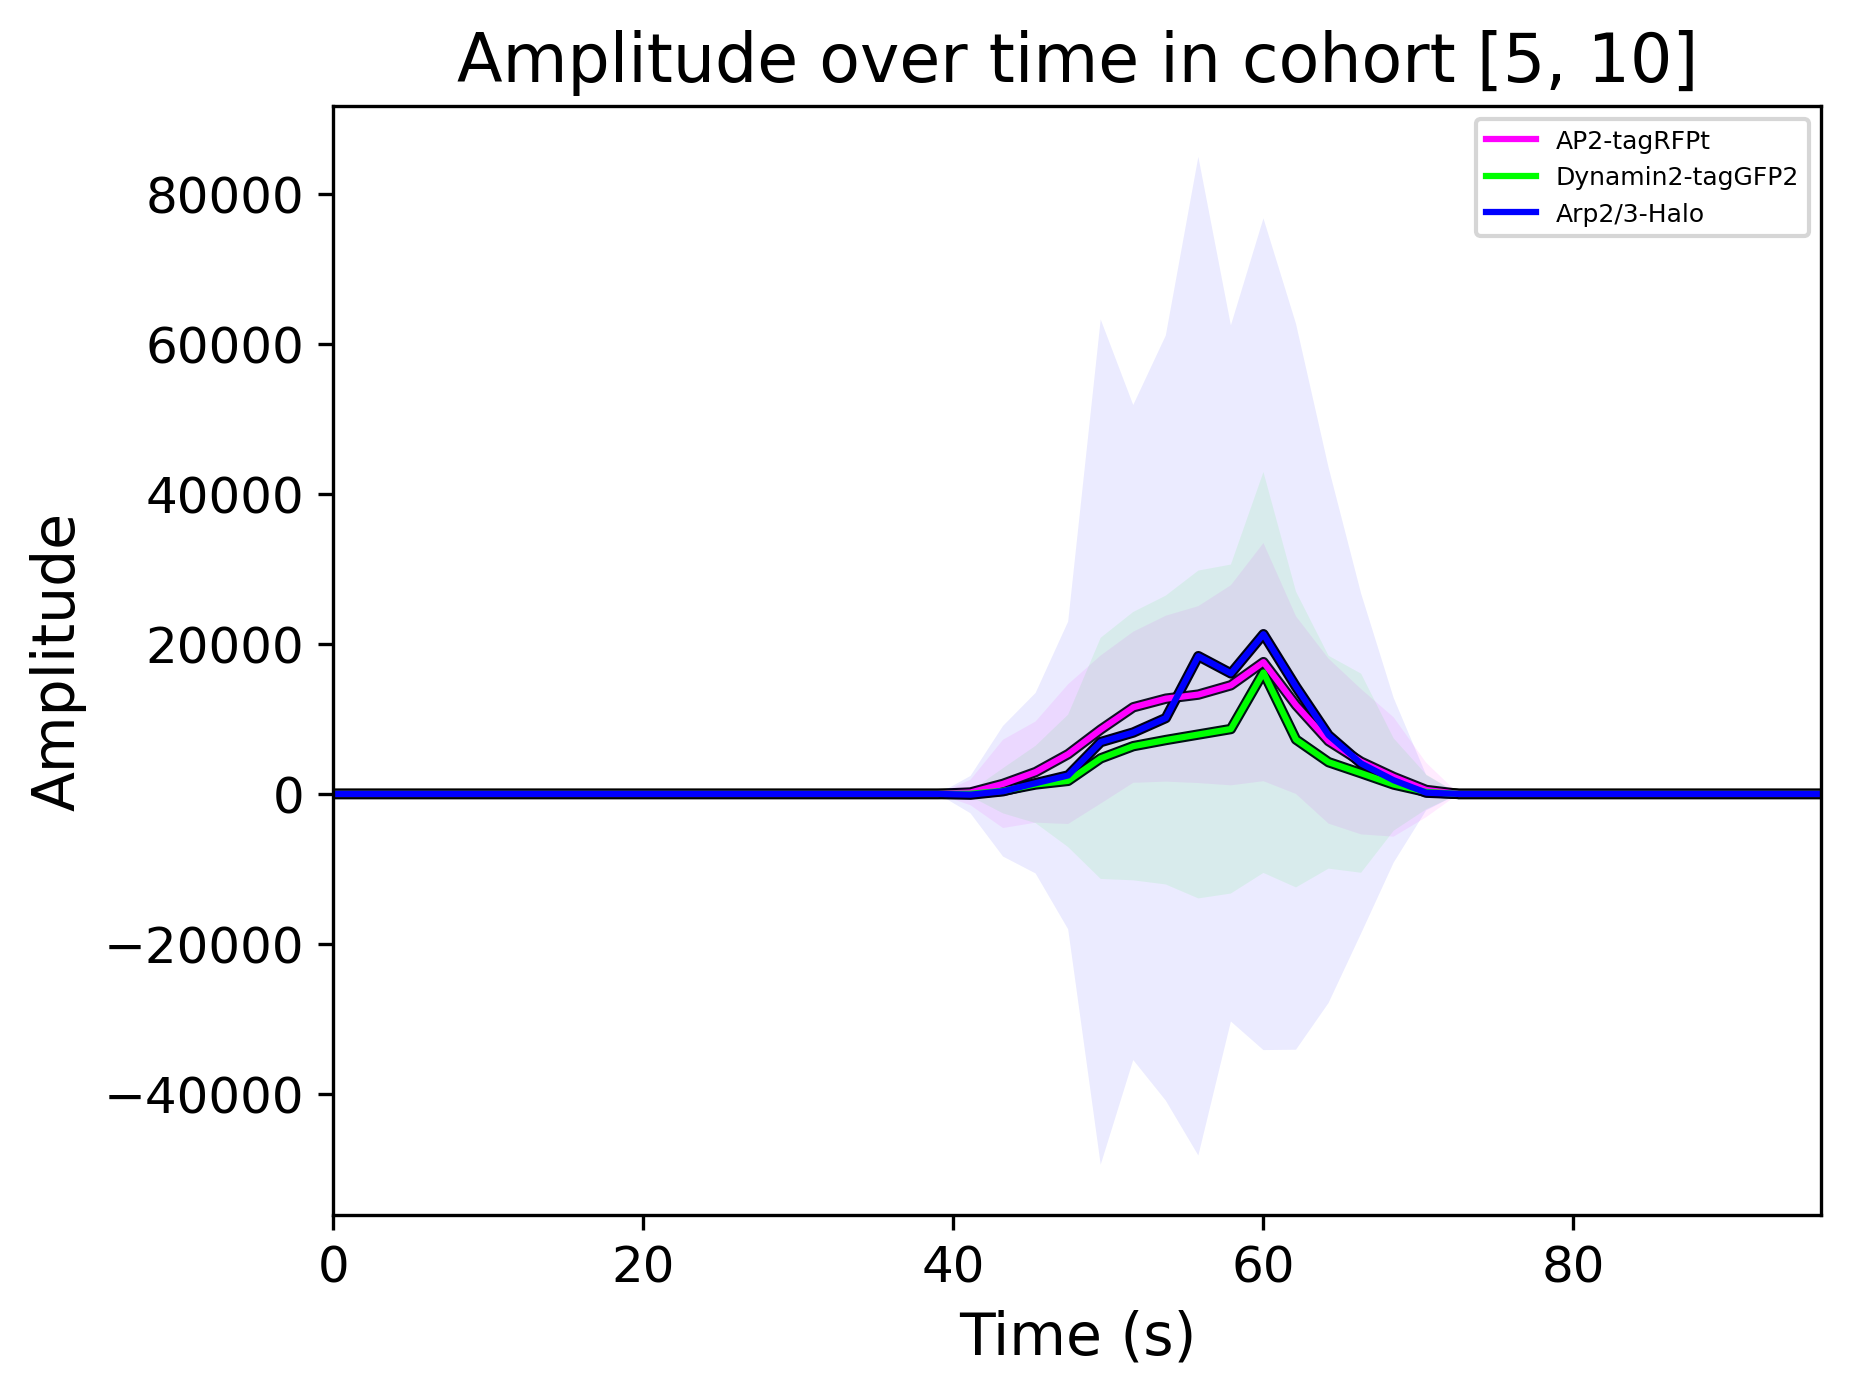

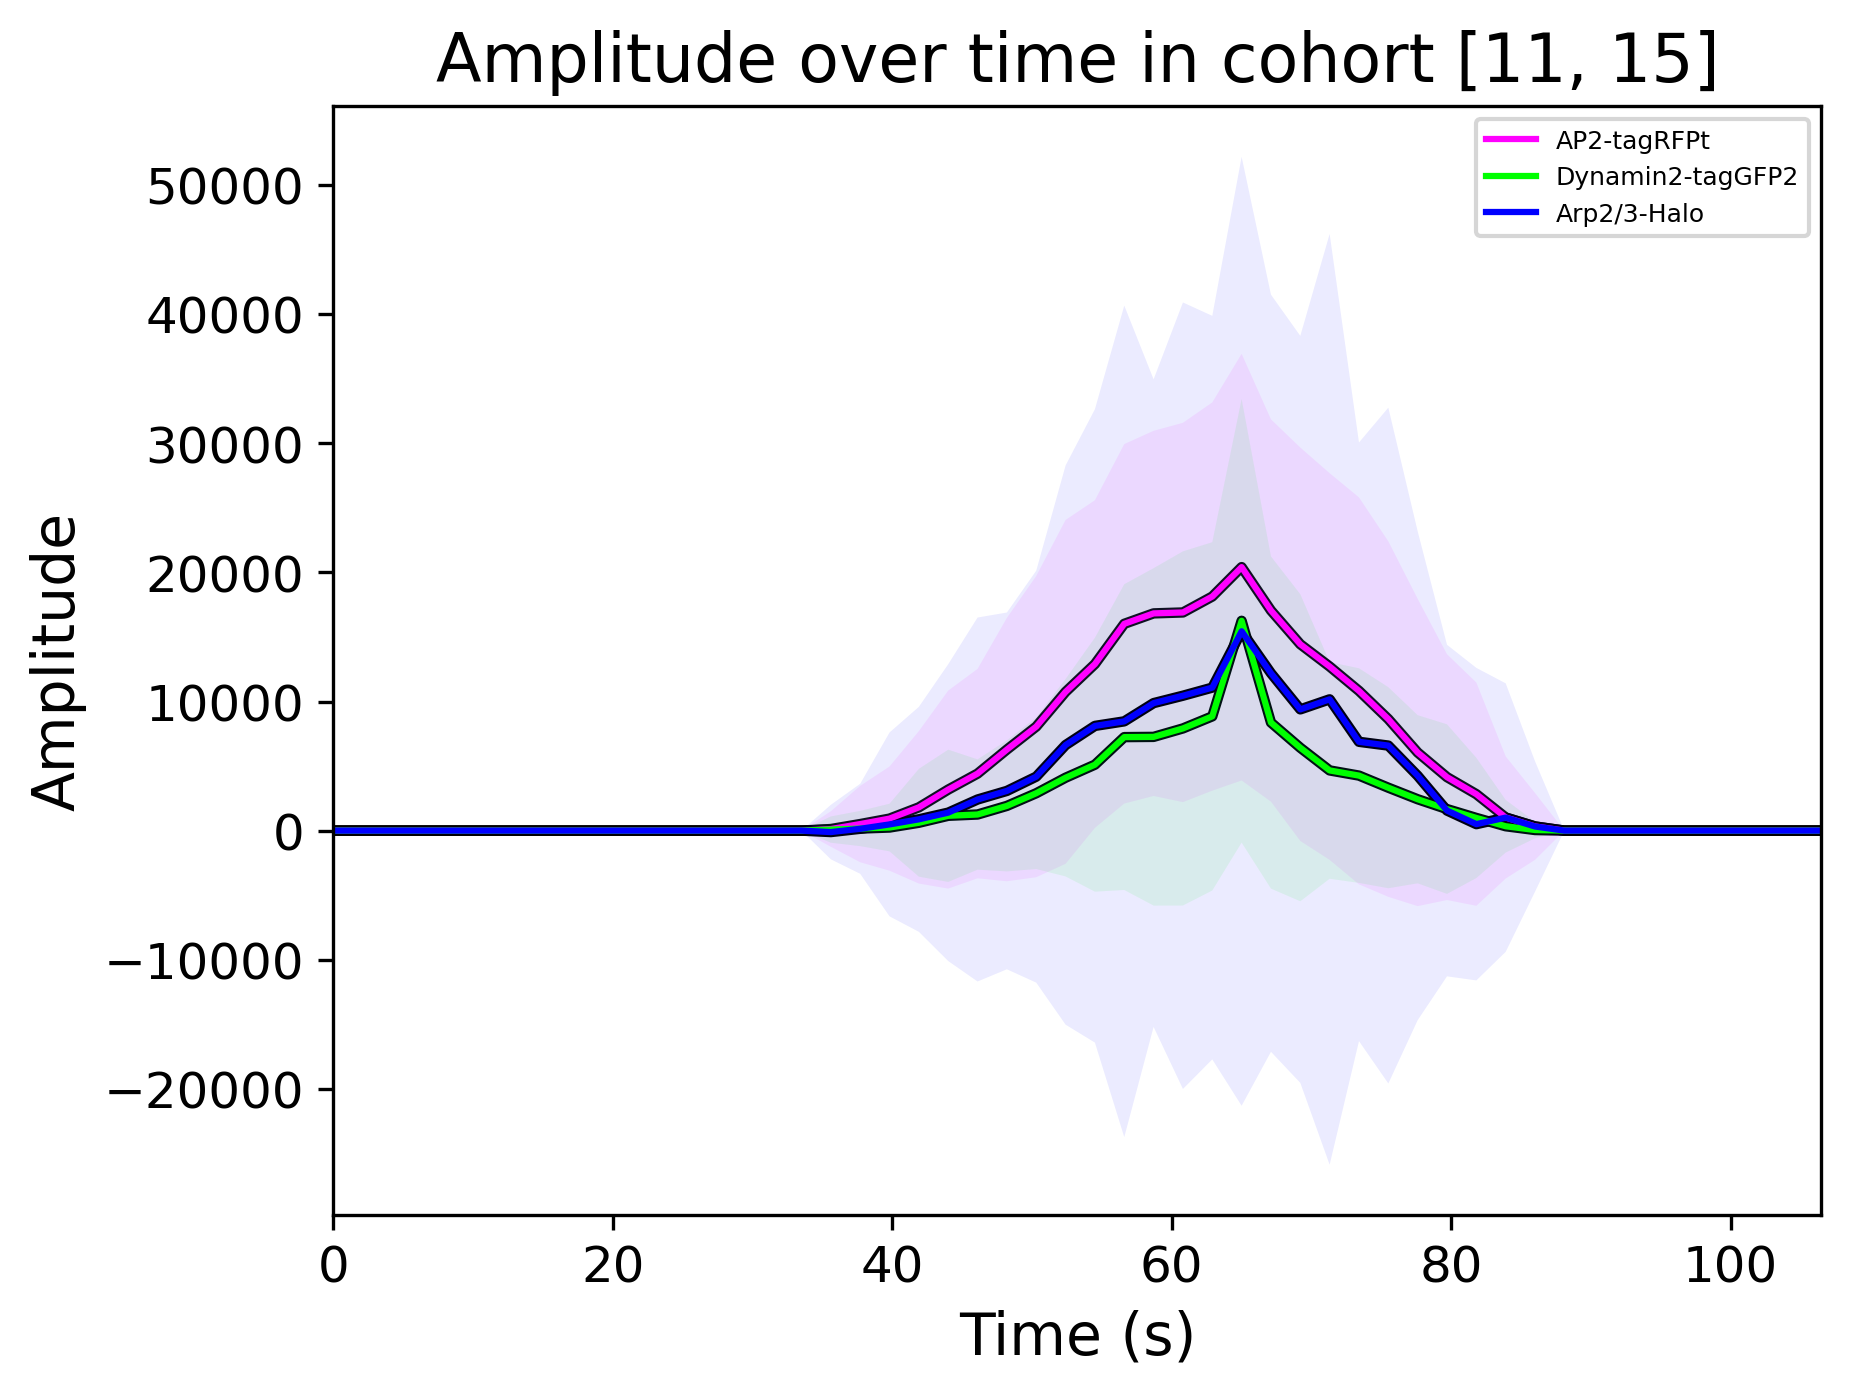

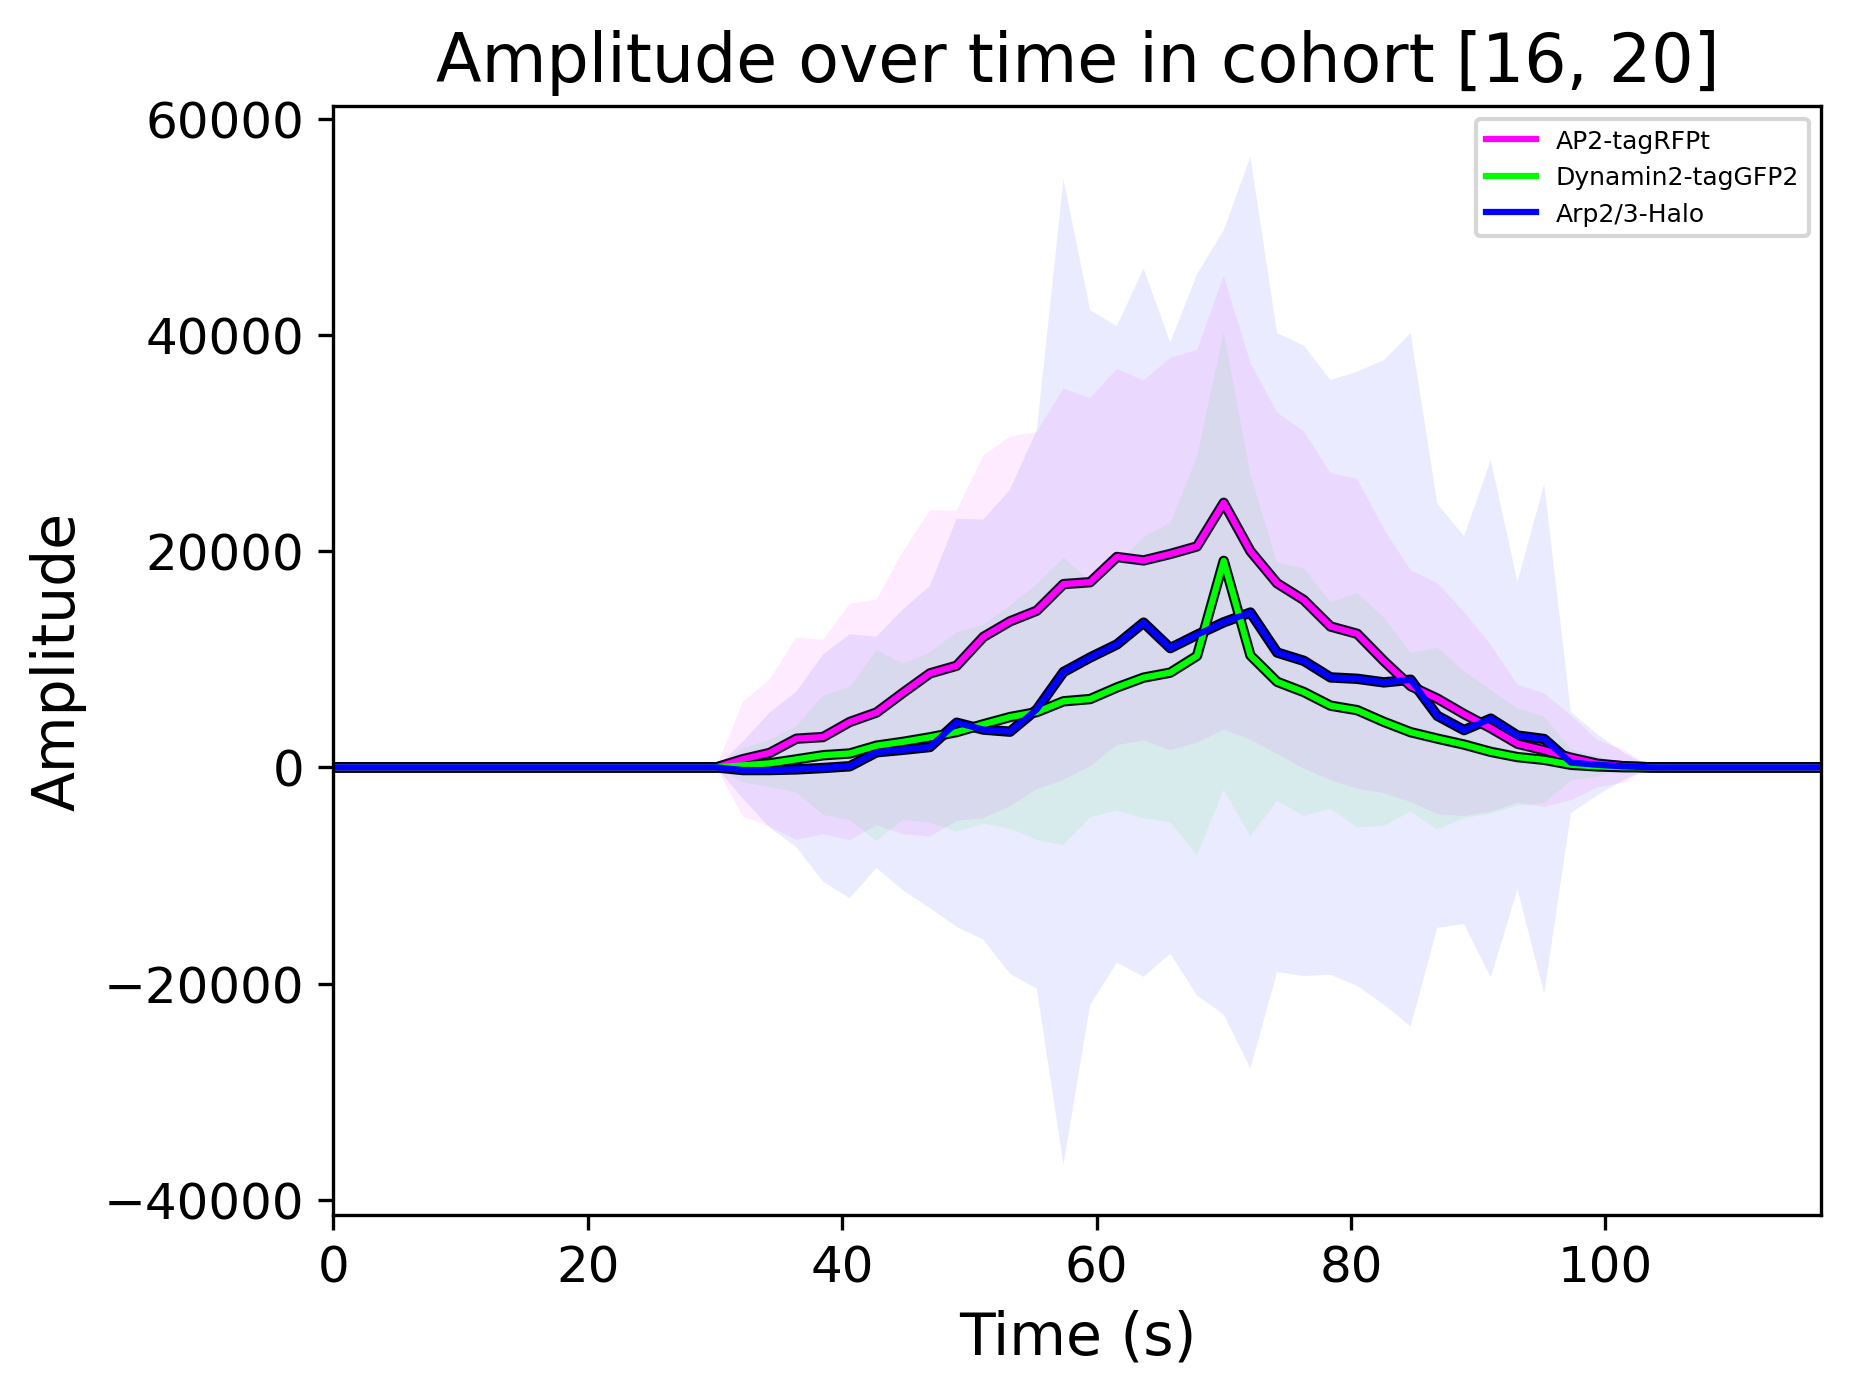

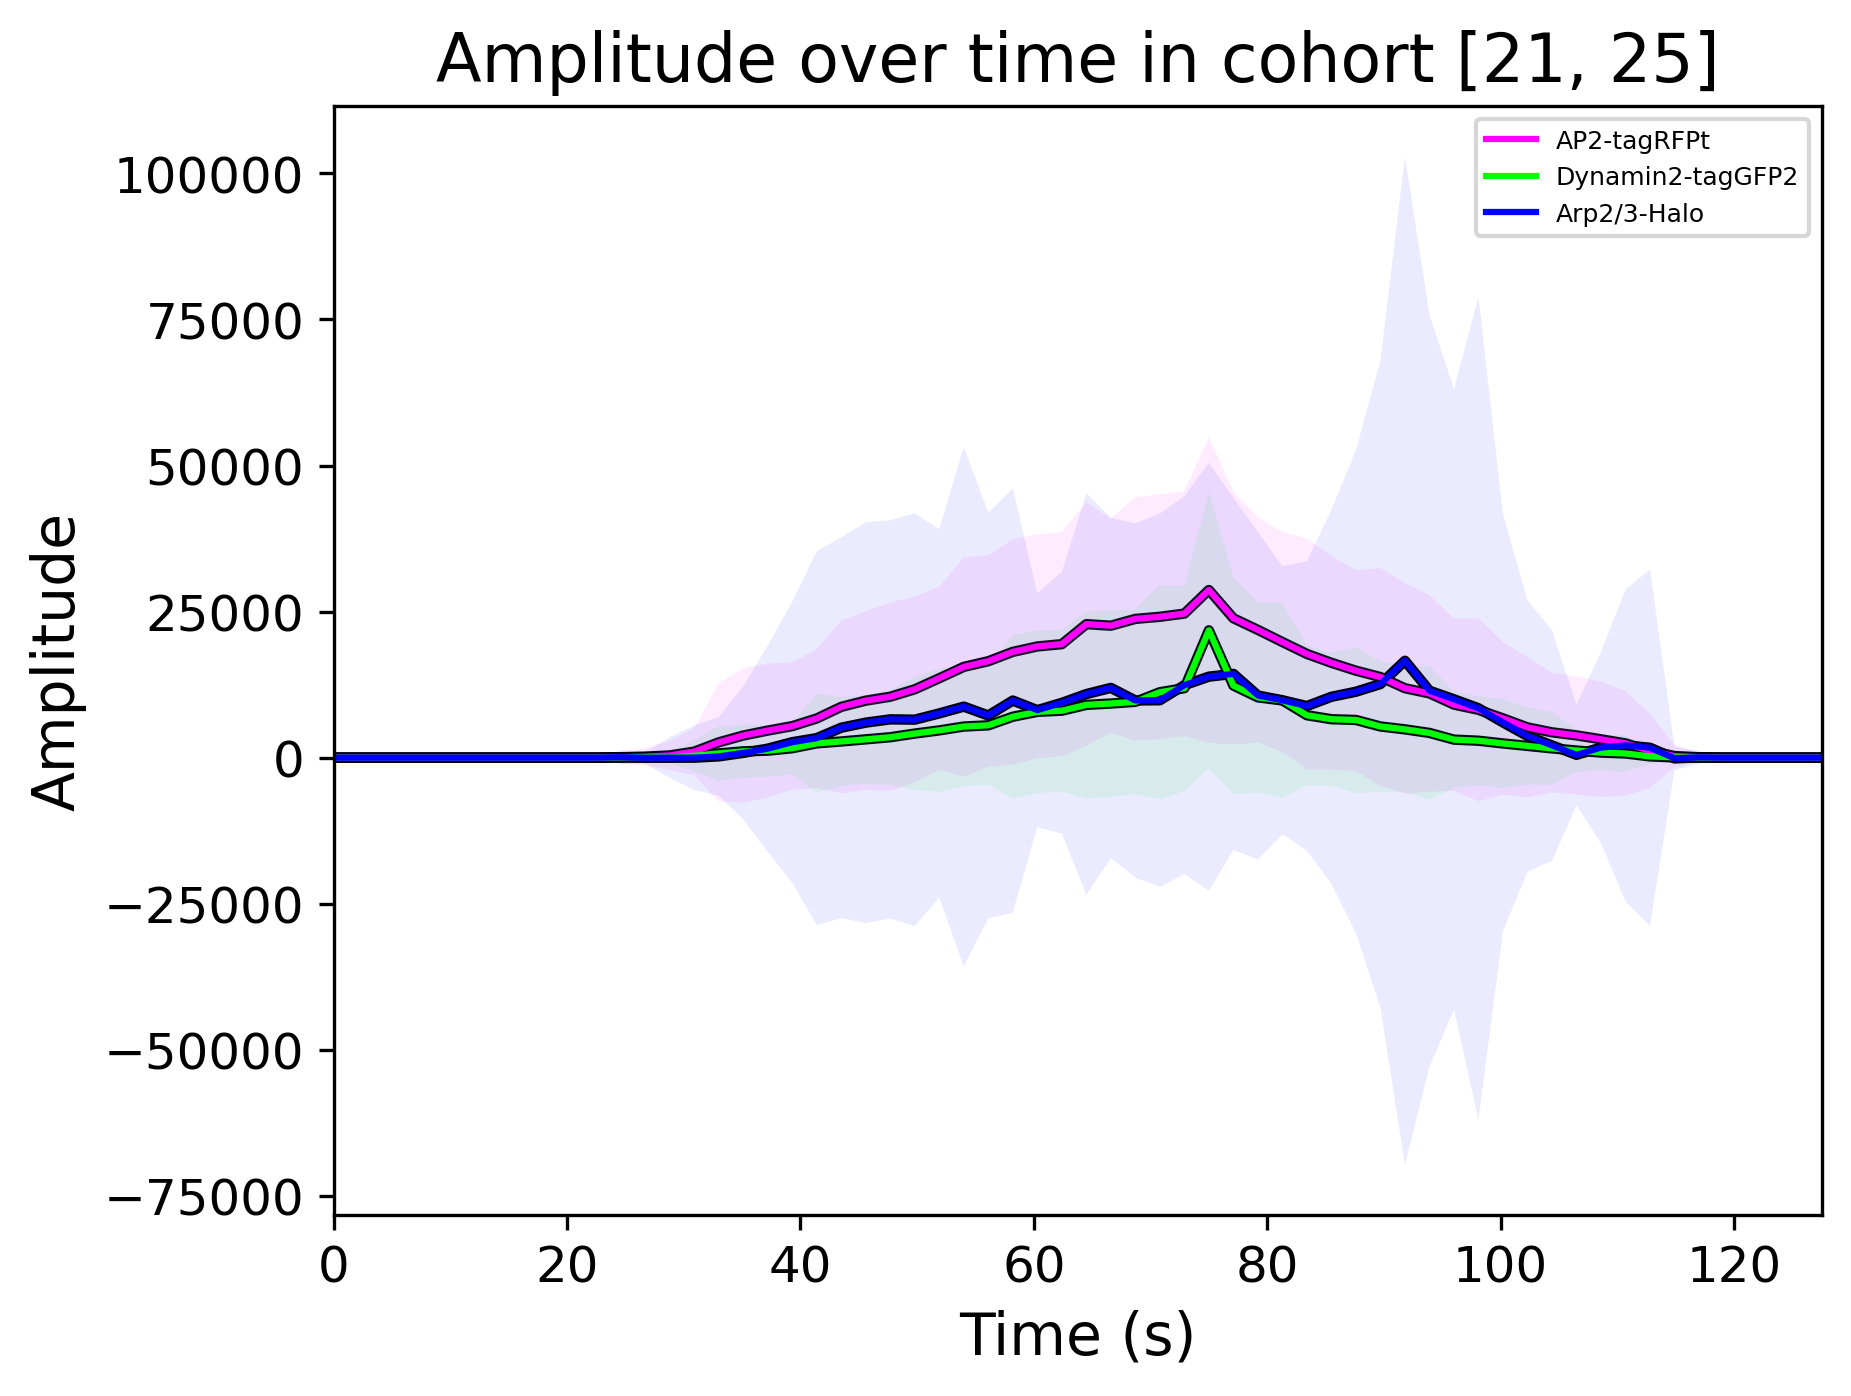

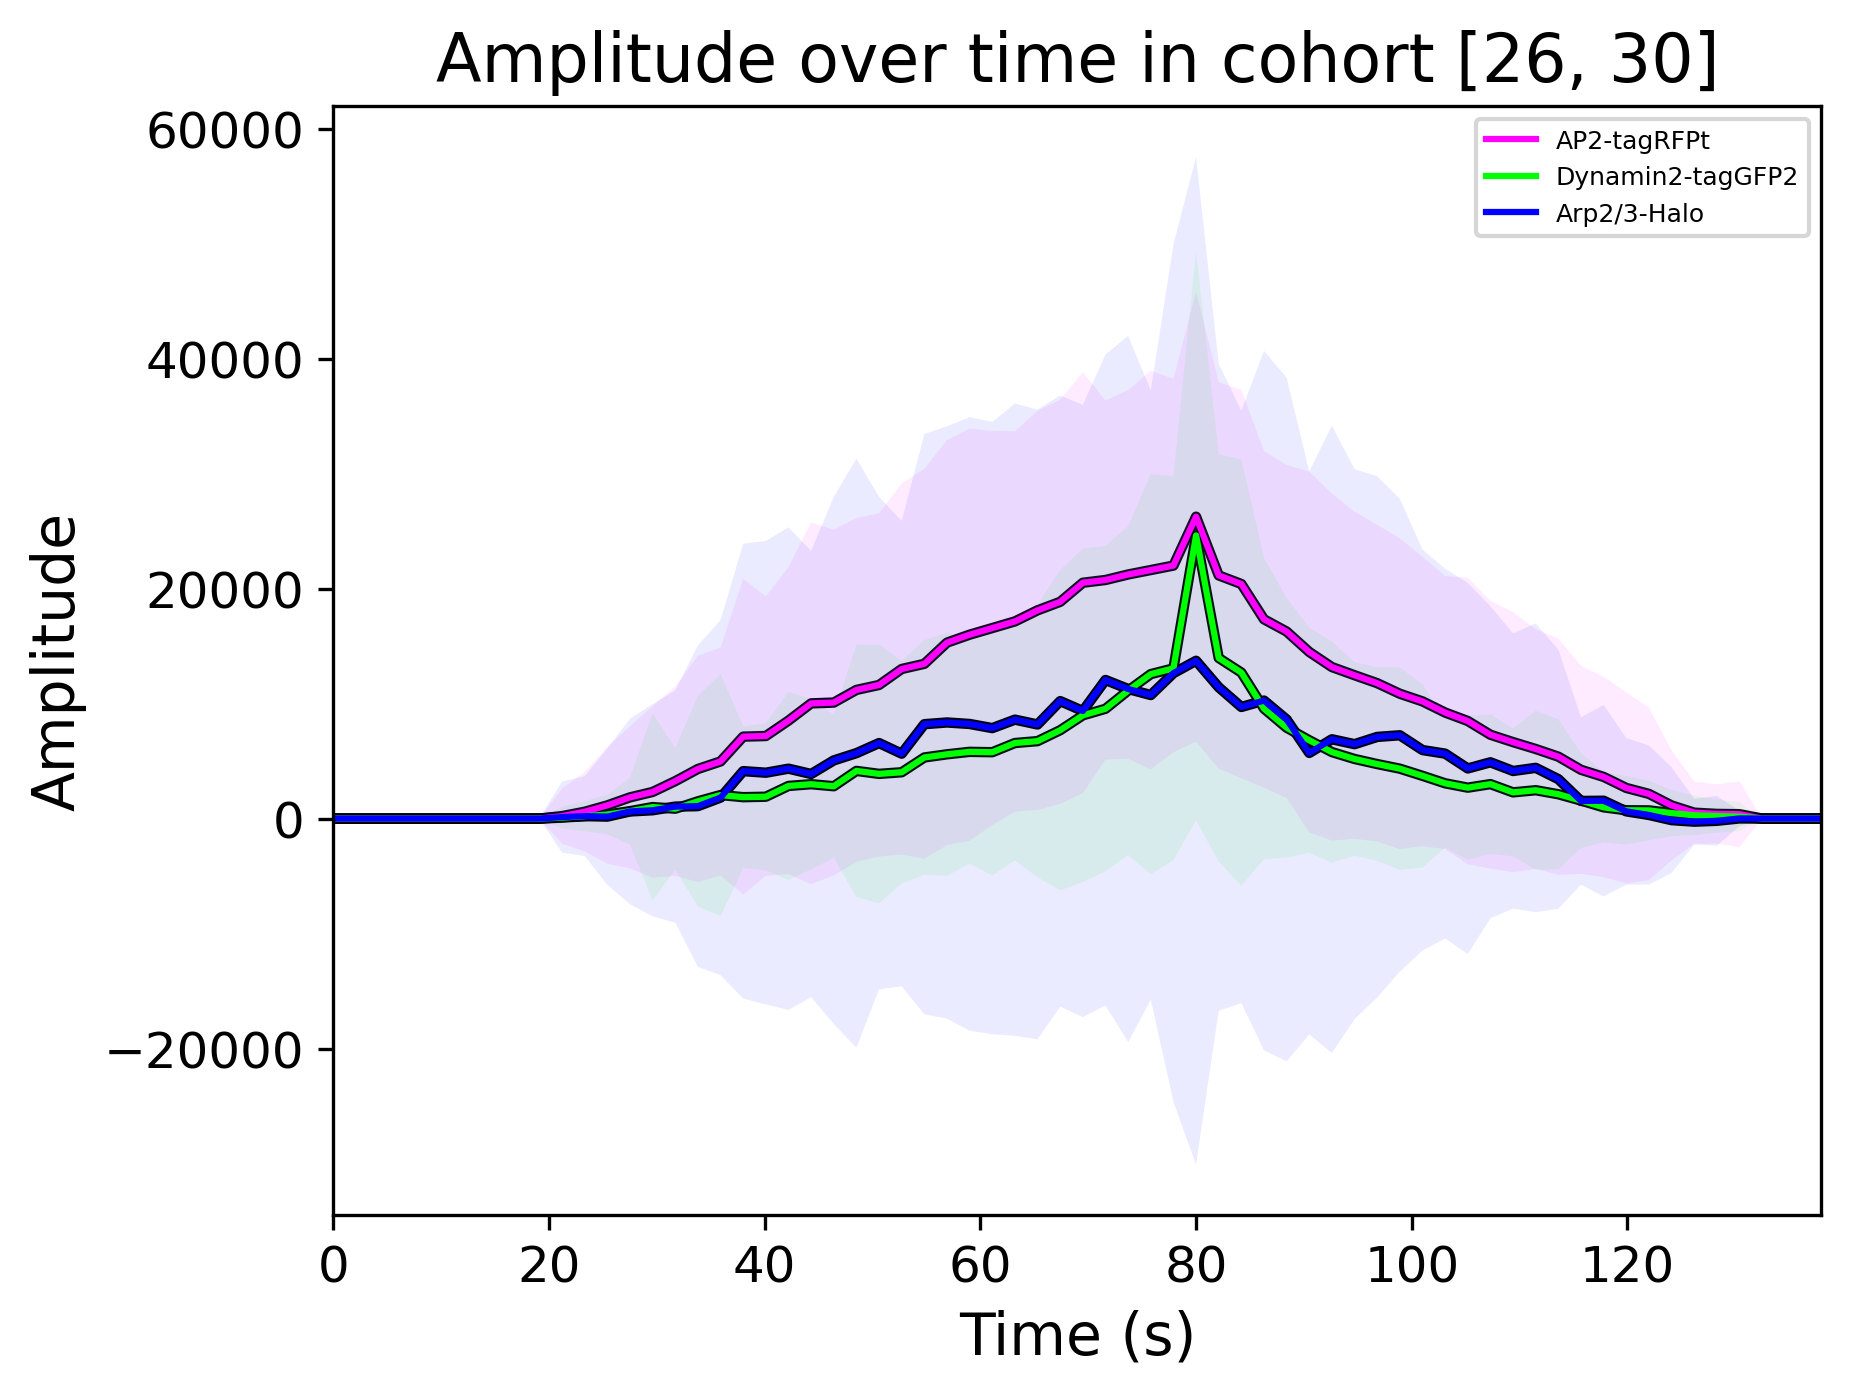

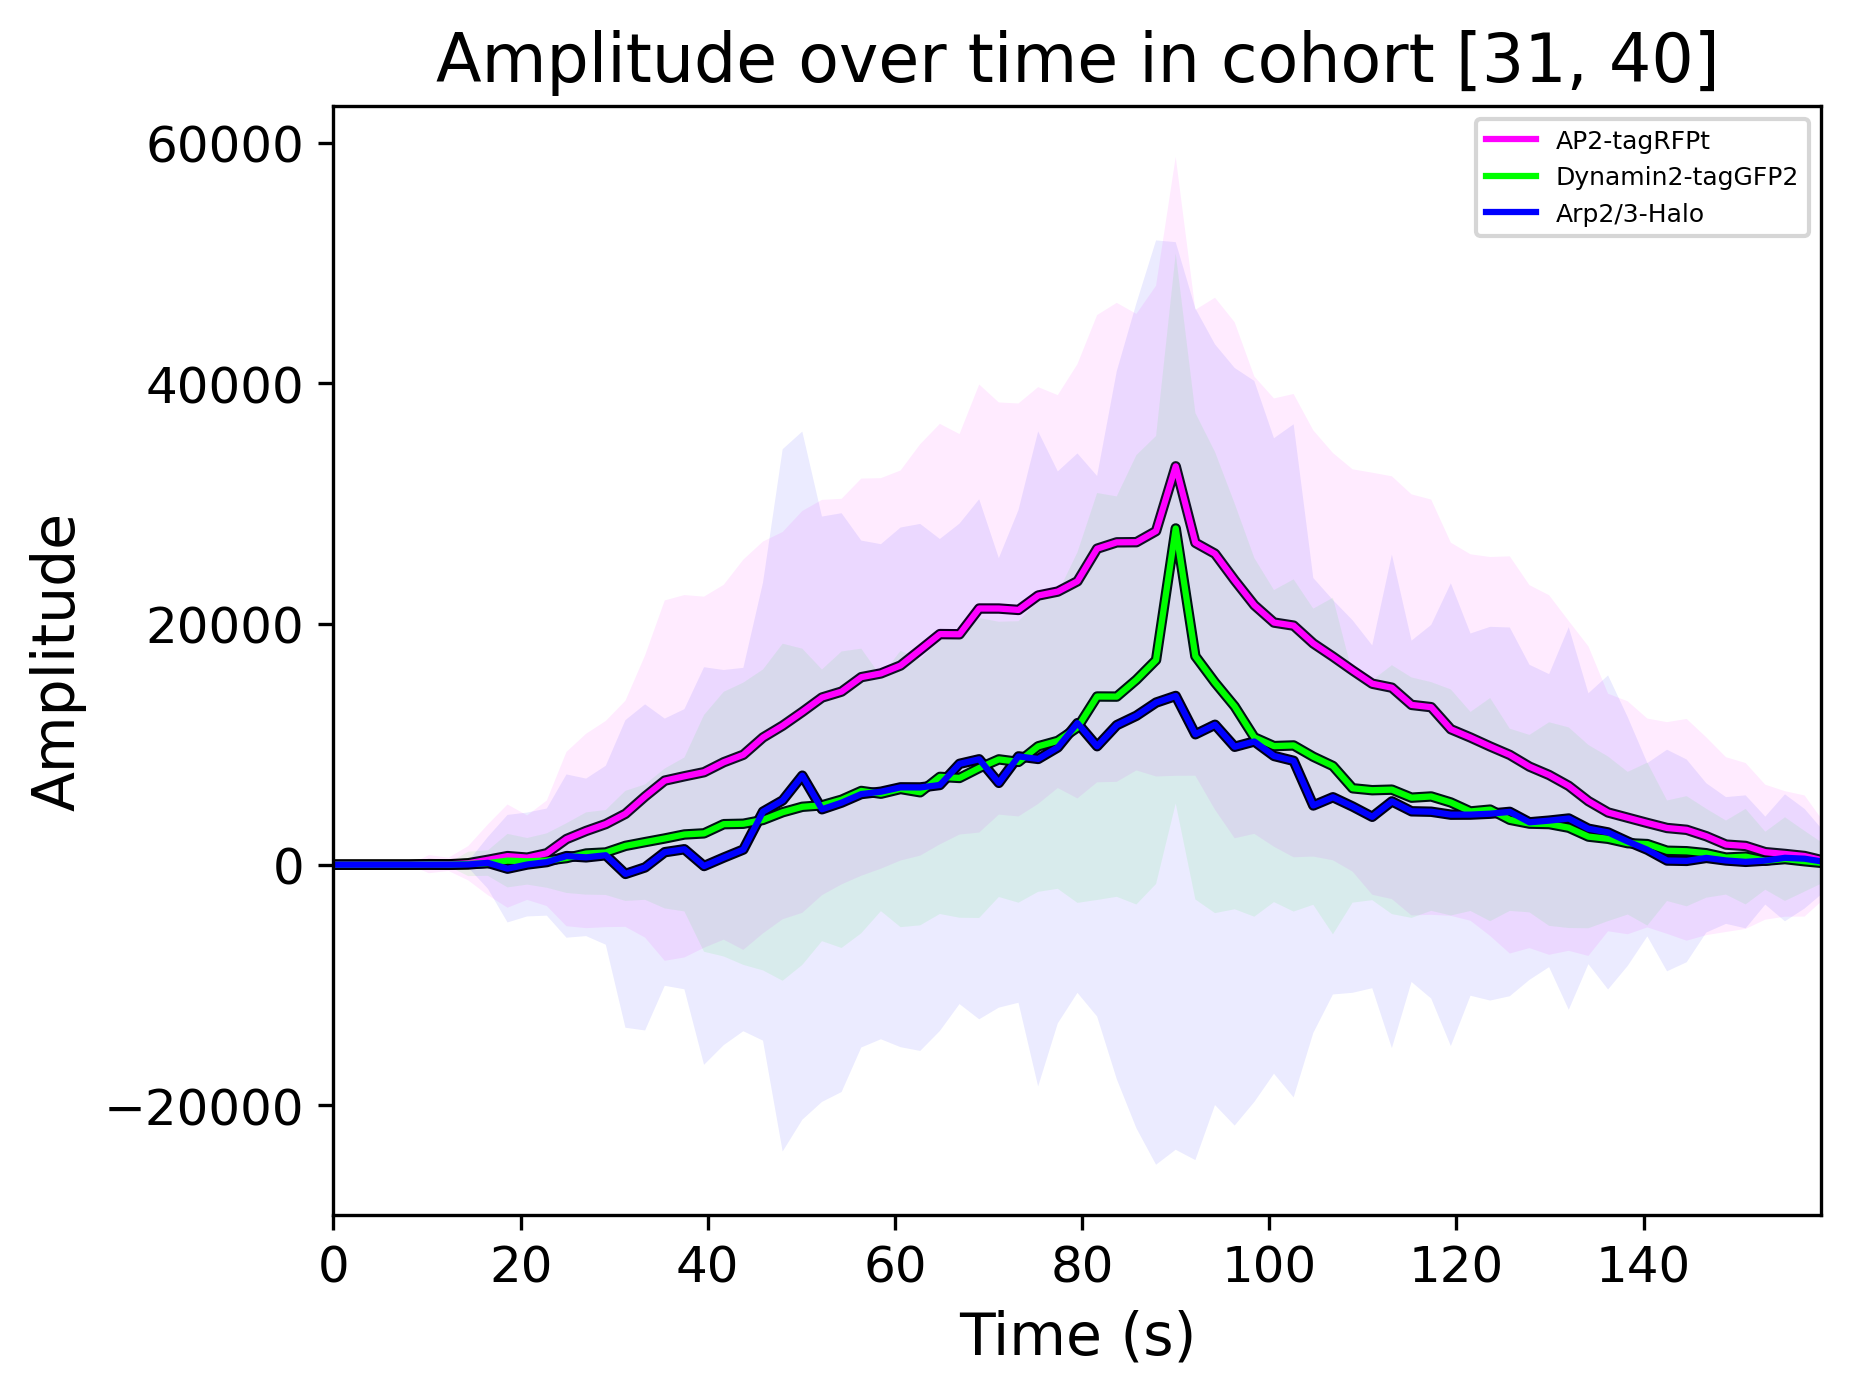

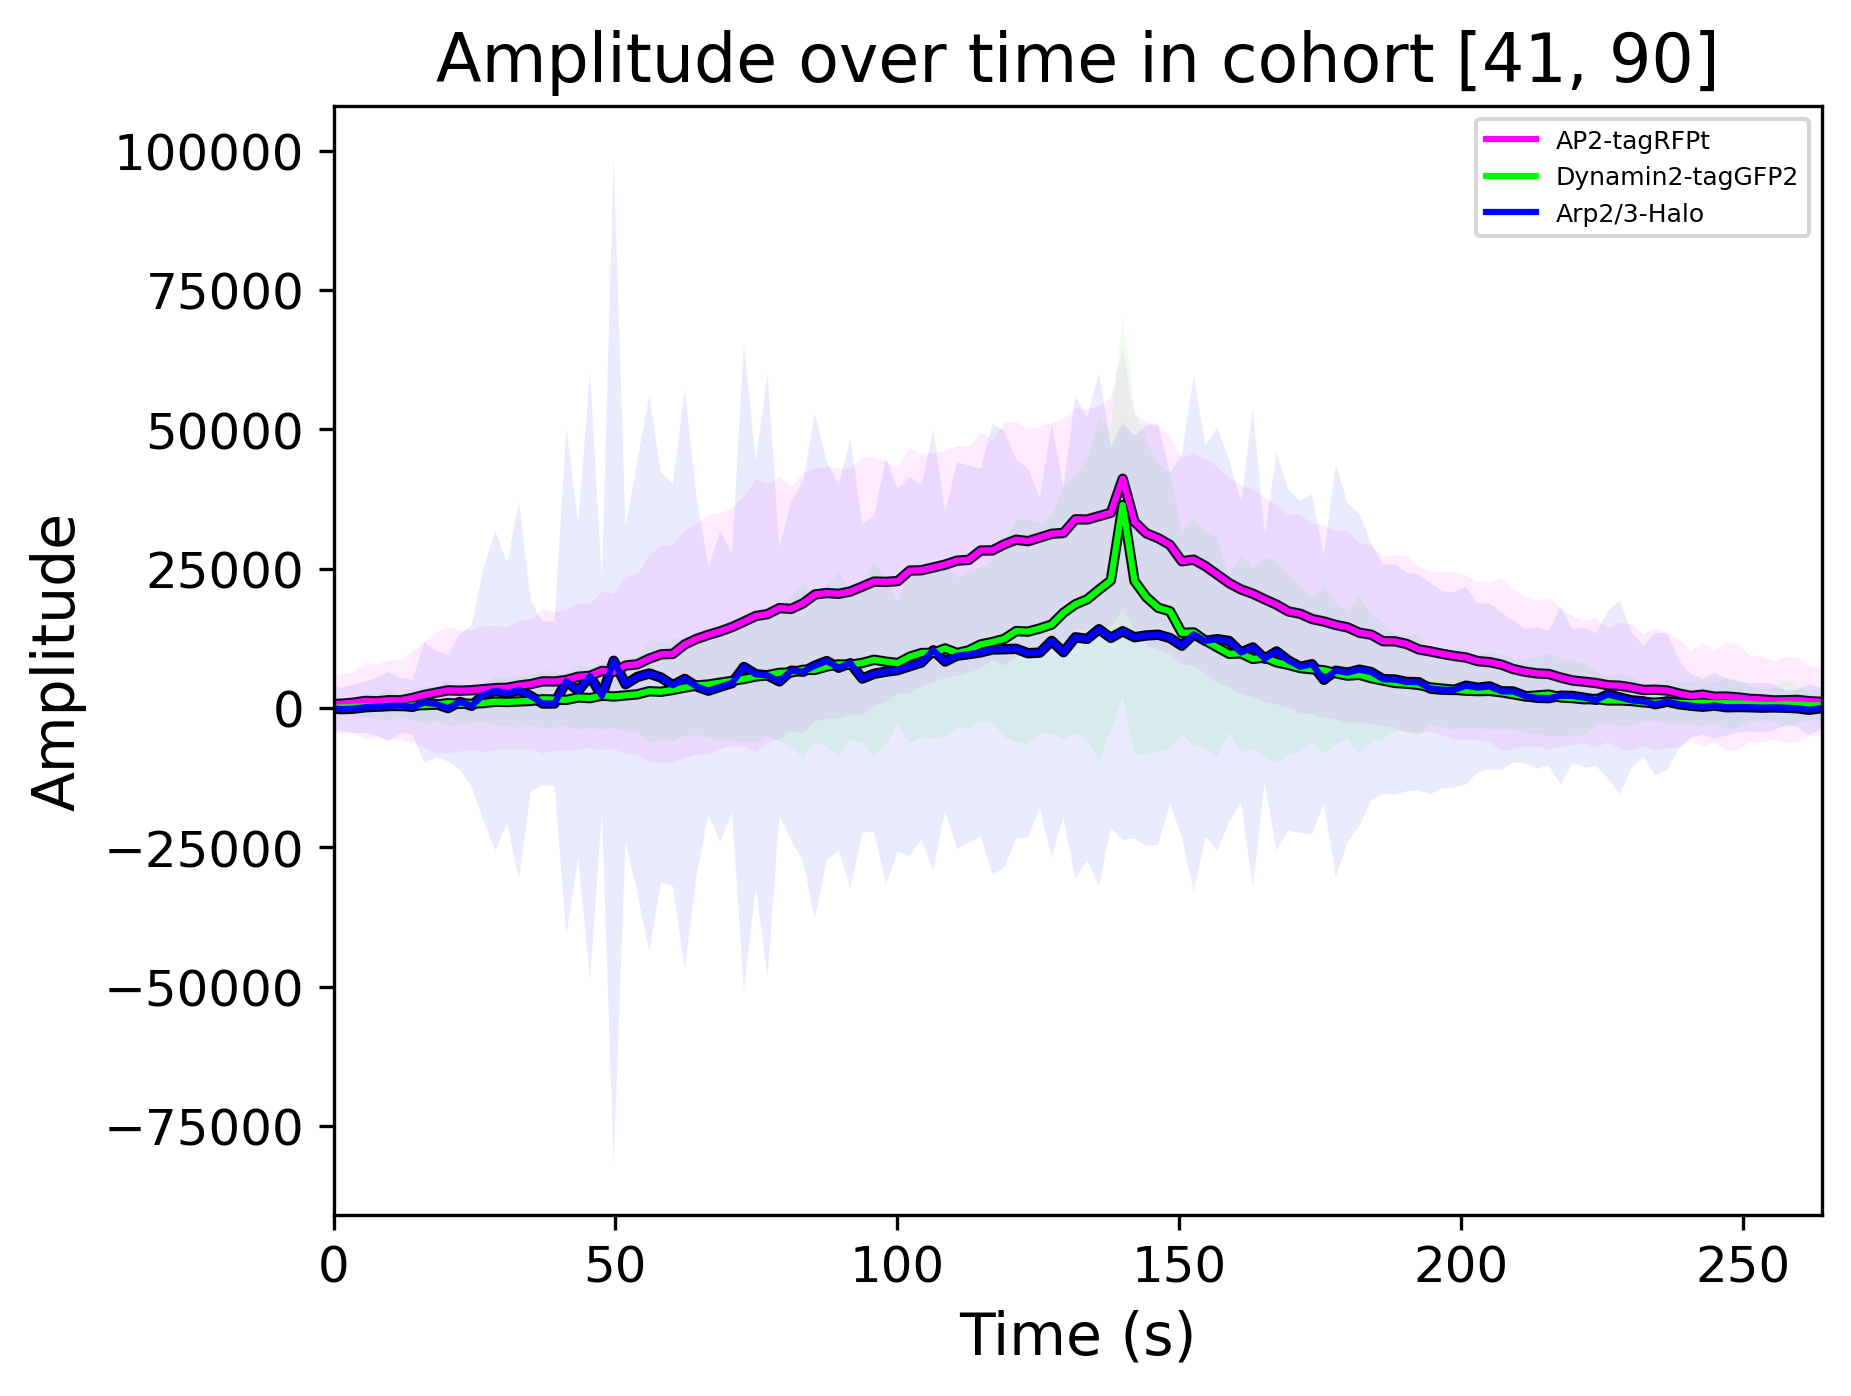

In [ ]:
lateral_tracks = trackFilter('Lateral', False, filtered_tracks_treatment)
track_id_arrays = filter_track_ids_by_length_ranges(dataframe = lateral_tracks, track_length_buckets = custom_length_ranges, 
                                 track_id_col_name = 'track_id', track_length_col_name = 'track_length')

print(f'number of tracks between [5,10] frames long are {len(track_id_arrays[0])}')
print(f'number of tracks between [11,15] frames long are {len(track_id_arrays[1])}')
print(f'number of tracks between [16,20] frames long are {len(track_id_arrays[2])}')
print(f'number of tracks between [21,25] frames long are {len(track_id_arrays[3])}')
print(f'number of tracks between [26,30] frames long are {len(track_id_arrays[4])}')
print(f'number of tracks between [31,40] frames long are {len(track_id_arrays[5])}')
print(f'number of tracks between [41,90] frames long are {len(track_id_arrays[6])}')
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0
    
cohort_intensity(intensity_track,track_id_arrays, lumenoid2_frame_ms, [background_channel_3, background_channel_2, background_channel_1], value_to_plot=value_to_plot)


#### Basal Intensity

number of tracks between [5,10] frames long are 83
number of tracks between [11,15] frames long are 126
number of tracks between [16,20] frames long are 101
number of tracks between [21,25] frames long are 82
number of tracks between [26,30] frames long are 60
number of tracks between [31,40] frames long are 98
number of tracks between [41,90] frames long are 100


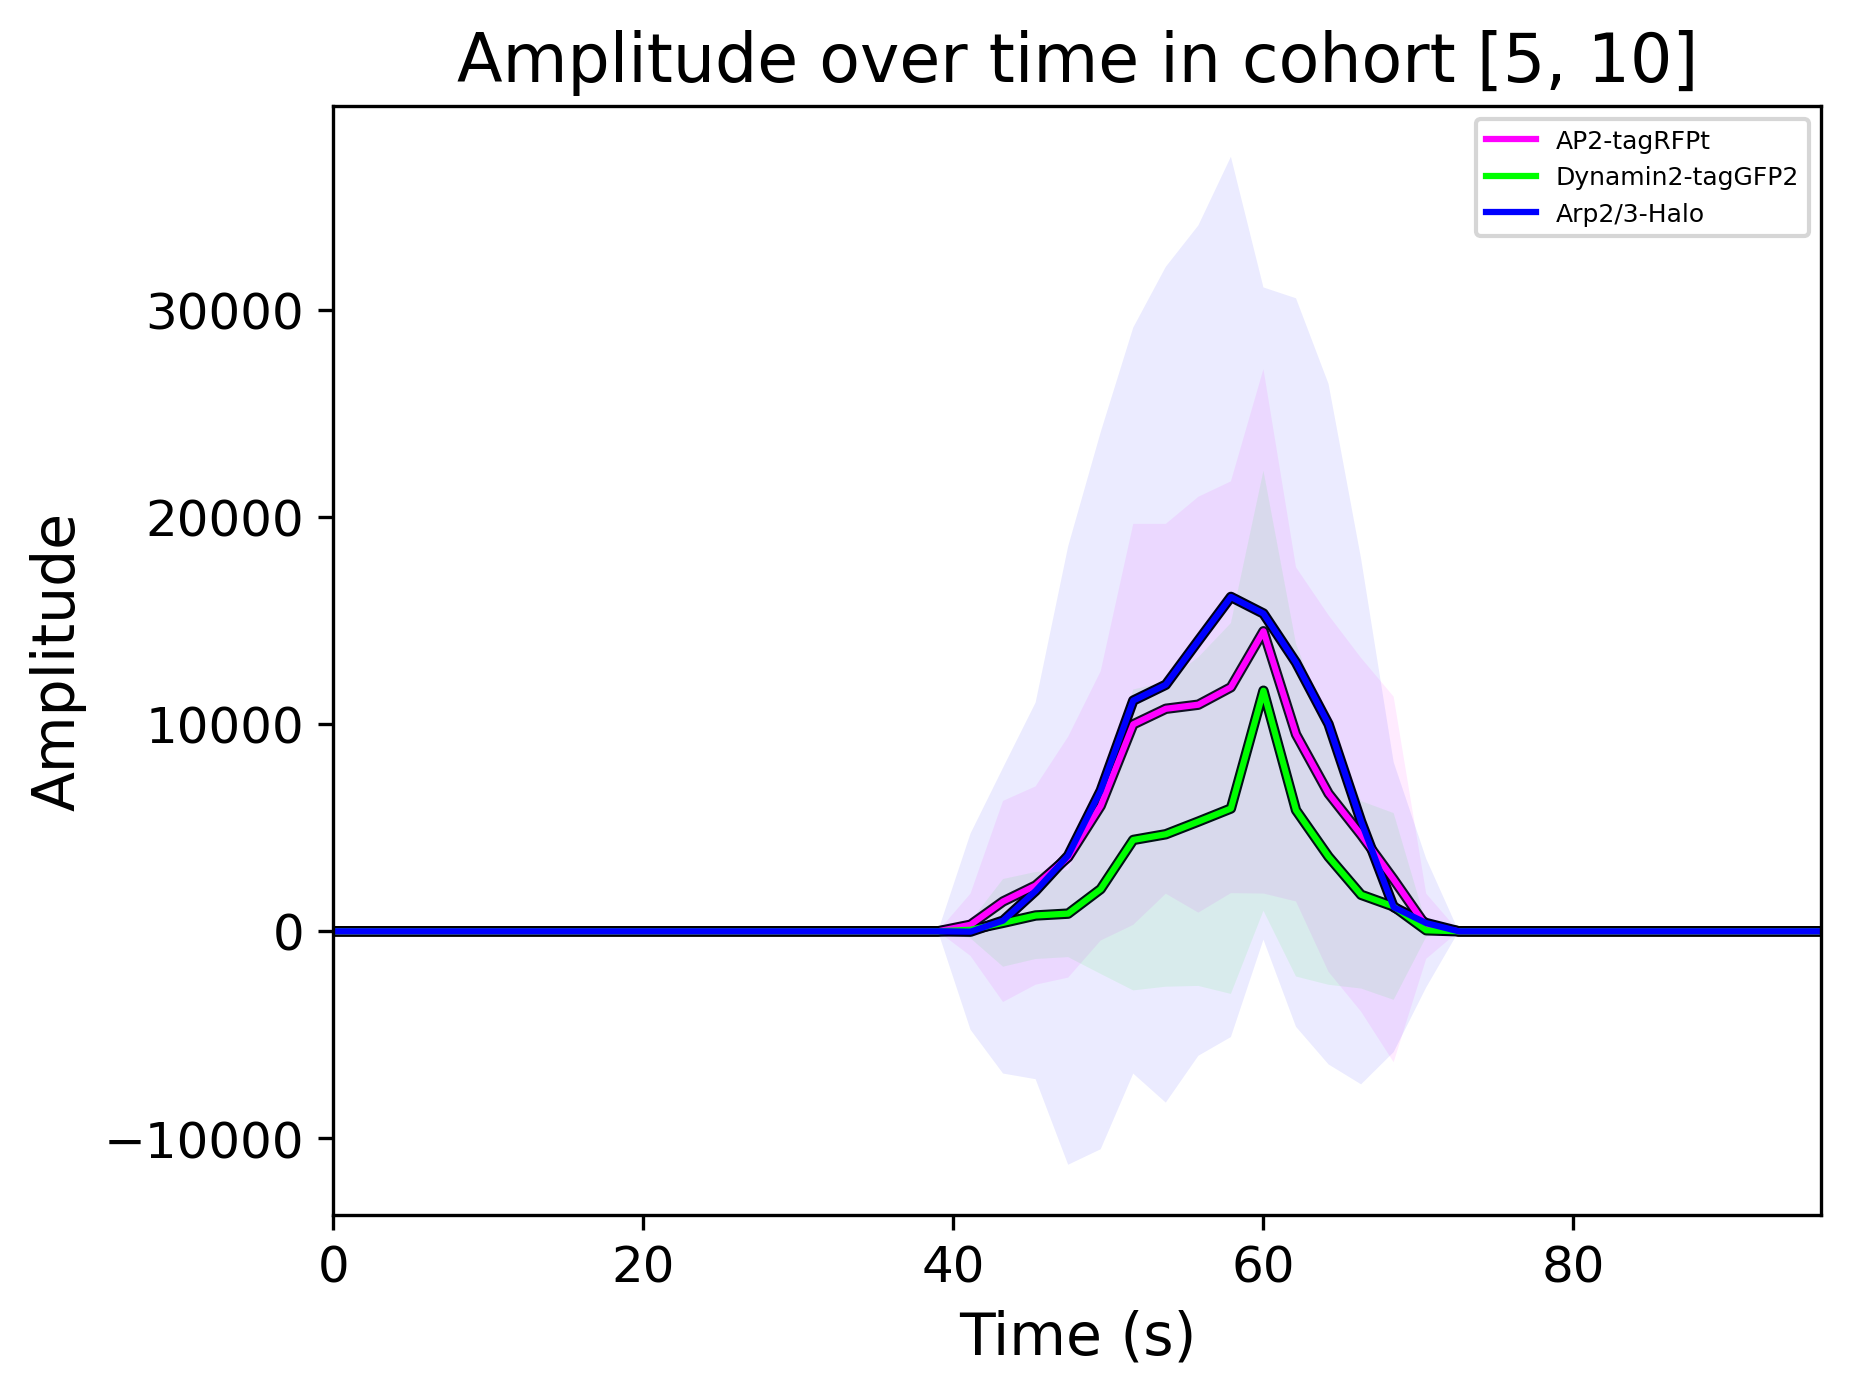

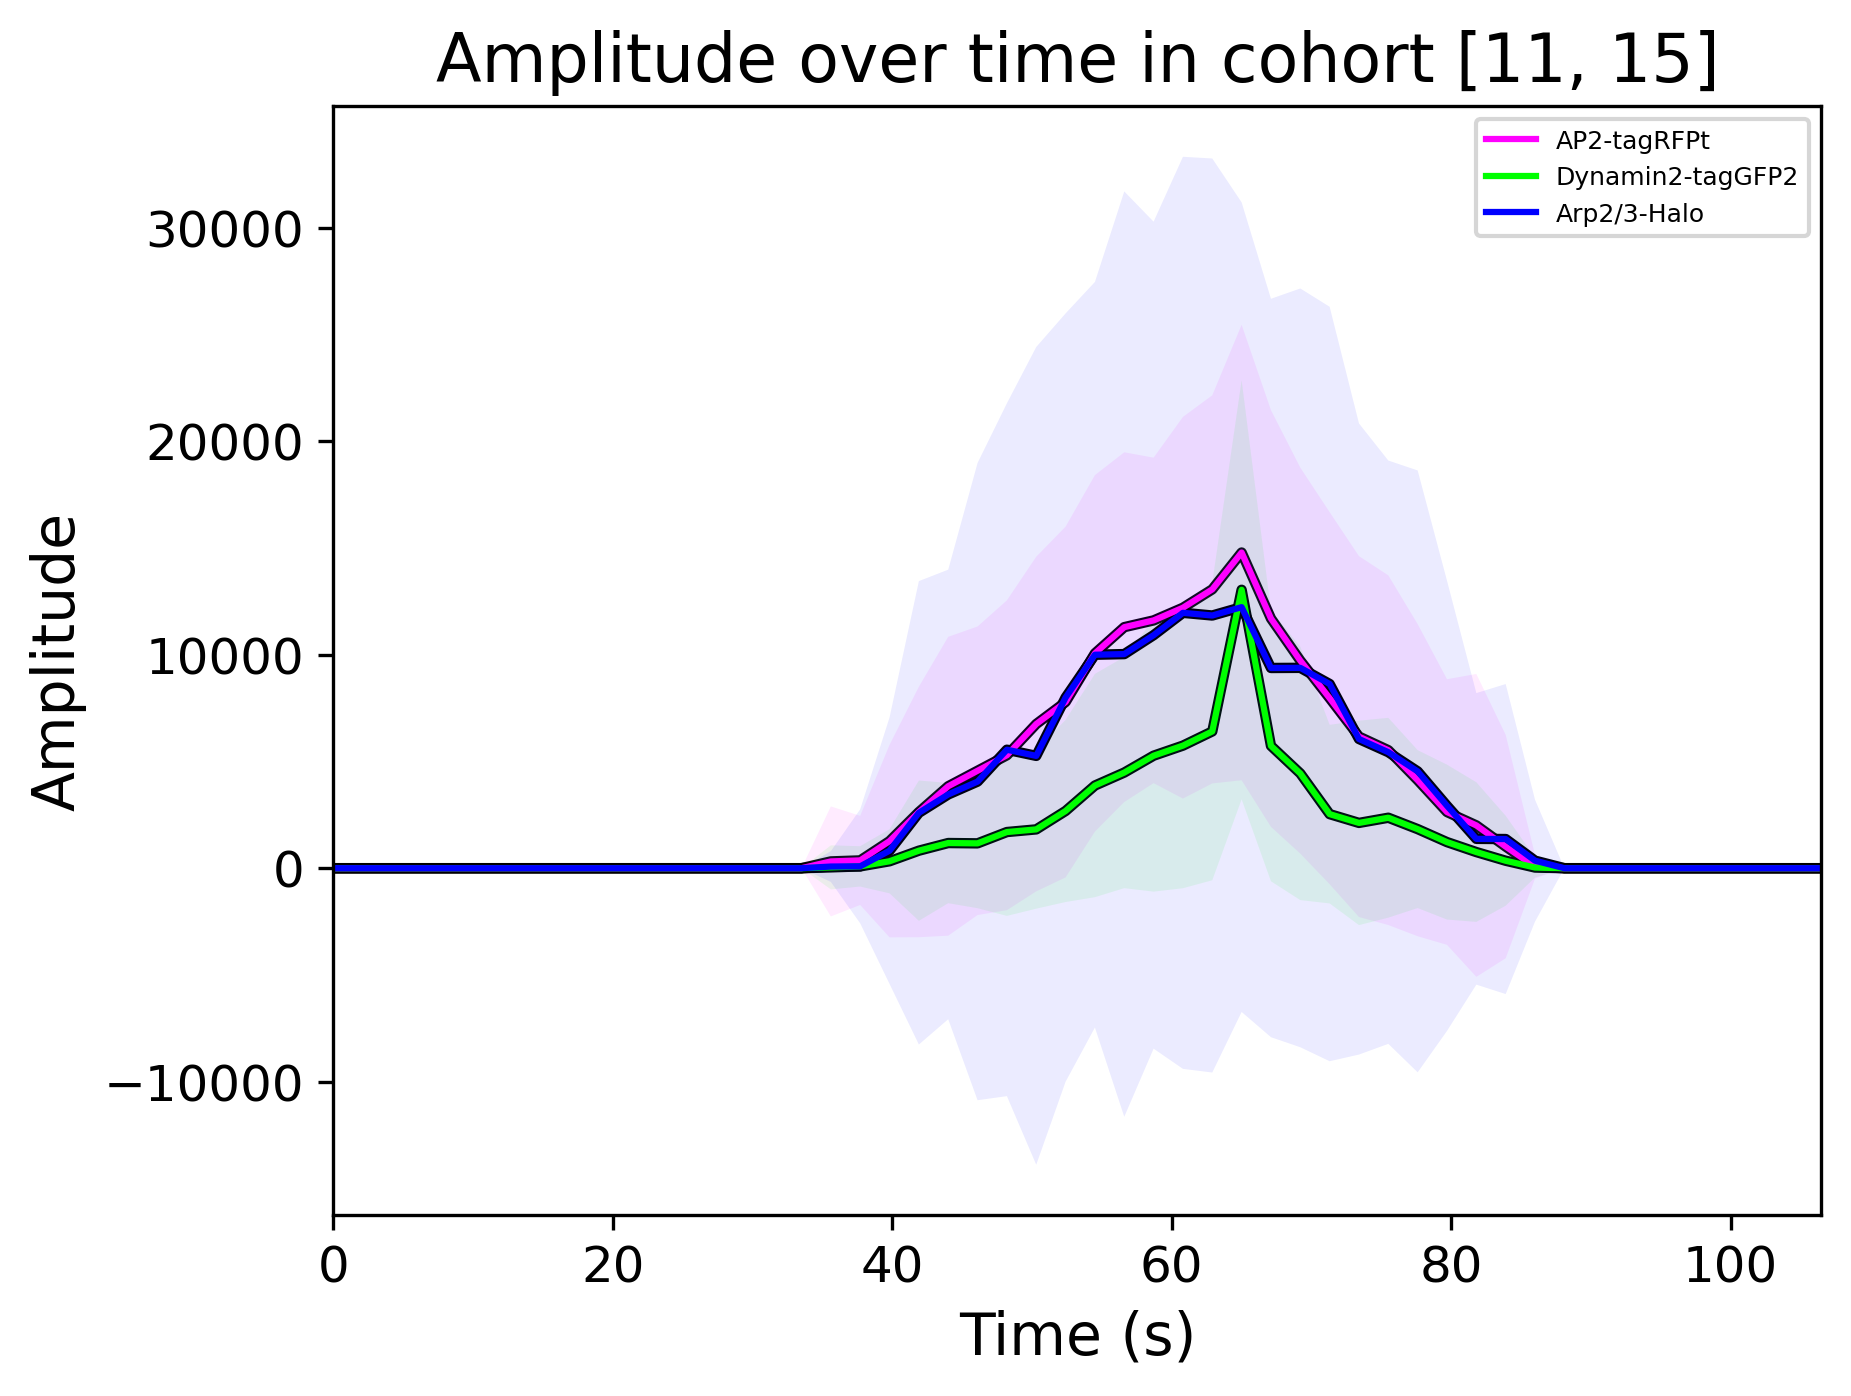

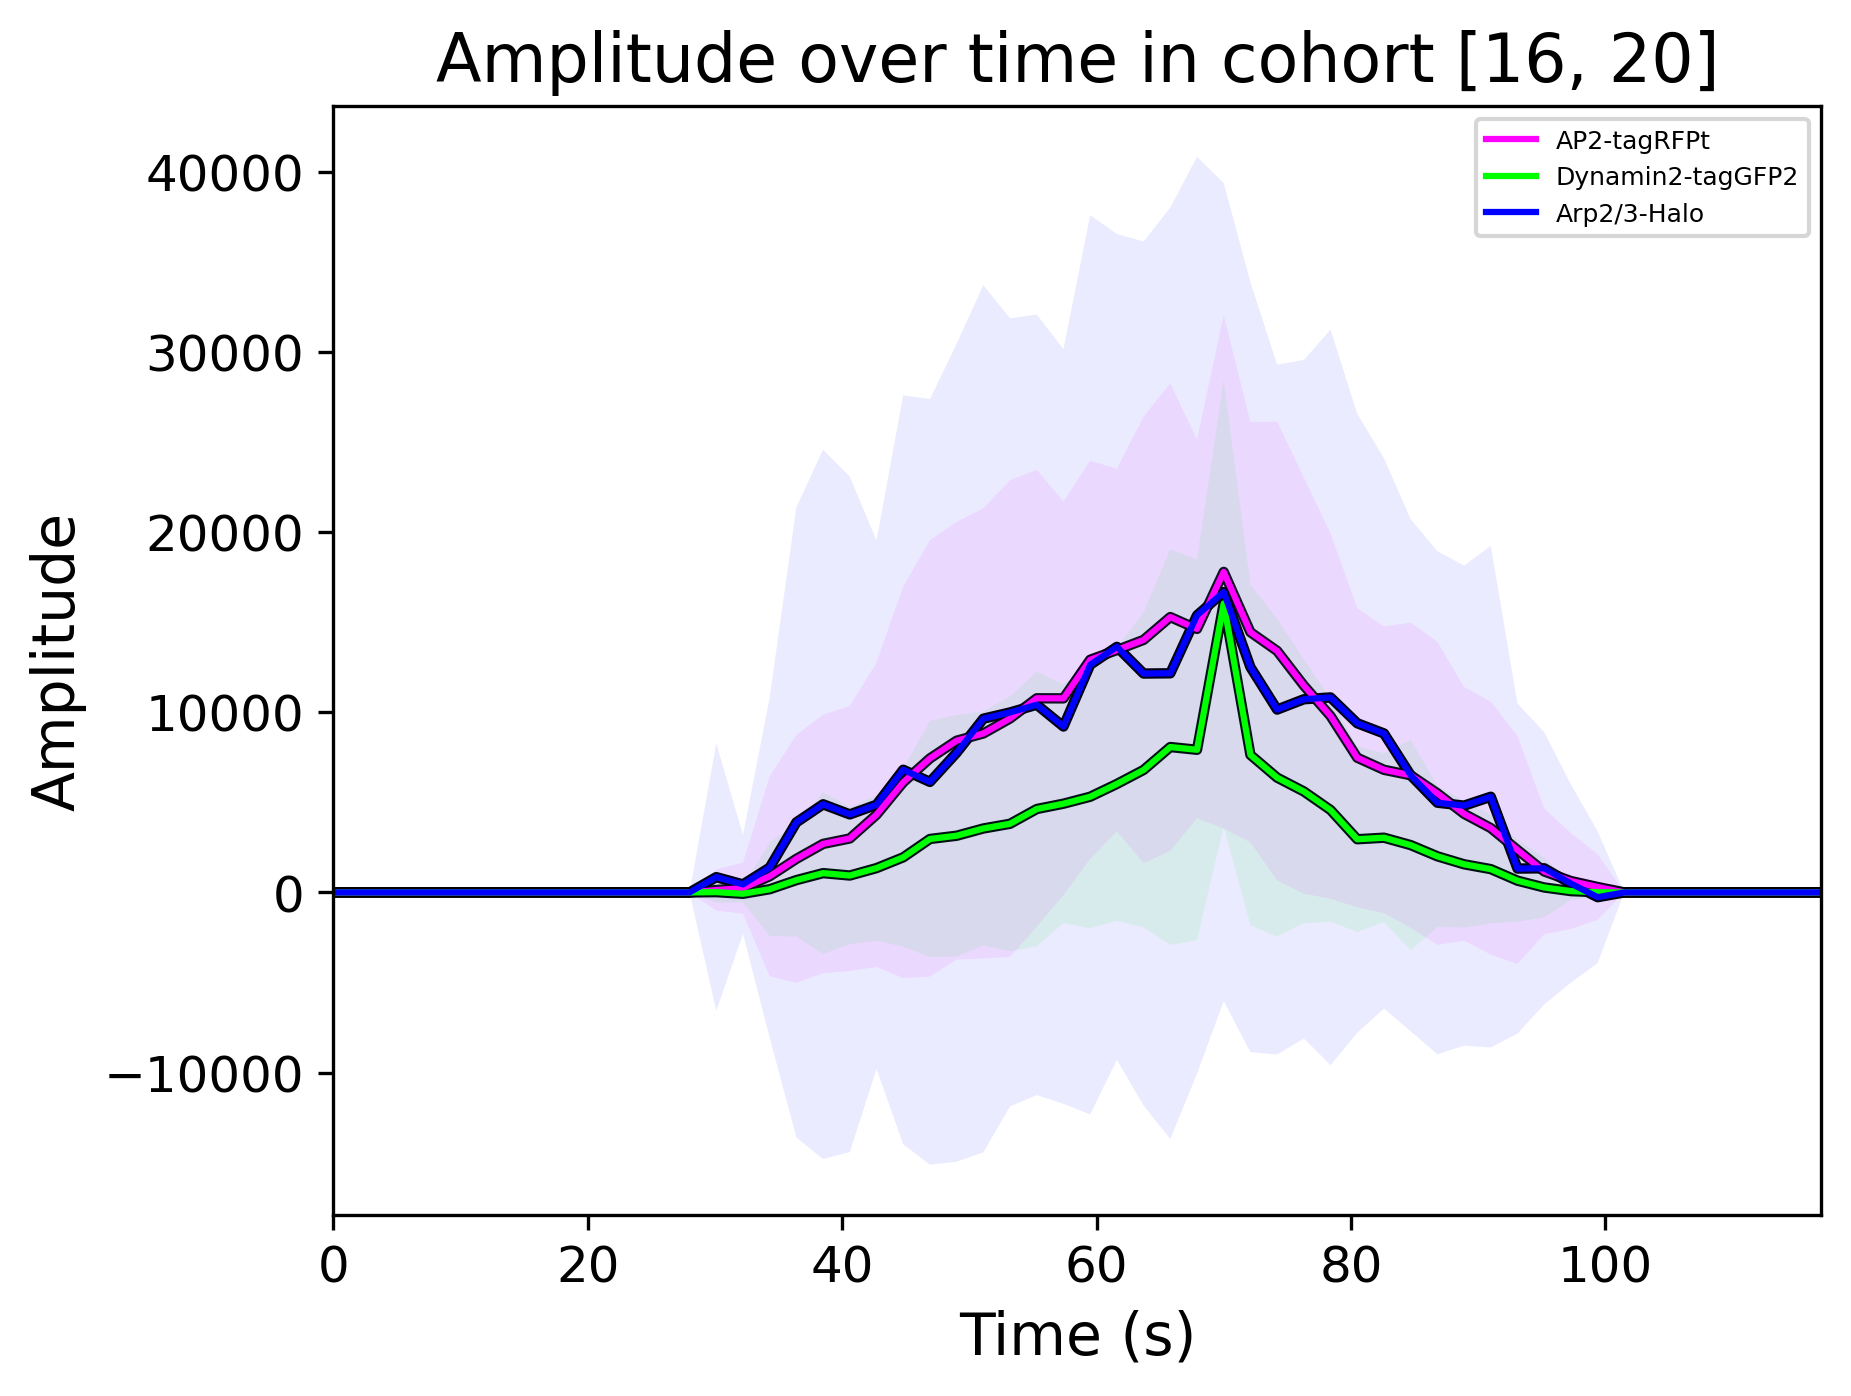

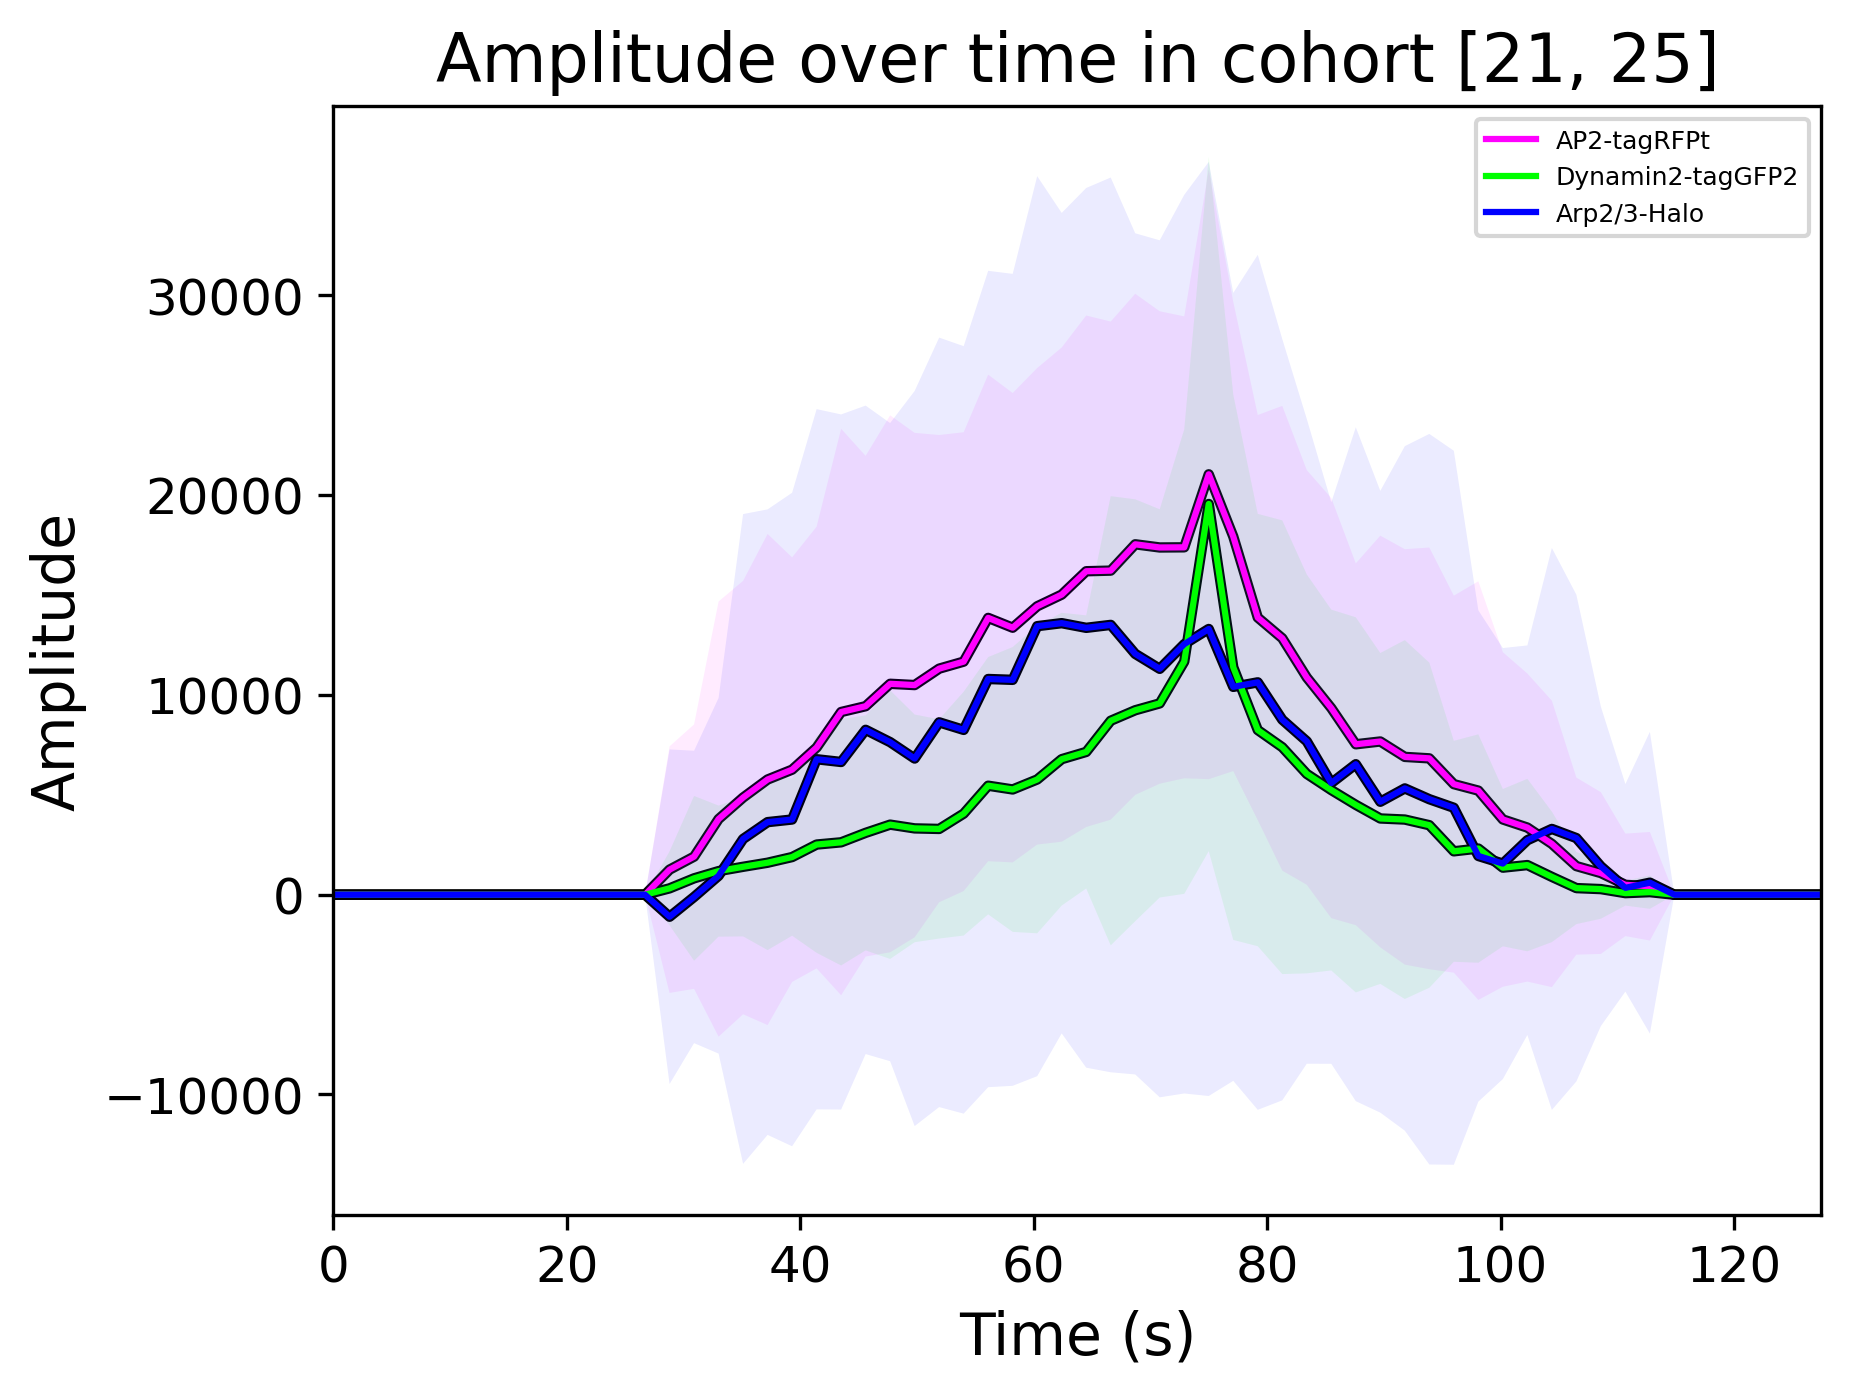

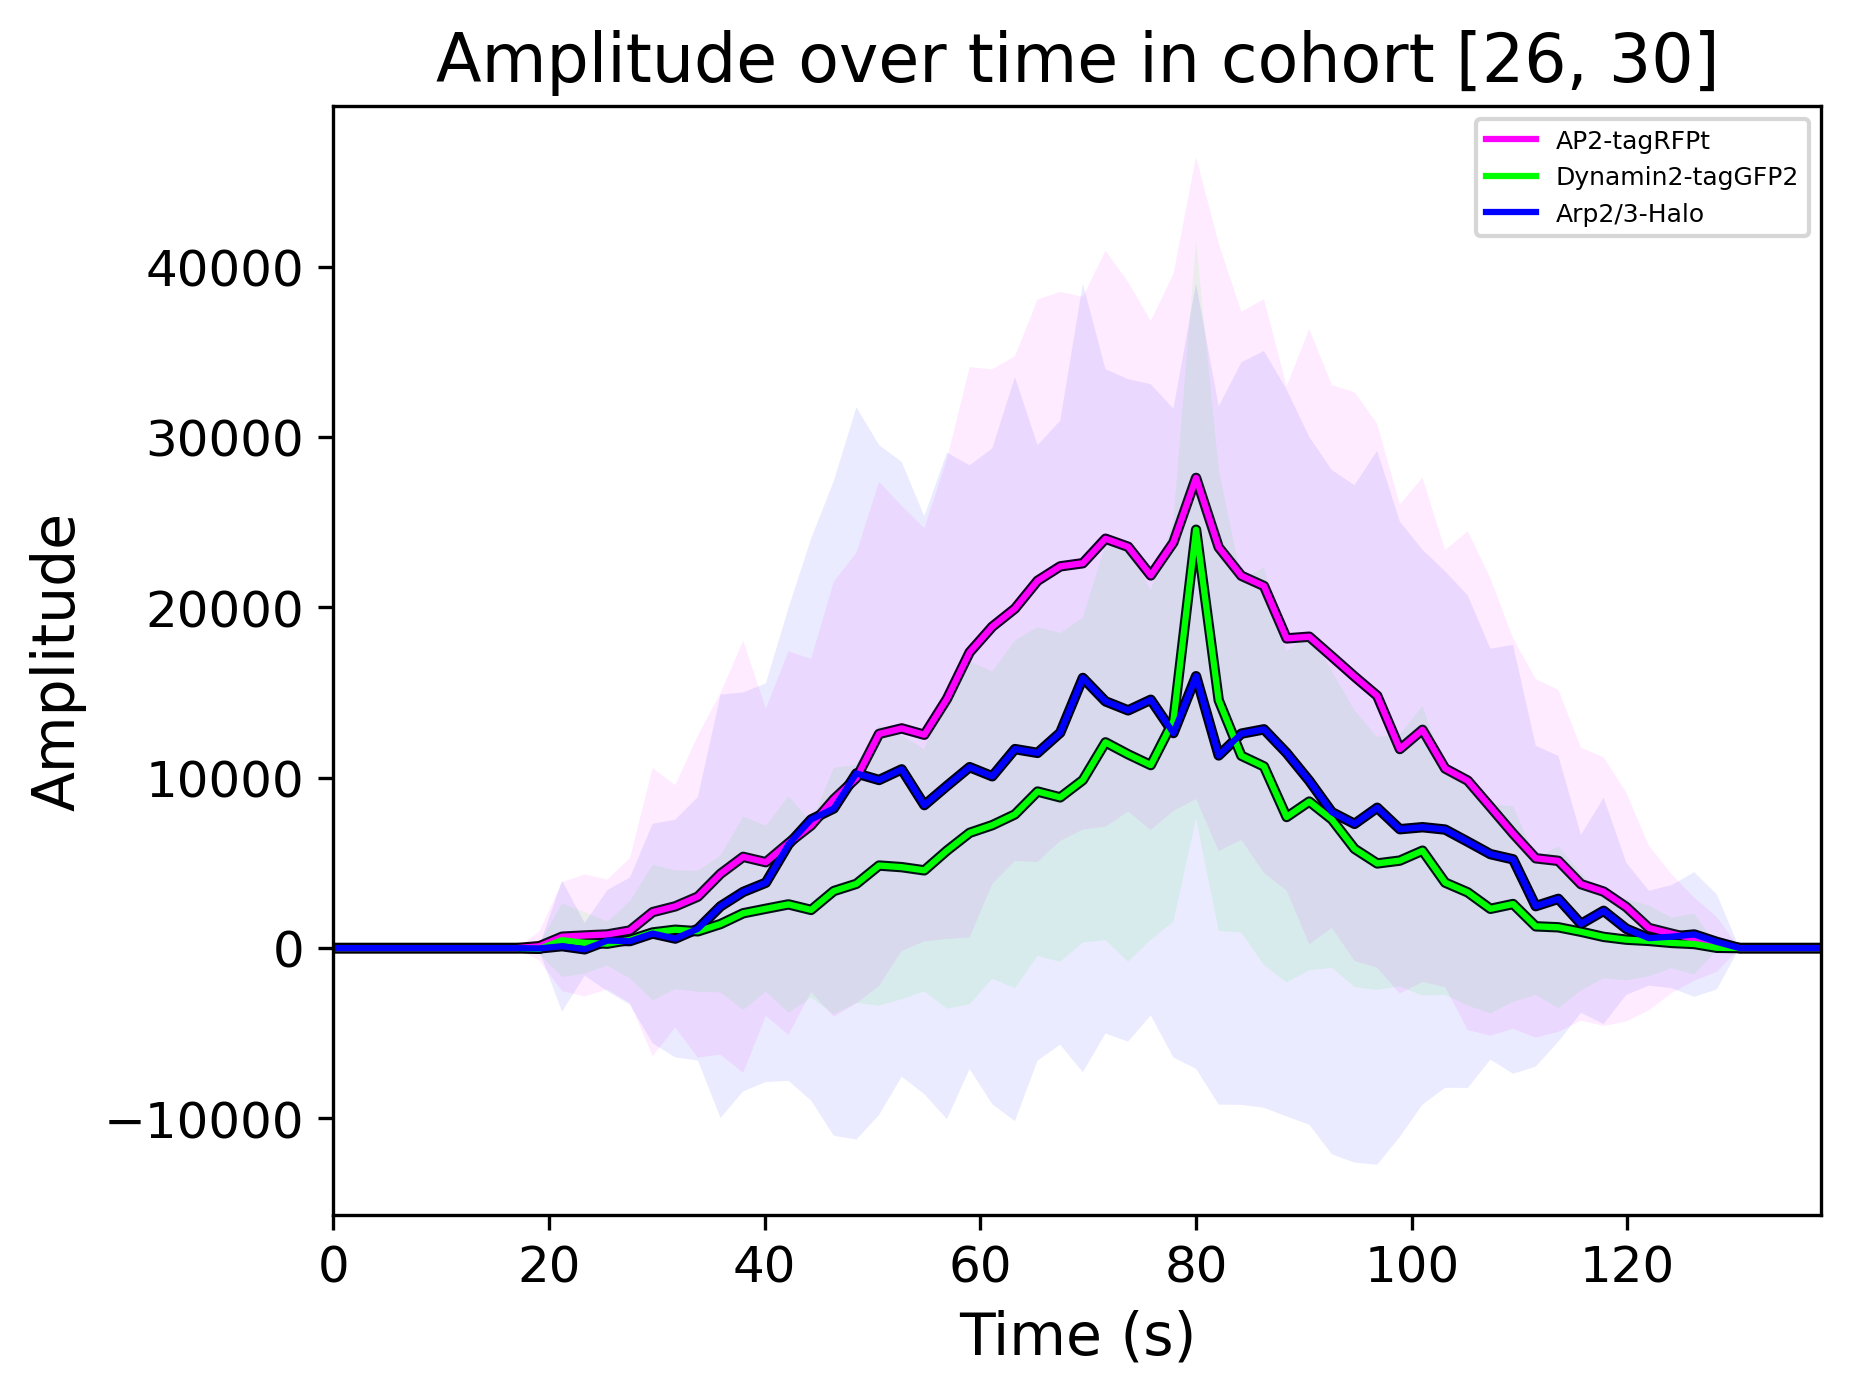

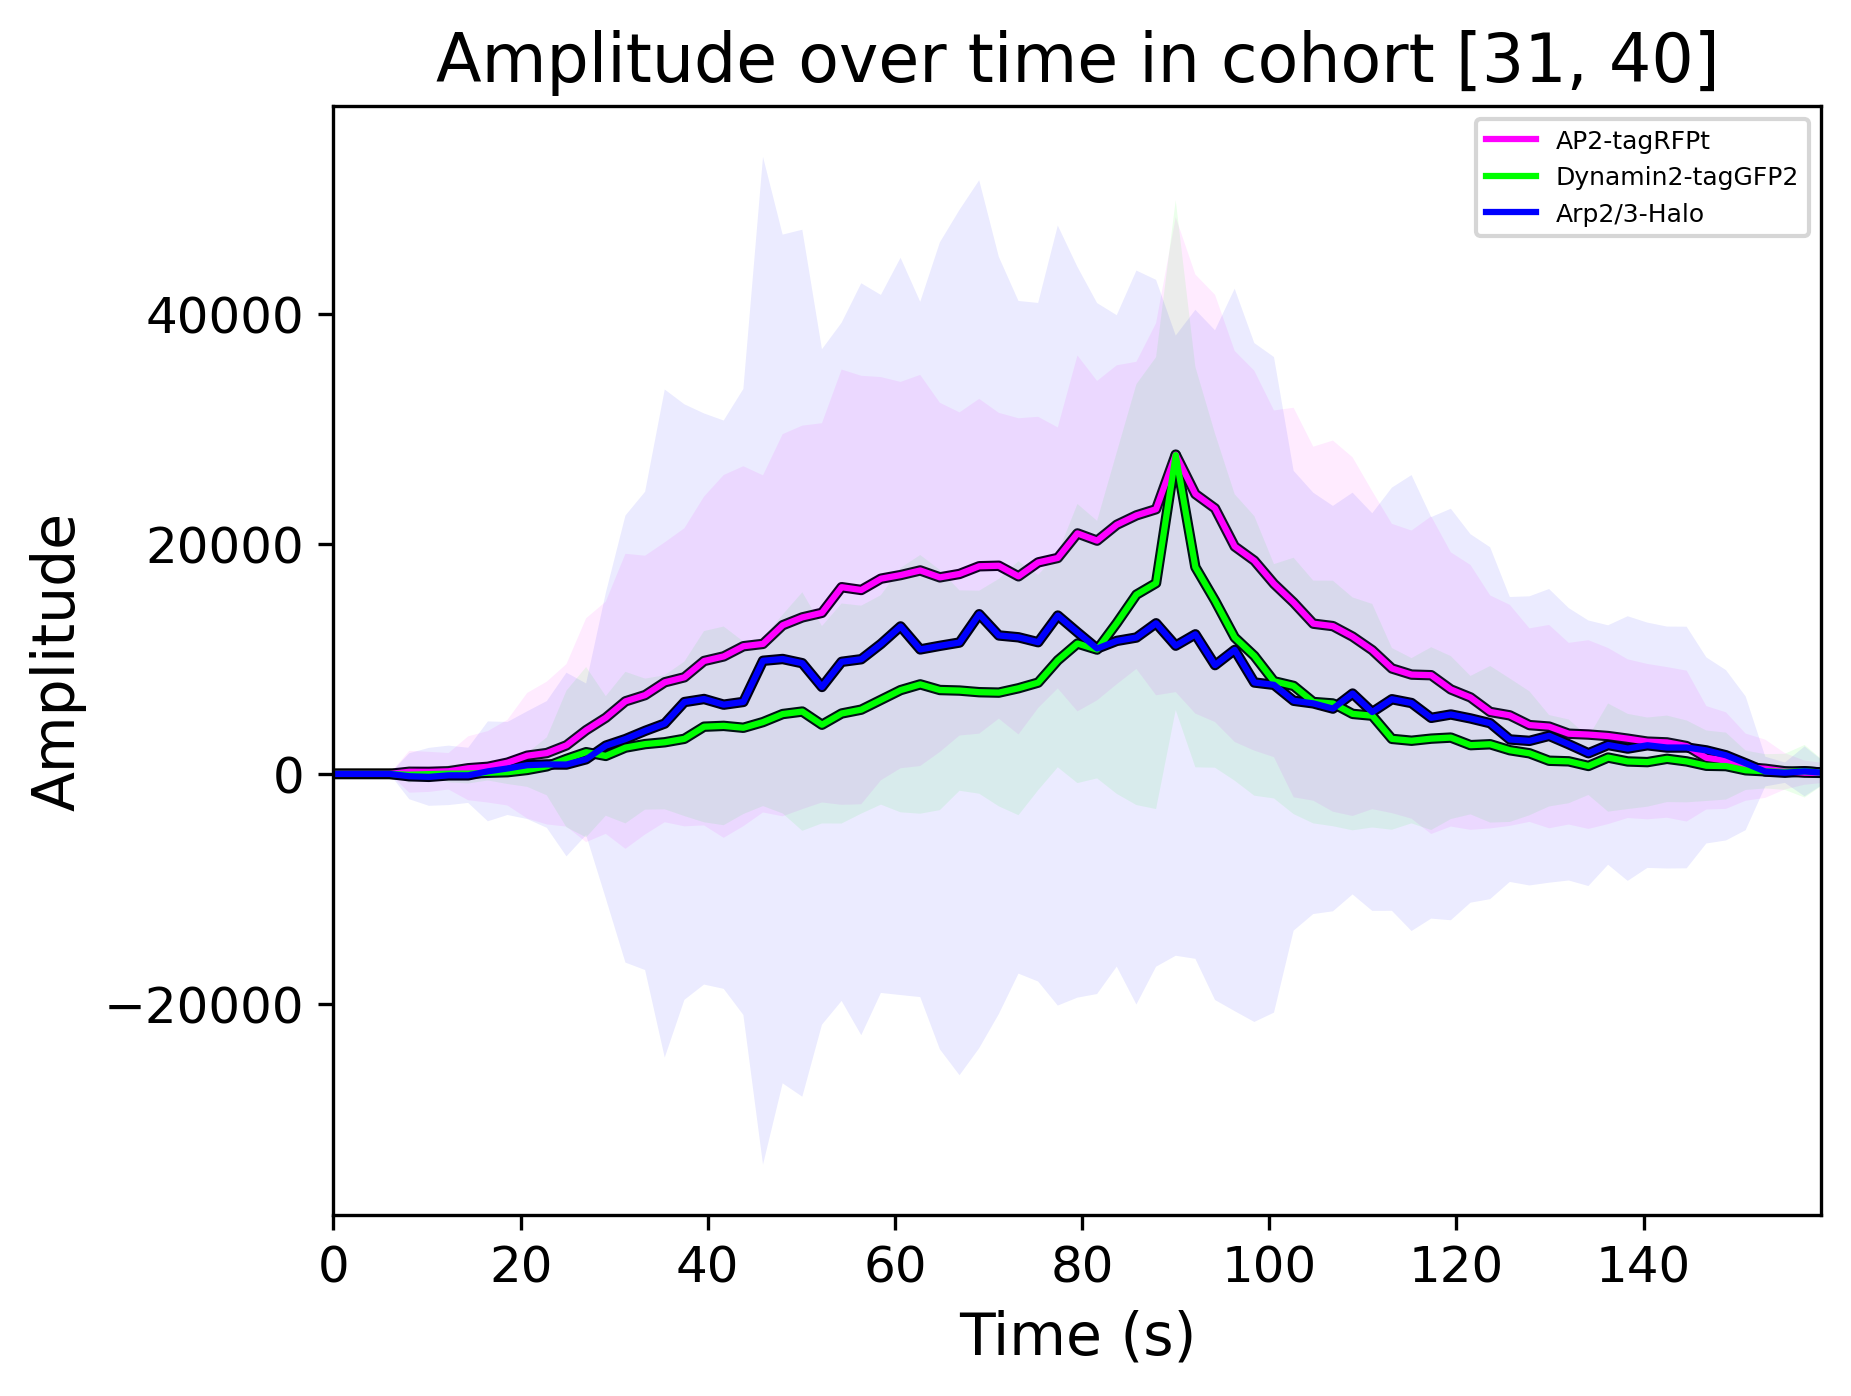

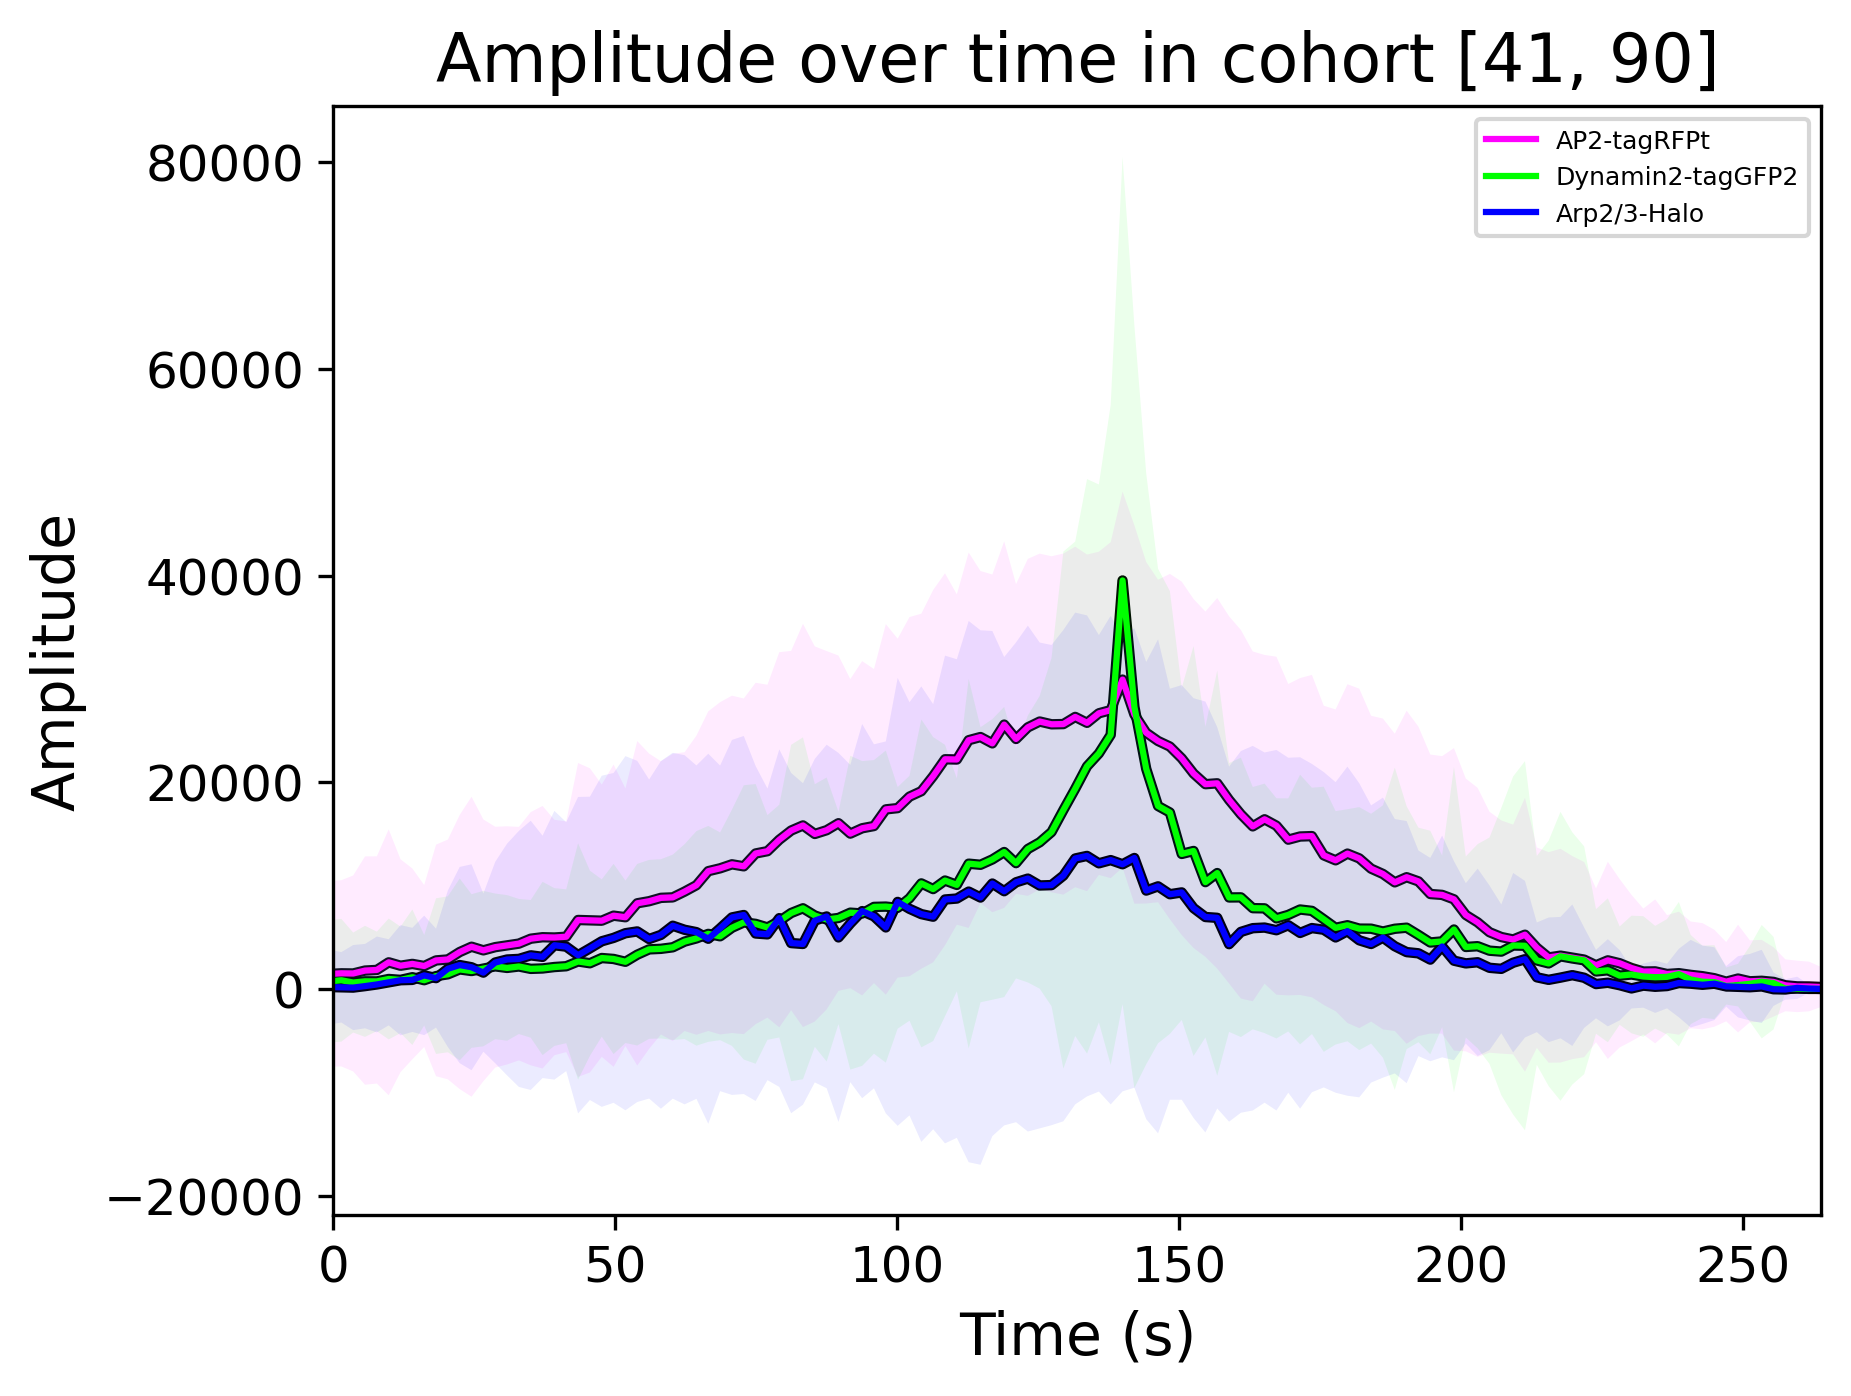

In [ ]:
basal_tracks = trackFilter('Basal', False, filtered_tracks_treatment)
track_id_arrays = filter_track_ids_by_length_ranges(dataframe = basal_tracks, track_length_buckets = custom_length_ranges, 
                                 track_id_col_name = 'track_id', track_length_col_name = 'track_length')

print(f'number of tracks between [5,10] frames long are {len(track_id_arrays[0])}')
print(f'number of tracks between [11,15] frames long are {len(track_id_arrays[1])}')
print(f'number of tracks between [16,20] frames long are {len(track_id_arrays[2])}')
print(f'number of tracks between [21,25] frames long are {len(track_id_arrays[3])}')
print(f'number of tracks between [26,30] frames long are {len(track_id_arrays[4])}')
print(f'number of tracks between [31,40] frames long are {len(track_id_arrays[5])}')
print(f'number of tracks between [41,90] frames long are {len(track_id_arrays[6])}')
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0
    
cohort_intensity(intensity_track,track_id_arrays, lumenoid2_frame_ms, [background_channel_3, background_channel_2, background_channel_1], value_to_plot=value_to_plot)


## CCS Growth Distribution Lumenoid 2 Testing

In [30]:
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
ccs_track_df = pd.read_pickle(input_directory_all_tracks_full)
ccs_track_df.head()

,frame,mu_x,mu_y,mu_z,amplitude,track_id,segment_id,sigma_z,sigma_y,sigma_x,...,c2_vol_bg,c3_peak_mean,c3_peak_max,c3_voxel_sum,c3_voxel_sum_adjusted,c3_peak_x,c3_peak_y,c3_peak_z,c3_vol_sig,c3_vol_bg
0,0,126.0,523.0,34.0,533.0,2213,NaN,3,2,2,...,441,262.274286,556,45898,20724.315789,125,523,32,175,441
1,0,159.0,422.0,37.0,17.0,2212,NaN,3,2,2,...,441,6.511494,22,1133,268.909434,157,422,35,174,439
2,0,98.0,483.0,38.0,372.0,2222,NaN,3,2,2,...,441,168.908571,530,29559,2851.105263,99,485,41,175,441
3,0,90.0,533.0,38.0,36.0,2221,NaN,3,2,2,...,437,4.891566,36,812,288.160377,89,532,37,166,378
4,0,85.0,352.0,37.0,1199.0,2220,NaN,3,2,2,...,441,407.440000,1199,71302,32061.210526,85,351,36,175,441


tracks_to_plot 0


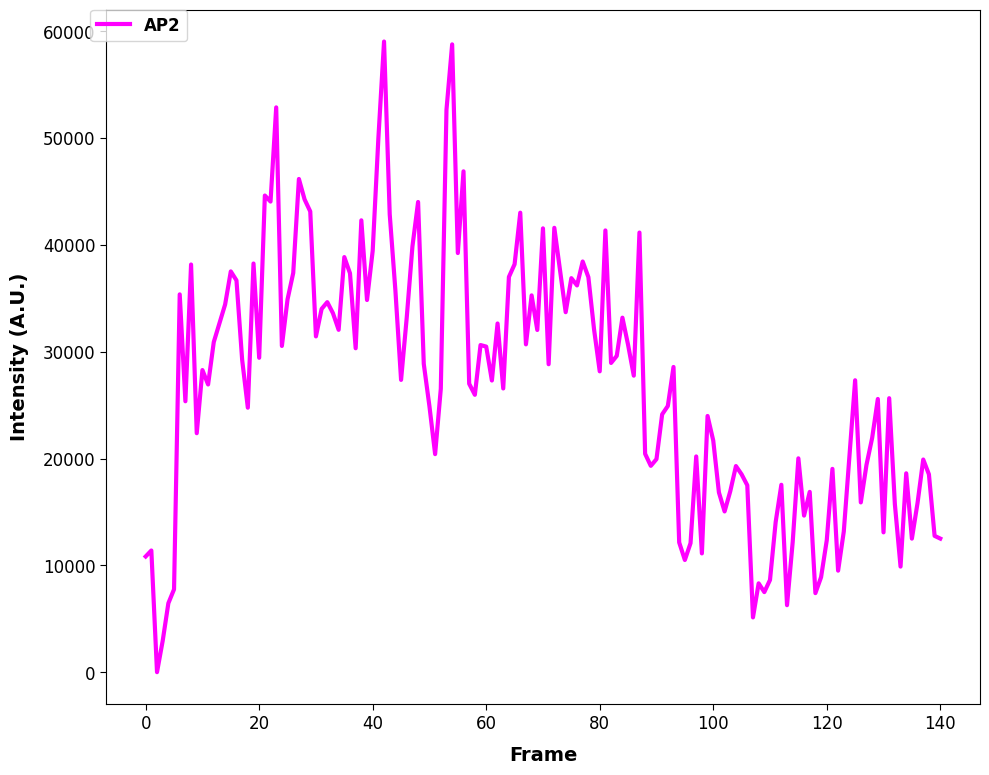

In [37]:
value_to_plot = 'voxel_sum_adjusted'
channel3_name = 'AP2'
channel2_name = 'Dynamin2'
channel1_name = 'ArpC3'

# set 'normalized = False' to plot raw intensities
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
track_df = pd.read_pickle(input_directory_all_tracks_full)
intensity_time_plot_onetrack(dataframe = track_df, tracks_to_plot = 0, 
intensity_to_plot = [f'c3_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 1, legend_values = [channel3_name],
line_colors = ['magenta'], graph_title = f'{value_to_plot}', normalized=False, save_plot = False)

In [62]:
all_slopes = growth_distribution(track_df, lumenoid2_frame_ms, time_interval=10, forwardp=0)
#print(all_slopes)
#len(all_slopes)



plt.hist(all_slopes, color = 'red', edgecolor='black', alpha=0.35, density=True, label='slope')
plt.xlabel('Slope', fontsize = 12, weight = 'bold')  # X-axis label
plt.ylabel('Frequency Density', fontsize = 12, weight = 'bold')  # Y-axis label
plt.title(f'Growth Distribution ', fontsize = 14, weight = 'bold')  # Title of the histogram
plt.legend(prop = {'weight':'bold'})
plt.show()

Processing tracks:   0%|          | 0/67768 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [57]:
print(all_slopes[1])

-0.08525638885321878


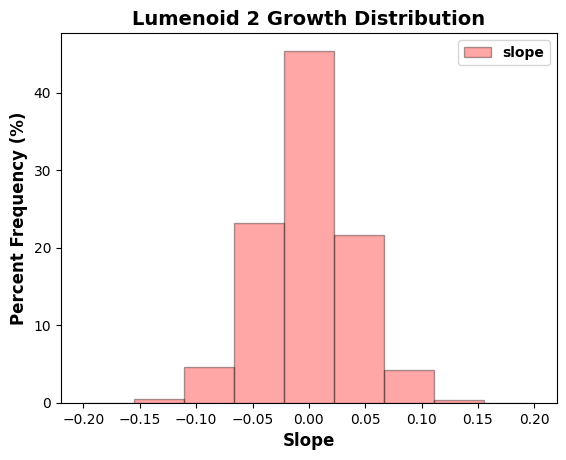

In [76]:
# plt.hist(all_slopes, bins = np.linspace(-0.09, 0.09, 6), color = 'red', edgecolor='black', alpha=0.35, density=True, label='slope')
# plt.xlabel('Slope', fontsize = 12, weight = 'bold')  # X-axis label
# plt.ylabel('Frequency Density', fontsize = 12, weight = 'bold')  # Y-axis label
# plt.title(f'Growth Distribution ', fontsize = 14, weight = 'bold')  # Title of the histogram
# plt.legend(prop = {'weight':'bold'})
# plt.show()
create_growth_dist_histogram(all_slopes, title="Lumenoid 2 Growth Distribution", bins=np.linspace(-0.2,0.2,10))

#### Apical CCS Growth Distribution

Processing tracks:   0%|          | 0/880 [00:00<?, ?it/s]

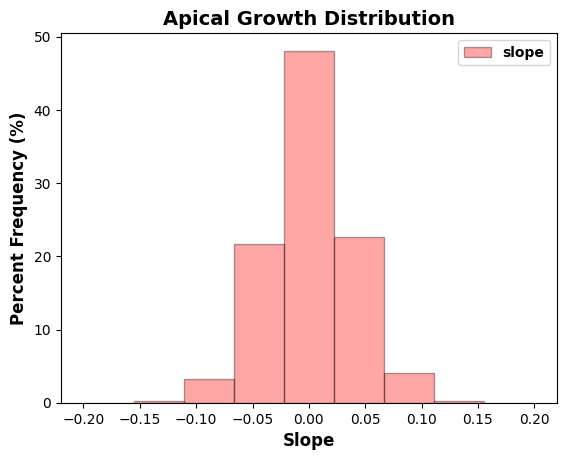

In [48]:
apical_tracks = trackFilter("Apical","False", filtered_tracks_treatment)
ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks['track_id'])]

apical_slopes = growth_distribution(ccs_apical_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
create_growth_dist_histogram(apical_slopes,title="Apical Growth Distribution", bins=np.linspace(-0.2,0.2,10))

#### Lateral CCS Growth Distribution

Processing tracks:   0%|          | 0/4883 [00:00<?, ?it/s]

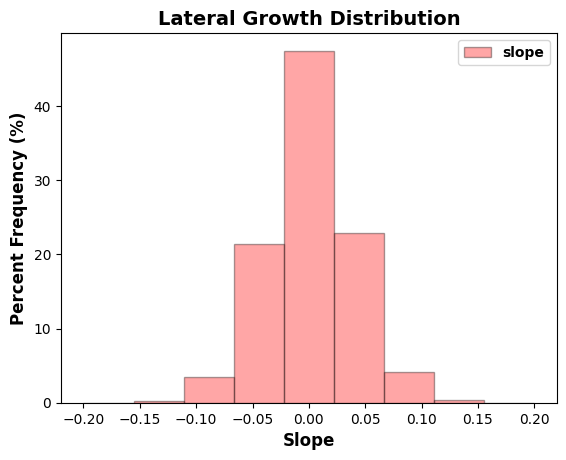

In [49]:
lateral_tracks = trackFilter("Lateral","False", filtered_tracks_treatment)
ccs_lateral_tracks = track_df[track_df['track_id'].isin(lateral_tracks['track_id'])]

lateral_slopes = growth_distribution(ccs_lateral_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
create_growth_dist_histogram(lateral_slopes,title="Lateral Growth Distribution", bins=np.linspace(-0.2,0.2,10))

#### Basal CCs Growth Distribution

Processing tracks:   0%|          | 0/2011 [00:00<?, ?it/s]

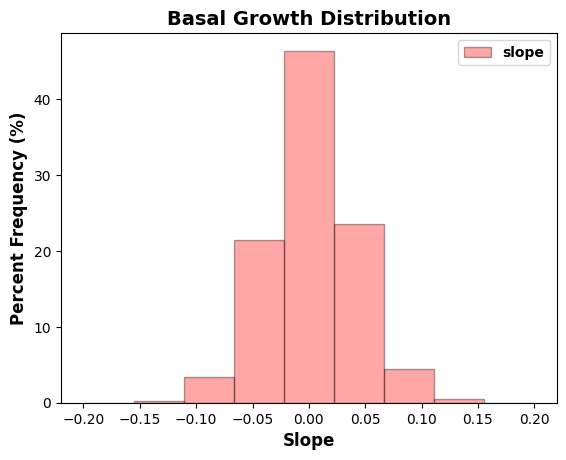

In [50]:
basal_tracks = trackFilter("Basal","False", filtered_tracks_treatment)
ccs_basal_tracks = track_df[track_df['track_id'].isin(basal_tracks['track_id'])]

basal_slopes = growth_distribution(ccs_basal_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
create_growth_dist_histogram(basal_slopes,title="Basal Growth Distribution", bins=np.linspace(-0.2,0.2,10))

Processing tracks:   0%|          | 0/880 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/4883 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2011 [00:00<?, ?it/s]

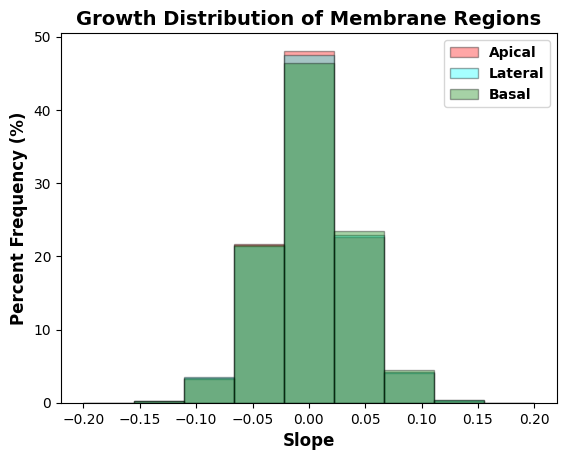

In [51]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
full_ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks_full['track_id'])]
full_apical_slopes = growth_distribution(full_ccs_apical_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

lateral_tracks_full = trackFilter("Lateral","False", filtered_tracks_treatment)
full_ccs_lateral_tracks = track_df[track_df['track_id'].isin(lateral_tracks_full['track_id'])]
full_lateral_slopes = growth_distribution(full_ccs_lateral_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

basal_tracks_full = trackFilter("Basal","False", filtered_tracks_treatment)
full_ccs_basal_tracks = track_df[track_df['track_id'].isin(basal_tracks_full['track_id'])]
full_basal_slopes = growth_distribution(full_ccs_basal_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([full_apical_slopes, full_lateral_slopes, full_basal_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
apical_weights = np.ones_like(full_apical_slopes) / len(full_apical_slopes) * 100
lateral_weights = np.ones_like(full_lateral_slopes) / len(full_lateral_slopes) * 100
basal_weights = np.ones_like(full_basal_slopes) / len(full_basal_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(full_apical_slopes, bins=bins, weights=apical_weights, color='red', edgecolor='black', alpha=0.35, label='Apical')
plt.hist(full_lateral_slopes, bins=bins, weights=lateral_weights, color='cyan', edgecolor='black', alpha=0.35, label='Lateral')
plt.hist(full_basal_slopes, bins=bins, weights=basal_weights, color='green', edgecolor='black', alpha=0.35, label='Basal')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution of Membrane Regions', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/880 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/4883 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2011 [00:00<?, ?it/s]

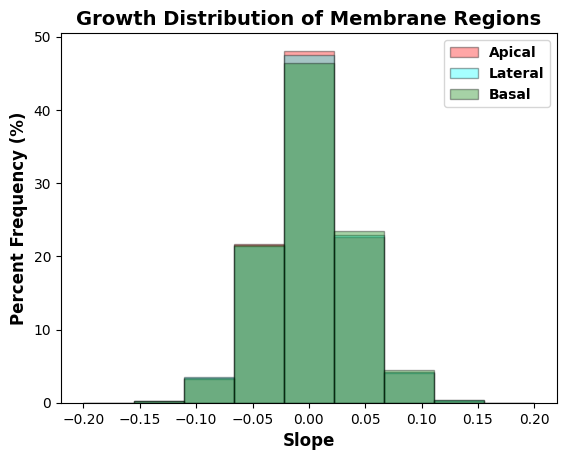

In [52]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
full_ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks_full['track_id'])]
full_apical_slopes = growth_distribution(full_ccs_apical_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

lateral_tracks_full = trackFilter("Lateral","False", filtered_tracks_treatment)
full_ccs_lateral_tracks = track_df[track_df['track_id'].isin(lateral_tracks_full['track_id'])]
full_lateral_slopes = growth_distribution(full_ccs_lateral_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

basal_tracks_full = trackFilter("Basal","False", filtered_tracks_treatment)
full_ccs_basal_tracks = track_df[track_df['track_id'].isin(basal_tracks_full['track_id'])]
full_basal_slopes = growth_distribution(full_ccs_basal_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([full_apical_slopes, full_lateral_slopes, full_basal_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
apical_weights = np.ones_like(full_apical_slopes) / len(full_apical_slopes) * 100
lateral_weights = np.ones_like(full_lateral_slopes) / len(full_lateral_slopes) * 100
basal_weights = np.ones_like(full_basal_slopes) / len(full_basal_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(full_apical_slopes, bins=bins, weights=apical_weights, color='red', edgecolor='black', alpha=0.35, label='Apical')
plt.hist(full_lateral_slopes, bins=bins, weights=lateral_weights, color='cyan', edgecolor='black', alpha=0.35, label='Lateral')
plt.hist(full_basal_slopes, bins=bins, weights=basal_weights, color='green', edgecolor='black', alpha=0.35, label='Basal')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution of Membrane Regions', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

#### Arp2/3+ Dynamin+ vs Arp2/3- Dynamin+ 

Processing tracks:   0%|          | 0/3539 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2904 [00:00<?, ?it/s]

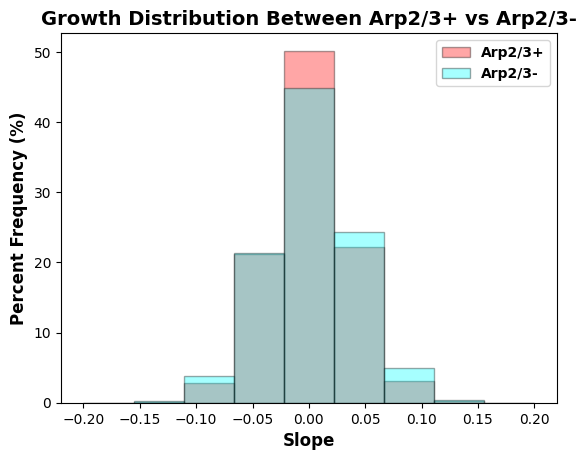

In [177]:
arp2_pos_all = trackFilter("All",False, filtered_tracks_treatment)
arp2_neg_all = trackFilter("All", False, filtered_tracks_treatment, [False,True])

arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(arp2_pos_all['track_id'])]
arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(arp2_neg_all['track_id'])]

arp2_pos_slopes = growth_distribution(arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)
arp2_neg_slopes = growth_distribution(arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([arp2_pos_slopes, arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(arp2_pos_slopes) / len(arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(arp2_neg_slopes) / len(arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

#### Apical Arp2/3+ vs Arp2/3-

Processing tracks:   0%|          | 0/259 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/230 [00:00<?, ?it/s]

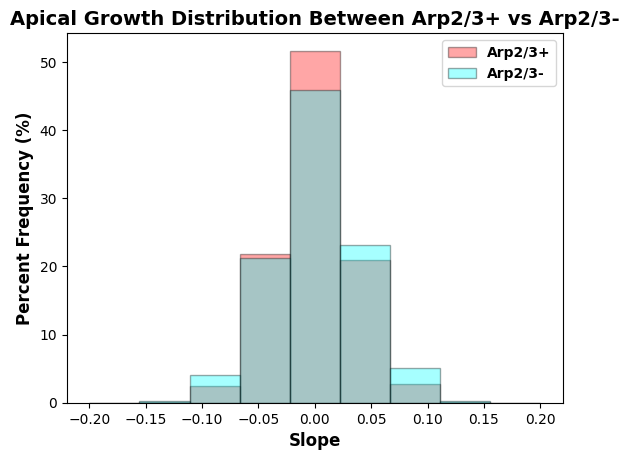

In [ ]:
apical_arp2_pos_all = trackFilter("Apical",False, filtered_tracks_treatment)
apical_arp2_neg_all = trackFilter("Apical", False, filtered_tracks_treatment, [False,True])

apical_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(apical_arp2_pos_all['track_id'])]
apical_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(apical_arp2_neg_all['track_id'])]

apical_arp2_pos_slopes = growth_distribution(apical_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
apical_arp2_neg_slopes = growth_distribution(apical_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([apical_arp2_pos_slopes, apical_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(apical_arp2_pos_slopes) / len(apical_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(apical_arp2_neg_slopes) / len(apical_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(apical_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(apical_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Apical Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/1905 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/1352 [00:00<?, ?it/s]

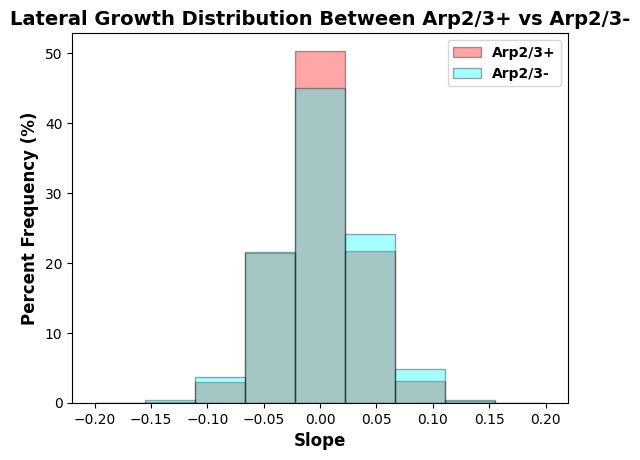

In [ ]:
lateral_arp2_pos_all = trackFilter("Lateral",False, filtered_tracks_treatment)
lateral_apical_arp2_neg_all = trackFilter("Lateral", False, filtered_tracks_treatment, [False,True])

lateral_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(lateral_arp2_pos_all['track_id'])]
lateral_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(lateral_apical_arp2_neg_all['track_id'])]

lateral_arp2_pos_slopes = growth_distribution(lateral_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
lateral_arp2_neg_slopes = growth_distribution(lateral_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([lateral_arp2_pos_slopes, lateral_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(lateral_arp2_pos_slopes) / len(lateral_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(lateral_arp2_neg_slopes) / len(lateral_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(lateral_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(lateral_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Lateral Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/655 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/630 [00:00<?, ?it/s]

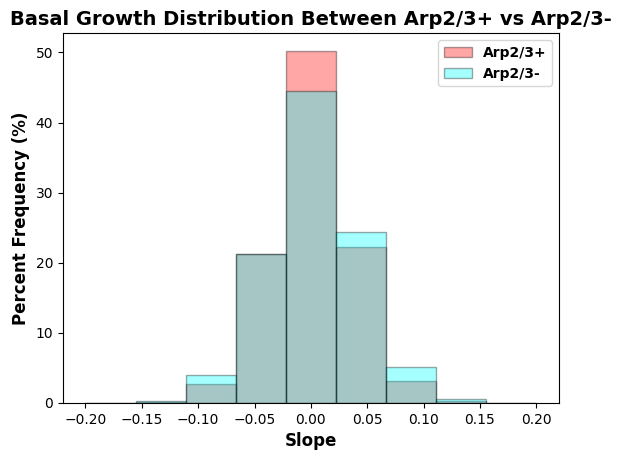

In [ ]:
basal_arp2_pos_all = trackFilter("Basal",False, filtered_tracks_treatment)
basal_apical_arp2_neg_all = trackFilter("Basal", False, filtered_tracks_treatment, [False,True])

basal_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(basal_arp2_pos_all['track_id'])]
basal_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(basal_apical_arp2_neg_all['track_id'])]

basal_arp2_pos_slopes = growth_distribution(basal_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
basal_arp2_neg_slopes = growth_distribution(basal_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([basal_arp2_pos_slopes, basal_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(basal_arp2_pos_slopes) / len(basal_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(basal_arp2_neg_slopes) / len(basal_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(basal_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(basal_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Basal Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

## CCS Testing Python Packaged Least Squares

In [36]:
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
ccs_track_df = pd.read_pickle(input_directory_all_tracks_full)


In [67]:
auto_slopes = auto_growth_distribution(ccs_track_df, lumenoid2_frame_ms, time_interval=10, forwardp=0)
#print(all_slopes)
#len(all_slopes)


Processing tracks:   0%|          | 0/67768 [00:00<?, ?it/s]

1
2
3
slopes len: 1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
slopes len: 1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
slopes len: 1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
slopes len: 1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
slopes len: 1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
slopes len: 1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
slopes len: 1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
slopes len: 1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
slopes len: 1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
slopes len: 1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24

KeyboardInterrupt: 

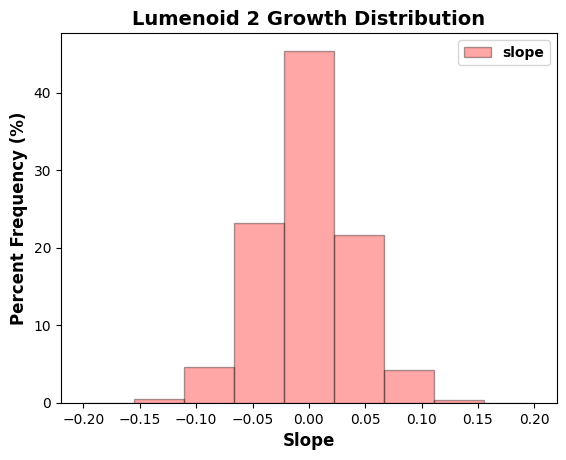

In [175]:
create_growth_dist_histogram(auto_slopes, title="Lumenoid 2 Growth Distribution", bins=np.linspace(-0.2,0.2,10))

### Comparing Membrane regions for all tracks

Processing tracks:   0%|          | 0/880 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/4883 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2011 [00:00<?, ?it/s]

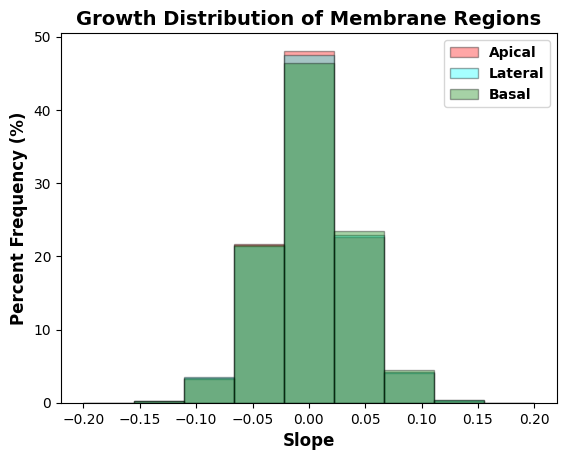

In [176]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
full_ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks_full['track_id'])]
full_apical_slopes = auto_growth_distribution(full_ccs_apical_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

lateral_tracks_full = trackFilter("Lateral","False", filtered_tracks_treatment)
full_ccs_lateral_tracks = track_df[track_df['track_id'].isin(lateral_tracks_full['track_id'])]
full_lateral_slopes = auto_growth_distribution(full_ccs_lateral_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

basal_tracks_full = trackFilter("Basal","False", filtered_tracks_treatment)
full_ccs_basal_tracks = track_df[track_df['track_id'].isin(basal_tracks_full['track_id'])]
full_basal_slopes = auto_growth_distribution(full_ccs_basal_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([full_apical_slopes, full_lateral_slopes, full_basal_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
apical_weights = np.ones_like(full_apical_slopes) / len(full_apical_slopes) * 100
lateral_weights = np.ones_like(full_lateral_slopes) / len(full_lateral_slopes) * 100
basal_weights = np.ones_like(full_basal_slopes) / len(full_basal_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(full_apical_slopes, bins=bins, weights=apical_weights, color='red', edgecolor='black', alpha=0.35, label='Apical')
plt.hist(full_lateral_slopes, bins=bins, weights=lateral_weights, color='cyan', edgecolor='black', alpha=0.35, label='Lateral')
plt.hist(full_basal_slopes, bins=bins, weights=basal_weights, color='green', edgecolor='black', alpha=0.35, label='Basal')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution of Membrane Regions', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

#### Arp2/3+ Dynamin+ vs Arp2/3- Dynamin+ 

Processing tracks:   0%|          | 0/3539 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2904 [00:00<?, ?it/s]

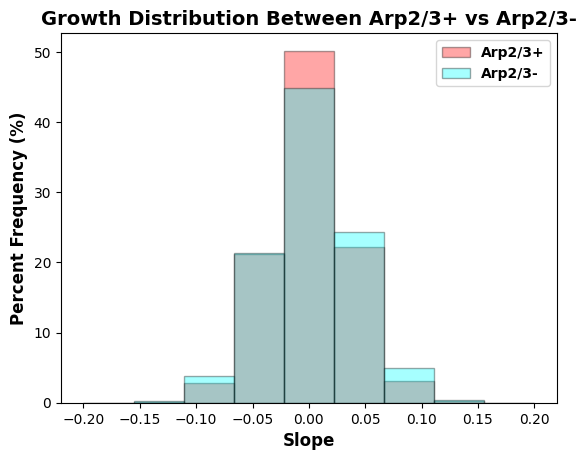

In [ ]:
arp2_pos_all = trackFilter("All",False, filtered_tracks_treatment)
arp2_neg_all = trackFilter("All", False, filtered_tracks_treatment, [False,True])

arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(arp2_pos_all['track_id'])]
arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(arp2_neg_all['track_id'])]

arp2_pos_slopes = growth_distribution(arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)
arp2_neg_slopes = growth_distribution(arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([arp2_pos_slopes, arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(arp2_pos_slopes) / len(arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(arp2_neg_slopes) / len(arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

### Comparing membrane regions Arp2/3+ vs Arp2/3-

Processing tracks:   0%|          | 0/259 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/230 [00:00<?, ?it/s]

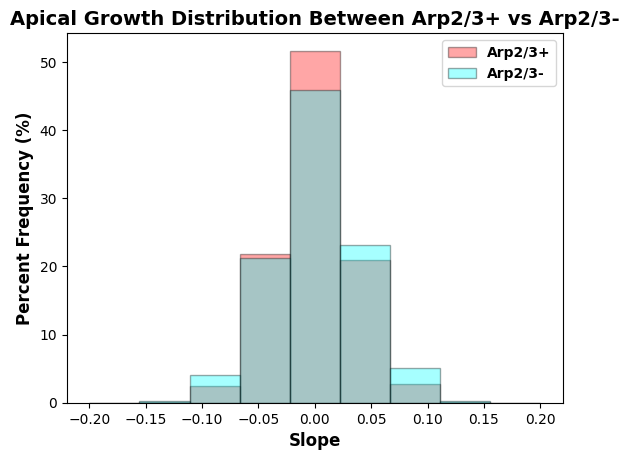

In [179]:
apical_arp2_pos_all = trackFilter("Apical",False, filtered_tracks_treatment)
apical_arp2_neg_all = trackFilter("Apical", False, filtered_tracks_treatment, [False,True])

apical_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(apical_arp2_pos_all['track_id'])]
apical_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(apical_arp2_neg_all['track_id'])]

apical_arp2_pos_slopes = auto_growth_distribution(apical_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
apical_arp2_neg_slopes = auto_growth_distribution(apical_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([apical_arp2_pos_slopes, apical_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(apical_arp2_pos_slopes) / len(apical_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(apical_arp2_neg_slopes) / len(apical_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(apical_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(apical_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Apical Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/1905 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/1352 [00:00<?, ?it/s]

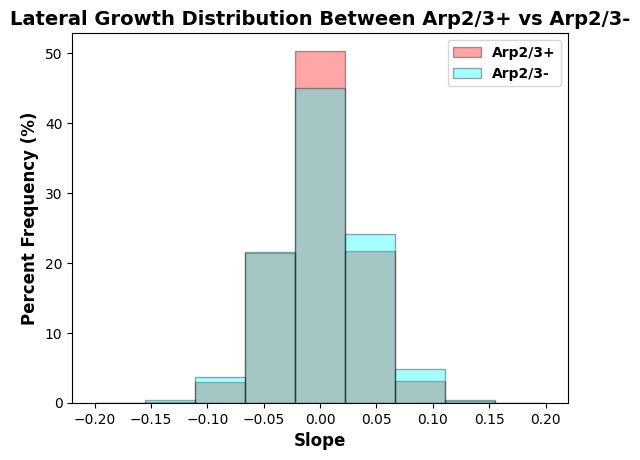

In [180]:
lateral_arp2_pos_all = trackFilter("Lateral",False, filtered_tracks_treatment)
lateral_apical_arp2_neg_all = trackFilter("Lateral", False, filtered_tracks_treatment, [False,True])

lateral_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(lateral_arp2_pos_all['track_id'])]
lateral_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(lateral_apical_arp2_neg_all['track_id'])]

lateral_arp2_pos_slopes = auto_growth_distribution(lateral_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
lateral_arp2_neg_slopes = auto_growth_distribution(lateral_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([lateral_arp2_pos_slopes, lateral_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(lateral_arp2_pos_slopes) / len(lateral_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(lateral_arp2_neg_slopes) / len(lateral_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(lateral_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(lateral_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Lateral Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/655 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/630 [00:00<?, ?it/s]

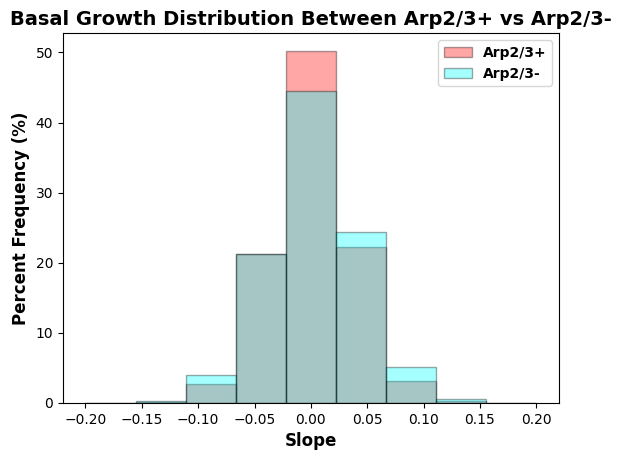

In [181]:
basal_arp2_pos_all = trackFilter("Basal",False, filtered_tracks_treatment)
basal_apical_arp2_neg_all = trackFilter("Basal", False, filtered_tracks_treatment, [False,True])

basal_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(basal_arp2_pos_all['track_id'])]
basal_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(basal_apical_arp2_neg_all['track_id'])]

basal_arp2_pos_slopes = auto_growth_distribution(basal_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
basal_arp2_neg_slopes = auto_growth_distribution(basal_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([basal_arp2_pos_slopes, basal_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(basal_arp2_pos_slopes) / len(basal_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(basal_arp2_neg_slopes) / len(basal_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(basal_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(basal_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Basal Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

## Better CCS Plotting Testing

In [169]:
slope_df = slope_dateframe(ccs_track_df, lumenoid2_frame_ms, time_interval=10, forwardp=0)

Processing tracks:   0%|          | 0/67768 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [75]:
output_directory = 'datasets'
output_file_name = 'ccs_slope_tracks.pkl' # can change this to filtered_tracks_final.pkl. region_filtered... just for testing purposes
output_directory_full = os.path.join(base_dir, input_file_directory, output_directory, output_file_name)
slope_df.to_pickle(output_directory_full)

In [34]:
all_slopes = pd.read_pickle(os.path.join(base_dir, input_file_directory, 'datasets', 'ccs_slope_tracks.pkl'))

[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140]


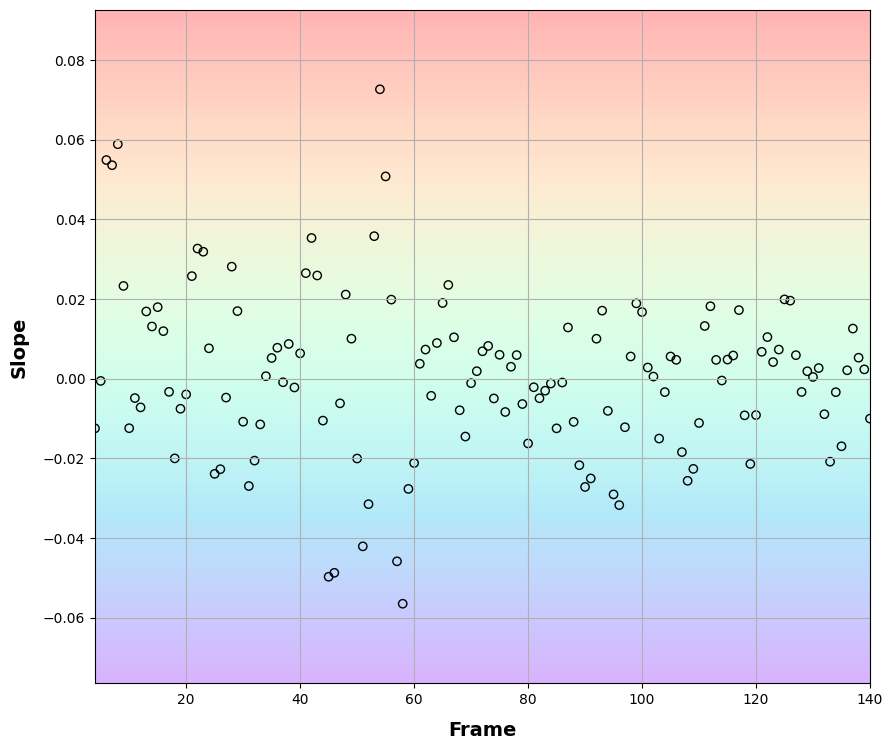

In [192]:
slope_zero, slope_to_frame = slope_plot(track_df, 0, lumenoid2_frame_ms, 10.5)

In [ ]:
def slope_color_coded_intensity_time_plot(dataframe: pd.DataFrame, tracks_to_plot: np.ndarray, track_id_col_name: str, 
                       frame_col_name: str, intensity_to_plot: list, channels_to_plot: int, slope_list, avg_size, threshold, legend_values: list = ['Channel 3', 'Channel 2', 'Channel 1'], 
                       line_colors: list = ['red', 'green', 'blue'], graph_title = 'Intensity', normalized: bool = False, save_plot: bool = False):
    
    '''
    
    The function takes in the list of track ids assigned to a cohort and aligns them with respect to their 
    peak values to a specific index. The index depends on bufferZero. Whatever the value of bufferZero is the
    peaks will be aligned with that value. 
    
    Parameters:
    1. dataframe: type(DataFrame), this is the raw dataframe which contains all of the relevant intensity values
    1. tracks_to_plot: type(list), contains the tracks id's of tracks within the specified length range
    4. intensity_to_plot, type(list), the name of the columns to be used for plotting intensity. Note that the first value
    in this list should be for the primary channel, second value for the secondary channel and so on. 
    Default Value: ['amplitude', 'c2_peak']
    5. track_id_col_name: type(str), the column name which contains the frame number. Default value: 'track_id'
    6. legend_values: type(list), labels for the legend. Must be in line with intensity_to_plot list. The channel that is first in intensity_to_plot
    must also appear first in legend labels. 
    7. line_colors: type(list), colors for the intensity_to_plot lines. line_colors[0] will be the color for intensity_to_plot[0] and so on. 
    8. normalized: type(bool), if the intensity values are normalized. Default value: False

    Output: 
    1. Returns the array of primary channel tracks aligned with respect to secondary channel peaks
    2. Returns the array of secondary channel tracks where tracks are aligned with all peaks of tracks being on 
    the same index. (the index is determined by bufferZero)
    
    '''


    if channels_to_plot == 3 and len(intensity_to_plot) != 3: 
        raise ValueError('length of intensity_to_plot must equal channels_to_plot')
        
    num_rows = 1
    num_cols = 1
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 8.75))

    handles = []
    labels = []

    # Filter DataFrame for the selected track_id
    print("tracks_to_plot", tracks_to_plot)
    track_data = dataframe[dataframe[track_id_col_name] == tracks_to_plot].copy(deep = True)

    # Set x-axis range from 1 to 20
    x_range = np.arange(1, 21)

    # Plot intensities on the same subplot
    row = 1
    col = 1
    #length = filtered_df[filtered_df['track_id'] == track_id]['track_length'].values
    length = track_data.shape[0]

    lines = []
    for i in range(channels_to_plot):
        min_val = track_data[intensity_to_plot[i]].min()
        track_data[intensity_to_plot[i]] -= min_val
        max_val = track_data[intensity_to_plot[i]].max()          

        # normalize by max_intensity
        if normalized:  
            track_data[intensity_to_plot[i]] /= max_val
        line, = axes.plot(track_data[frame_col_name], track_data[intensity_to_plot[i]], label=intensity_to_plot[i], color=line_colors[i], linewidth = 3)
        # print(track_data[intensity_to_plot[i]])
        lines.append(line)
    #threshold = 0.1
    for i in range(0, len(slope_list), avg_size):
        chunk = slope_list[i:i+avg_size]
        if chunk.size == 0:  # Skip empty chunk
            continue

        avg = np.mean(chunk)
        print(avg)
        if avg > threshold:
            color = "green"
        elif avg < -threshold:
            color = 'blue'
        else:
            color = 'red'
        mask = (track_data[frame_col_name] > i) & (track_data[frame_col_name] <= i + avg_size)
        axes.plot(track_data[frame_col_name][mask], track_data[intensity_to_plot[0]][mask], color=color, linewidth=5, alpha=0.8)
    # axes.set_title(f'Track {tracks_to_plot}, length {length}')
    axes.set_xlabel('Frame', fontweight = 'bold', labelpad = 10, fontsize = 14)
    axes.set_ylabel('Intensity (A.U.)', fontweight = 'bold', labelpad = 10, fontsize = 14)
    #axes[row, col].legend()
    axes.tick_params(axis='x', reset=True, direction='out', 
                 color='black', length=4, labelsize=12)
    axes.tick_params(axis='x', which='both', top=False)
    axes.tick_params(axis='y', reset=True, direction='out', 
                    color='black', length=4, labelsize=12)
    axes.tick_params(axis='y', which='both', right=False)

    axes.grid(False)


    for i in range(channels_to_plot):
        handles.append(lines[i])
        labels.append(legend_values[i])
        
    # Set a single legend for all subplots
    legend = fig.legend(handles, labels, loc='upper left', fontsize=12, frameon= True,  bbox_to_anchor=(0.087, 0.89))
    for text in legend.get_texts():
        text.set_fontweight('bold')
    # Adjust layout for better spacing
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, hspace=0.5)

    # save_plot = False  # Set this to True if you want to save the plot
    if save_plot:
        filename = f'intensity_plot_track_{tracks_to_plot}.png'
        plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"Plot saved as {filename}")
    #fig.suptitle(f'Intensity over time \n Channel 3 color: red \n Channel 2 color: green \n Channel 1 color: blue', fontsize=18, fontweight='bold')
    #plt.subplots_adjust(top=0.90)
    plt.show()

tracks_to_plot 0


TypeError: 'int' object is not callable

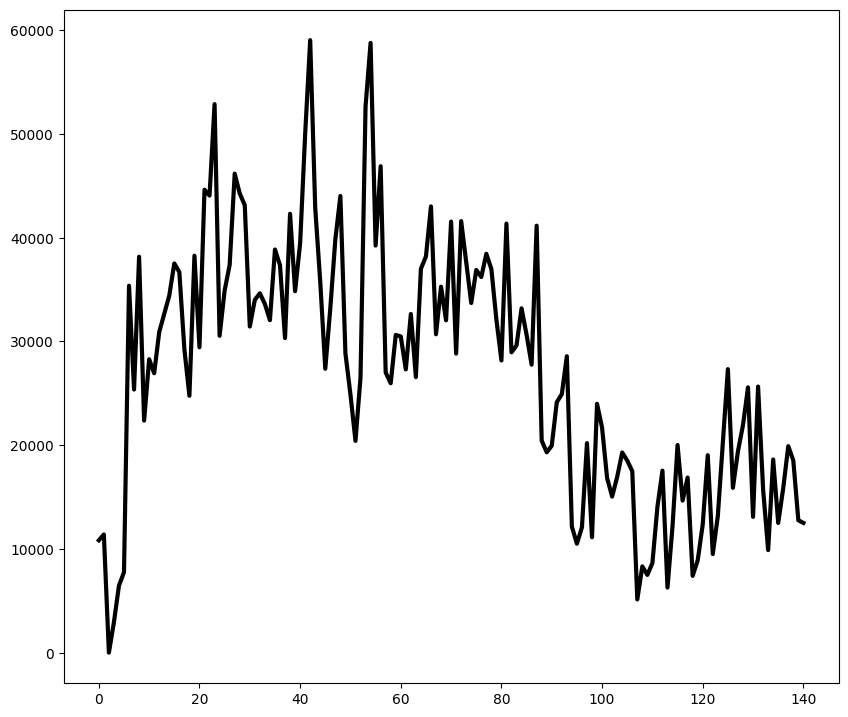

In [194]:
# set 'normalized = False' to plot raw intensities
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
track_df = pd.read_pickle(input_directory_all_tracks_full)
slope_color_coded_intensity_time_plot(dataframe = track_df, tracks_to_plot = 0, 
intensity_to_plot = [f'c3_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 1, slope_list = slope_zero[0], avg_size=8, threshold = 0.01, legend_values = [channel3_name],
line_colors = ['black'], graph_title = f'{value_to_plot}', normalized=False, save_plot = False)